## Import necessary libraries

In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import  CountVectorizer, ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MultiLabelBinarizer, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from scipy.stats import pearsonr

import re
from collections import Counter
from IPython.display import display
import plotly.graph_objects as go

import math

import time # To check notebook run time

import os
import json
import requests
from tqdm.auto import tqdm

TMDB_API_KEY = "your_tmdb_api_key_here"
TMDB_BASE_URL = "https://api.themoviedb.org/3"


from sentence_transformers import SentenceTransformer

## Check Runtime Of Notebook

In [36]:
start_time = time.time()

## Load the Full dataset

In [37]:
 df = pd.read_csv("data/Netflix_Streaming_Data.csv") # Read the csv file to DataFrame

## Target Column - Ratings

In [38]:
initial_count = len(df)
print(f"The data initialy has {initial_count} rows")

The data initialy has 8807 rows


In [ ]:
target = df.rating
print(f"We initially have the following ratings: {list(target.unique())}")
print(f'We have {target.nunique()} values for this column')

We initially have the following ratings: ['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R', 'TV-G', 'G', 'NC-17', '74 min', '84 min', '66 min', 'NR', nan, 'TV-Y7-FV', 'UR']
We have 17 values for this column


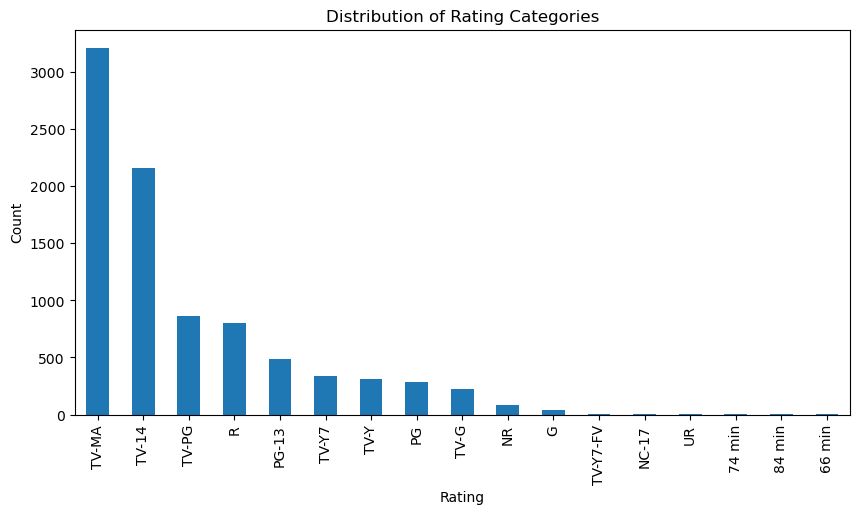

In [40]:
# Distribution plot of all 17 Rating categories
df['rating'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Distribution of Rating Categories")
plt.ylabel("Count")
plt.xlabel("Rating")
plt.show()

In [41]:
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

There are three strange values that are NOT ratings, but appear to be durations accidentally placed into the rating column: 74 min, 84 min, 66 min. We decided to remove them, as they are a small amount of the total data (only 3 obseravations).

In [42]:
# Remove incorrect rating entries 
invalid_values = ['74 min', '84 min', '66 min']
df = df[~df['rating'].isin(invalid_values)]

# Check updated unique rating counts
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [43]:
# Check for missing values in Rating column
missing_rating = df["rating"].isna().sum()
print(f"There are {missing_rating} missing values in the rating column.")

There are 4 missing values in the rating column.


In [44]:
# Drop rows where rating is missing
df = df.dropna(subset=['rating'])

# Check updated unique rating counts
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [45]:
# Remove rows which are declared as none rated categories - UR, NR
none_rated_categories = ['UR', 'NR']
df= df[~df['rating'].isin(none_rated_categories)]

# Check updated unique rating counts
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
G             41
TV-Y7-FV       6
NC-17          3
Name: count, dtype: int64

In total, the dataset initially contained 8,807 observations, out of which:
   - 3 observations were removed due to invalid rating values
   - 4 observations were removed due to missing (NaN) rating values
   - 83 observations were removed due to non-rated categories (UR, NR)

This results in a total of 90 removed observations, which corresponds to:

                                90/8807≈0.0102=1.02%


In total, we removed 90 observations, which is approximately 1.02% of the dataset, ensuring that the target variable includes only valid rating categories.

In order to have meaningful categories for classification we will group together the different rating categories into 3 semantically similar classes:
| **Group Name** | **Ratings Included** | Meaning                                   |
| -------------- | -------------------- | ----------------------------------------- |
| **Family & Kids**       | TV-Y, TV-Y7, TV-G, TV-Y7-FV, G, TV-PG | Content suitable for all ages and for young children                |
| **Teen**       | TV-14, PG, PG-13                | Designed for teens, some mature themes    |
| **Adult**      | R, TV-MA, NC-17        | Mature audiences                          |

In [46]:
rating_map = {
    'TV-Y': 'Family & Kids',
    'TV-Y7': 'Family & Kids',
    'TV-G': 'Family & Kids',
    'TV-Y7-FV': 'Family & Kids',
    'G': 'Family & Kids',
    'TV-PG': 'Family & Kids',
    
    'TV-14': 'Teen',
    'PG': 'Teen',
    'PG-13': 'Teen',
    
    'R': 'Adult',
    'TV-MA': 'Adult',
    'NC-17': 'Adult'
}

df['rating_grouped'] = df['rating'].map(rating_map)

# See count distribution after grouping
df['rating_grouped'].value_counts()

rating_grouped
Adult            4009
Teen             2937
Family & Kids    1771
Name: count, dtype: int64

In [47]:
# Drop the original "Rating" column
netflix_data = df.drop(columns=['rating'])

For classification we need to encode the group labels into numeric classes, we will map the 3 groups as follows:

| Group  | Class ID |
| ------ | -------- |
| Family & Kids  | 0        |
| Teen   | 1        |
| Adult  | 2        |

In [48]:
label_map = {'Family & Kids': 0, 'Teen': 1, 'Adult': 2}
netflix_data['rating_label'] = netflix_data['rating_grouped'].map(label_map)

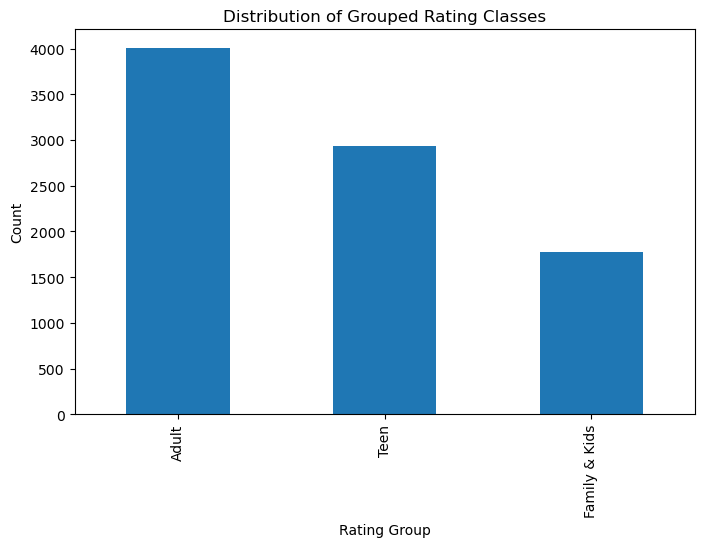

In [49]:
# Plot the distibution of the grouped ratings 
netflix_data['rating_grouped'].value_counts().plot(kind='bar', figsize=(8,5))
plt.title("Distribution of Grouped Rating Classes")
plt.xlabel("Rating Group")
plt.ylabel("Count")
plt.show()

## Split the Full Dataset to Train & Test

In [50]:
# We will use the numeric label as target
target = 'rating_label'

# Drop unused columns that won't help in modeling
X = netflix_data.drop(columns=[target])  # Features
y = netflix_data[target]                 # Target


# Split full dataset to train and test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify ensures class balance
)

# Confirm the split
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTarget distribution in train:")
print(y_train.value_counts(normalize=True) * 100)
print("\nTarget distribution in test:")
print(y_test.value_counts(normalize=True) * 100)

Train shape: (6973, 12)
Test shape: (1744, 12)

Target distribution in train:
rating_label
2    45.991682
1    33.687079
0    20.321239
Name: proportion, dtype: float64

Target distribution in test:
rating_label
2    45.986239
1    33.715596
0    20.298165
Name: proportion, dtype: float64


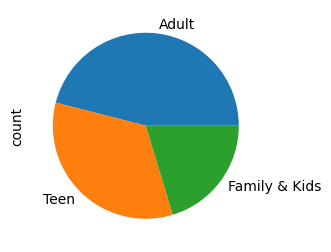

In [51]:
# Plot the distibution of the grouped ratings 
X_train['rating_grouped'].value_counts().plot(kind='pie', figsize=(3,5))
plt.show()

In [52]:

# Save the train and test data in different csv's per project request in submission

X_train.to_csv("data/X_train.csv", index=True)
X_test.to_csv("data/X_test.csv", index=True)
y_train.to_csv("data/y_train.csv", index=True)
y_test.to_csv("data/y_test.csv", index=True)

## Initial introduction and inspection

In [53]:
X_train.head() # 5 rows is the default for head() so you can either write down 5 or not and will be the same

,show_id,type,title,director,cast,country,date_added,release_year,duration,listed_in,description,rating_grouped
6222,s6223,Movie,Balto 3: Wings of Change,Phil Weinstein,"Maurice LaMarche, Sean Astin, Keith Carradine,...",United States,"April 1, 2018",2004,78 min,Children & Family Movies,A pilot challenges Balto's son Kodi and his sl...,Family & Kids
1373,s1374,TV Show,50M2,NaN,"Engin Öztürk, Kürşat Alnıaçık, Cengiz Bozkurt,...",Turkey,"January 27, 2021",2021,1 Season,"International TV Shows, TV Dramas, TV Thrillers","Seeking to uncover the truth about his past, a...",Adult
6994,s6995,Movie,Hope Springs Eternal,Jack C. Newell,"Mia Rose Frampton, Beth Lacke, Stony Blyden, J...",United States,"November 8, 2018",2018,79 min,Dramas,When a teen with terminal cancer miraculously ...,Teen
8144,s8145,Movie,Taal,Subhash Ghai,"Anil Kapoor, Aishwarya Rai Bachchan, Akshaye K...",India,"March 1, 2018",1999,177 min,"Dramas, International Movies, Music & Musicals",Businessman Manav falls for aspiring singer Ma...,Family & Kids
1409,s1410,Movie,The Vanished,Peter Facinelli,"Thomas Jane, Anne Heche, Jason Patric, John D....",United States,"January 15, 2021",2020,115 min,Thrillers,When their daughter disappears during a family...,Adult


In [54]:
num_rows, num_columns = X_train.shape
# Print the number of rows and columns of the DataFrame
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_columns}")

# Print the shape of the DataFrame
print(f"Shape of the DataFrame: {X_train.shape}")

Number of rows: 6973
Number of columns: 12
Shape of the DataFrame: (6973, 12)


In [55]:
#Check the data types
print("Column names:")
print(list(X_train.columns)) # This prints only the columns names of the df

print("\nData types of each column:")
print(X_train.dtypes)

Column names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'duration', 'listed_in', 'description', 'rating_grouped']

Data types of each column:
show_id           object
type              object
title             object
director          object
cast              object
country           object
date_added        object
release_year       int64
duration          object
listed_in         object
description       object
rating_grouped    object
dtype: object


### Descriptive statistics

#### Let's explore some basic descriptive statistics of the dataframe.

In [56]:
# Display the summary statistics for each column in the DataFrame, including non-numeric (categorical data) in order to have
# summary statistics for all the columns
summary_statistics_all = X_train.describe(include='all')
summary_statistics_all

,show_id,type,title,director,cast,country,date_added,release_year,duration,listed_in,description,rating_grouped
count,6973,6973,6973,4886,6337,6311,6967,6973.000000,6973,6973,6973,6973
unique,6973,2,6973,3731,6142,625,1635,NaN,209,481,6959,3
top,s6223,Movie,Balto 3: Wings of Change,"Raúl Campos, Jan Suter",David Attenborough,United States,"January 1, 2020",NaN,1 Season,"Dramas, International Movies",This educational series for tiny tots features...,Adult
freq,1,4854,1,18,14,2208,93,NaN,1423,298,2,3207
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.273627,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.649034,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1942.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


#### Summary of initial dataset statistics:

The training dataset contains 6,973 titles, each uniquely identified by show_id and title. The catalog is composed mainly of Movies (≈70%), with TV Shows making up the remainder. Most categorical fields exhibit very high cardinality: for example, director has 3,731 unique names, cast includes over 6,000 unique actors, and listed_in spans 481 genre/category combinations, highlighting the dataset’s large diversity.

The most common values reflect typical patterns in Netflix content: United States is the dominant production country (appearing in 2,208 titles), and many records share frequently occurring genre tags such as Dramas and International Movies. For the rating_grouped target variable, “Adult” is the most common class (3,207 observations), followed by Teen and Family & Kids.

Missingness varies across metadata fields. While type, title, and release_year are fully populated, fields such as director (2,087 missing), cast (636 missing), and country (662 missing) contain gaps, which motivates the enrichment and imputation procedures performed later. The date_added feature is nearly complete, with only 6 missing entries.

The only fully numeric feature, release_year, ranges from 1942 to 2021, with a median year of 2017 and a mean of 2014, indicating that Netflix's catalogue skews toward more recent releases.

Overall, the dataset is rich, diverse, and dominated by long-tail categorical variables typical of entertainment metadata, requiring careful handling of missing data and appropriate feature engineering techniques before modeling.

In [57]:
# General dataset overview
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6973 entries, 6222 to 3501
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   show_id         6973 non-null   object
 1   type            6973 non-null   object
 2   title           6973 non-null   object
 3   director        4886 non-null   object
 4   cast            6337 non-null   object
 5   country         6311 non-null   object
 6   date_added      6967 non-null   object
 7   release_year    6973 non-null   int64 
 8   duration        6973 non-null   object
 9   listed_in       6973 non-null   object
 10  description     6973 non-null   object
 11  rating_grouped  6973 non-null   object
dtypes: int64(1), object(11)
memory usage: 708.2+ KB


#### Summary of Data Frame Information:

The training dataset contains 6,973 records and 12 columns, with nearly all features stored as text (object) except for release_year, which is numeric. Core identifying and descriptive fields—show_id, type, title, duration, listed_in, and description—are fully populated, ensuring complete coverage for fundamental metadata.

Several key enrichment fields exhibit missing values: director has the largest gap with 2,087 missing entries, followed by cast (636 missing) and country (662 missing), confirming that these attributes require targeted imputation or external lookup. Meanwhile, date_added is almost fully complete, missing only 6 values, and the target variable rating_grouped is fully available for all observations.

Overall, the dataset is well-structured with consistent datatypes, dominated by textual features that will require preprocessing techniques such as tokenization, embeddings, and one-hot encoding. Its memory footprint is modest (~708 KB).

In [58]:
X_train.nunique()

show_id           6973
type                 2
title             6973
director          3731
cast              6142
country            625
date_added        1635
release_year        71
duration           209
listed_in          481
description       6959
rating_grouped       3
dtype: int64

#### Unique Values Summary:

The uniqueness profile of the dataset highlights its high diversity across most metadata fields. Core identifiers such as show_id and title contain 6,973 unique values, confirming that each row represents a distinct Netflix entry. Textual fields such as description and cast also show extremely high variability, with 6,959 and 6,142 distinct values respectively, reflecting the rich, unstructured nature of the content.

Contributor-related fields exhibit substantial cardinality as well: director spans 3,731 unique names, and country encompasses 625 unique production origins, emphasizing the global breadth of the catalog. Temporal and categorical attributes are more compact, with 71 unique release years, 209 duration formats, and 481 category combinations in listed_in.

The target variable rating_grouped contains only three distinct classes, aligning well with the simplified classification framework (Family & Kids, Teen, Adult). Overall, the uniqueness distribution underscores the dataset’s complexity, particularly in long-tail categorical and free-text features, which will require thoughtful preprocessing and encoding strategies during modeling.

# Handiling Missing Values 

## Helper Function 

In [59]:
def df_to_plotly_table(
    df,
    title=None,
    max_rows=None,
    decimals=2,
    include_index=True,
    height="auto"
):
    df_disp = df.copy()

    if max_rows is not None:
        df_disp = df_disp.head(max_rows)

    if include_index:
        df_disp = df_disp.reset_index()

        first_col = df_disp.columns[0]
        if str(first_col).lower() == "index":
            df_disp = df_disp.rename(columns={first_col: ""})

    num_cols = df_disp.select_dtypes(include="number").columns
    df_disp[num_cols] = df_disp[num_cols].round(decimals)
    for c in num_cols:
        df_disp[c] = df_disp[c].map(lambda x: f"{x:.{decimals}f}" if x is not None else x)

    if height == "auto":
        height = 120 + len(df_disp) * 24

    fig = go.Figure(data=[go.Table(
        header=dict(values=list(df_disp.columns)),
        cells=dict(values=[df_disp[col] for col in df_disp.columns])
    )])

    fig.update_layout(
        title=title,
        height=height,
        margin=dict(l=8, r=8, t=35 if title else 8, b=8)
    )
    return fig

## Check missing values

In [60]:
# Calculate the total number of missing values per column
missing_counts = X_train.isnull().sum()

# Calculate the proportion of missing values (as a percentage)
missing_proportion = missing_counts / X_train.shape[0]

# Create a new DataFrame with the desired columns
result_df = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing Proportion (%)": round(missing_proportion*100,2)
})

display(result_df)

,Missing Count,Missing Proportion (%)
show_id,0,0.00
type,0,0.00
title,0,0.00
director,2087,29.93
cast,636,9.12
country,662,9.49
date_added,6,0.09
release_year,0,0.00
duration,0,0.00
listed_in,0,0.00


Let's check whether missingness correlates with the label:

In [61]:
missing_by_label = (
    X_train.isna()
    .groupby(X_train["rating_grouped"])
    .mean()
    .T * 100
)

df_to_plotly_table(
    missing_by_label,
    "Percentage of Missing Values by Rating Group"
).show()

### Missing-Value Analysis and Imputation Rationale

Before applying any imputation methods, we examined whether missing values were disproportionately concentrated within specific target classes, as such patterns could introduce unintended bias into the learning process. Although some variation in missingness exists across rating groups, particularly for the director and country attributes, no class is dominated by missing values, and the patterns are not class-exclusive. This indicates that missingness is not driven by the target label and is therefore unlikely to bias model training.

Given that missingness is non-random yet not label-dependent, leveraging external metadata sources (TMDb) represents the most appropriate strategy for recovering true values where possible. For the country attribute, where missingness is evenly distributed and a dominant mode exists, frequency-based imputation preserves the original label distribution without injecting label-specific signal. For director and cast, where missingness persists across all classes, assigning an explicit “Unknown” category allows the model to learn whether missingness itself carries predictive information, while avoiding speculative or noisy imputations.

Overall, the following imputation strategy is conservative, consistent, and label-agnostic, ensuring data completeness while minimizing the risk of information leakage or bias.

Now let's take a look at the rows and the amount of missing values they hold.

In [62]:
# Number of rows with more than 2,3 missing values in their row
thresh_2 = X_train[X_train.isna().sum(axis=1)>=2].shape[0]
thresh_3 = X_train[X_train.isna().sum(axis=1)>=3].shape[0]

print(f"There are {thresh_2} with at least 2 missing values ")
print(f"There are {thresh_3} with at least 3 missing values ")

There are 580 with at least 2 missing values 
There are 76 with at least 3 missing values 


## Helper Functions 

In order to complete these missing values we will use Tmdb API. This API returns a JSON record with type (Movie / TVSeries), name, director(s), actors, release date, description etc.

We will query each title and release_year as many titles exist across different years and using only the title may return the wrong attributes we expect - Using the release year should increases accuracy.

### Helper 1: Cache helpers

Load/save cache - We’ll store cache in a JSON file as to not recall the API for the same title.

In [63]:
def load_cache(cache_path="tmdb_cache.json"):
    if not os.path.exists(cache_path):
        return {}
    try:
        with open(cache_path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception:
        print("⚠️ Warning: Cache file corrupted. Resetting cache.")
        return {}

def save_cache(cache, cache_path="tmdb_cache.json"):
    with open(cache_path, "w", encoding="utf-8") as f:
        json.dump(cache, f, ensure_ascii=False, indent=2)

### Helper 2: TMDb search
Find the best matching TMDb ID

In [64]:
def tmdb_search(title, year=None, content_type="Movie"):
    """
    Search TMDb for a given title (and optional year).
    content_type: 'Movie' or 'TV Show' (from 'type' column).
    Returns TMDb ID or None.
    """
    if not TMDB_API_KEY:
        return None
    
    # Choose endpoint based on type
    if str(content_type).lower().startswith("movie"):
        endpoint = f"{TMDB_BASE_URL}/search/movie"
        params = {"api_key": TMDB_API_KEY, "query": title}
        if pd.notna(year):
            params["year"] = int(year)
    else:
        endpoint = f"{TMDB_BASE_URL}/search/tv"
        params = {"api_key": TMDB_API_KEY, "query": title}
        if pd.notna(year):
            params["first_air_date_year"] = int(year)
    
    # First try: with year (if given)
    resp = requests.get(endpoint, params=params, timeout=10)
    if resp.status_code != 200:
        return None
    
    data = resp.json()
    results = data.get("results", [])
    
    # If no results and we used a year filter → retry without year
    if not results and ("year" in params or "first_air_date_year" in params):
        params.pop("year", None)
        params.pop("first_air_date_year", None)
        resp = requests.get(endpoint, params=params, timeout=10)
        if resp.status_code != 200:
            return None
        data = resp.json()
        results = data.get("results", [])
    
    if not results:
        return None
    
    # Simplest: take the first result
    return results[0].get("id")

### Helper 3: TMDb details - extract director, cast, country

We use movie_id or tv_id with append_to_response=credits.

In [65]:
def tmdb_get_details(tmdb_id, content_type="Movie"):
    """
    Given a TMDb ID and content_type, fetch details + credits.
    Returns dict with keys: director, cast, country (strings or None).
    """
    if str(content_type).lower().startswith("movie"):
        endpoint = f"{TMDB_BASE_URL}/movie/{tmdb_id}"
    else:
        endpoint = f"{TMDB_BASE_URL}/tv/{tmdb_id}"
    
    params = {
        "api_key": TMDB_API_KEY,
        "append_to_response": "credits"
    }
    
    resp = requests.get(endpoint, params=params, timeout=10)
    if resp.status_code != 200:
        return None
    
    data = resp.json()
    
    credits = data.get("credits", {})
    crew = credits.get("crew", [])
    cast_list = credits.get("cast", [])
    
    # ----- Director / "creator" -----
    director_name = None
    
    if str(content_type).lower().startswith("movie"):
        # Look for crew job == Director
        for member in crew:
            if member.get("job") == "Director":
                director_name = member.get("name")
                break
    else:
        # TV shows often have 'created_by'
        created_by = data.get("created_by", [])
        if created_by:
            director_name = ", ".join(
                [c["name"] for c in created_by if isinstance(c, dict) and "name" in c]
            )
        else:
            # Fallback: look for a Director-like job in crew
            for member in crew:
                if member.get("job") in ("Director", "Executive Producer", "Series Director"):
                    director_name = member.get("name")
                    break
    
    # ----- Cast -----
    cast_names = [c["name"] for c in cast_list if "name" in c][:10]  # top 10
    cast_str = ", ".join(cast_names) if cast_names else None
    
    # ----- Countries -----
    countries_info = data.get("production_countries", [])
    country_names = [c["name"] for c in countries_info if "name" in c]
    country_str = ", ".join(country_names) if country_names else None
    
    return {
        "director": director_name or None,
        "cast": cast_str,
        "country": country_str
    }


### Helper 4: High-level TMDb query: search + details

In [66]:
def query_tmdb_metadata(title, year, content_type):
    """
    Full TMDb lookup: search by title (+year) → fetch details → extract fields.
    Returns dict or None.
    """
    tmdb_id = tmdb_search(title, year, content_type)
    if not tmdb_id:
        return None
    return tmdb_get_details(tmdb_id, content_type)


### Helper 5: Row-level enrichment using cache

This function takes a row and calls the API only if director/cast/country is missing (retaning cache if need be) and fills in the missing fields

In [67]:
def enrich_row_with_tmdb(row, cache, max_sleep=0.1):
    """
    Enrich a single row with director, cast, country using TMDb + cache.
    Only fills missing values (NaN / empty string).
    """
    needs_director = pd.isna(row["director"]) or row["director"] == ""
    needs_cast = pd.isna(row["cast"]) or row["cast"] == ""
    needs_country = pd.isna(row["country"]) or row["country"] == ""
    
    if not (needs_director or needs_cast or needs_country):
        return row  # nothing to do
    
    title = row["title"]
    year = row["release_year"]
    content_type = row["type"]  # 'Movie' or 'TV Show'
    
    # Build cache key
    cache_key = f"{title}||{year}||{content_type}"
    
    if cache_key in cache:
        info = cache[cache_key]
    else:
        info = query_tmdb_metadata(title, year, content_type)
        cache[cache_key] = info  # even if None, cache the failure
        time.sleep(max_sleep)    # be nice to the API
    
    if not info:
        return row
    
    if needs_director and info.get("director"):
        row["director"] = info["director"]
    if needs_cast and info.get("cast"):
        row["cast"] = info["cast"]
    if needs_country and info.get("country"):
        row["country"] = info["country"]
    
    return row

### Full Function - DataFrame-level enrichment

Main missing values function.
Main pipeline: apply to a whole DataFrame (train or test).
This function:
    
1) Loads cache

2) Finds rows with missing director OR cast OR country

3) Runs enrichment with progress bar

4) Saves cache

5) Returns enriched DataFrame

In [68]:
def enrich_with_tmdb(df, cache_path="tmdb_cache.json", max_requests=None):
    """
    Enrich director, cast, country using TMDb for rows with missing values.
    Uses JSON cache on disk to avoid repeated API calls.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must contain: 'title', 'release_year', 'type', 'director', 'cast', 'country'
    cache_path : str
        Path to JSON cache file.
    max_requests : int or None
        If set, limit the number of TMDb API calls (for testing or quota control).
    """
    df = df.copy()
    cache = load_cache(cache_path)
    
    mask_missing = df["director"].isna() | df["cast"].isna() | df["country"].isna()
    idx_to_process = df[mask_missing].index
    
    print(f"Rows with at least one missing [director/cast/country]: {len(idx_to_process)}")
    print(f"Cache currently has {len(cache)} entries.")
    
    requests_made = 0
    
    for idx in tqdm(idx_to_process, desc="Enriching with TMDb", disable=True):
        if max_requests is not None and requests_made >= max_requests:
            break
        
        row_before = df.loc[idx]
        needs_director = pd.isna(row_before["director"]) or row_before["director"] == ""
        needs_cast = pd.isna(row_before["cast"]) or row_before["cast"] == ""
        needs_country = pd.isna(row_before["country"]) or row_before["country"] == ""
        
        if not (needs_director or needs_cast or needs_country):
            continue
        
        title = row_before["title"]
        year = row_before["release_year"]
        content_type = row_before["type"]
        cache_key = f"{title}||{year}||{content_type}"
        
        before = len(cache)
        df.loc[idx] = enrich_row_with_tmdb(df.loc[idx], cache)
        after = len(cache)
        
        if after > before:
            requests_made += 1
    
    save_cache(cache, cache_path)
    print(f"Total new TMDb API calls made in this run: {requests_made}")
    
    return df

Apply on train set:

In [69]:
X_train_enriched = enrich_with_tmdb(X_train, cache_path="tmdb_cache.json")

# Check remaining missing values
print(X_train_enriched[['director', 'cast', 'country']].isna().sum())

Rows with at least one missing [director/cast/country]: 2735
Cache currently has 3446 entries.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_21032\2487003707.py:31: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21032\2487003707.py:35: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21032\2487003707.py:31: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21032\2487003707.py:31: SettingWithCopyWarning:


A value

Total new TMDb API calls made in this run: 0
director    610
cast        232
country     182
dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_21032\2487003707.py:31: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21032\2487003707.py:31: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21032\2487003707.py:31: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21032\2487003707.py:33: SettingWithCopyWarning:


A value

| Column   | Before TMDb | After TMDb | Remaining   | Fill Rate |
| -------- | ----------- | ---------- | ----------- | --------- |
| director | 2087        | 619        | 1468 filled | ~70%      |
| cast     | 636         | 233        | 403 filled  | ~63%      |
| country  | 662         | 183        | 479 filled  | ~72%      |


In [70]:
# Number of rows with more than 2,3 missing values in their row
thresh_2 = X_train_enriched[X_train_enriched.isna().sum(axis=1)>=2].shape[0]
thresh_3 = X_train_enriched[X_train_enriched.isna().sum(axis=1)>=3].shape[0]

print(f"There are {thresh_2} with at least 2 missing values ")
print(f"There are {thresh_3} with at least 3 missing values ")

There are 142 with at least 2 missing values 
There are 17 with at least 3 missing values 


In [71]:
# Compare original and enriched rows
changed_rows = []

for idx in X_train.index:
    before = X_train.loc[idx]
    after = X_train_enriched.loc[idx]
    
    # Check if any of the 3 metadata fields differ
    if (
        before['director'] != after['director'] or
        before['cast'] != after['cast'] or
        before['country'] != after['country']
    ):
        changed_rows.append(idx)

# Show how many rows TMDb changed
len(changed_rows)

2735

TMDb doesn't only fill missing data, it also updates or fixes existing data. So the amount of rows changed which is bigger then the amount of filled values makes sense

In [72]:
# How many changed rows did NOT have missing values filled:
overwritten_rows = []

for idx in changed_rows:
    before = X_train.loc[idx]
    after = X_train_enriched.loc[idx]
    
    filled_missing = (
        (pd.isna(before['director']) and not pd.isna(after['director'])) or
        (pd.isna(before['cast']) and not pd.isna(after['cast'])) or
        (pd.isna(before['country']) and not pd.isna(after['country']))
    )
    
    if not filled_missing:  # changed but not by filling missing fields
        overwritten_rows.append(idx)

len(overwritten_rows)

661

| Metric                     | Value | Meaning                                     |
| -------------------------- | ----- | ------------------------------------------- |
| `changed_rows`             | 2735  | Rows whose metadata changed in ANY way      |
| `filled_missing_fields`    | 2350  | Missing → filled transitions                |
| `overwritten_rows`         | 671   | Rows where TMDb updated existing metadata   |

Here we take 2 random rows that were imputed and see if the data that was missing was imputed correctly

In [73]:
examples = changed_rows[:2]

for idx in examples:
    print(f"\n=== ROW {idx} BEFORE TMDb ===")
    display(X_train.loc[idx][['title','release_year','type','director','cast','country']])
    
    print(f"\n=== ROW {idx} AFTER TMDb ===")
    display(X_train_enriched.loc[idx][['title','release_year','type','director','cast','country']])
    print("------------------------------------------------------")


=== ROW 1373 BEFORE TMDb ===


title                                                        50M2
release_year                                                 2021
type                                                      TV Show
director                                                      NaN
cast            Engin Öztürk, Kürşat Alnıaçık, Cengiz Bozkurt,...
country                                                    Turkey
Name: 1373, dtype: object


=== ROW 1373 AFTER TMDb ===


title                                                        50M2
release_year                                                 2021
type                                                      TV Show
director                                              Burak Aksak
cast            Engin Öztürk, Kürşat Alnıaçık, Cengiz Bozkurt,...
country                                                    Turkey
Name: 1373, dtype: object

------------------------------------------------------

=== ROW 78 BEFORE TMDb ===


title                                       Tughlaq Durbar
release_year                                          2020
type                                                 Movie
director                          Delhiprasad Deenadayalan
cast            Vijay Sethupathi, Parthiban, Raashi Khanna
country                                                NaN
Name: 78, dtype: object


=== ROW 78 AFTER TMDb ===


title                                       Tughlaq Durbar
release_year                                          2020
type                                                 Movie
director                          Delhiprasad Deenadayalan
cast            Vijay Sethupathi, Parthiban, Raashi Khanna
country                                              India
Name: 78, dtype: object

------------------------------------------------------


## Frequency-Based Imputation

Frequency-based imputation fills missing country values using the most common country in the dataset, which is a statistically sound approach when a categorical feature has low cardinality and a dominant majority class. Since most titles typically originate from a small set of countries, imputing the mode preserves the overall distribution without introducing artificial or biased values. This method achieves high completeness while maintaining consistency in the dataset.

In [74]:
def impute_country_mode_token(df, column="country"):
    """
    Impute missing country values using the most frequent COUNTRY TOKEN
    across all rows (handles multi-country entries).
    """
    df = df.copy()

    # Explode into country tokens
    all_countries = (
        df[column]
        .dropna()
        .astype(str)
        .str.split(",")
        .explode()
        .str.strip()
    )

    most_common_country = all_countries.mode().iloc[0]

    print(f"Most common country token used for imputation: {most_common_country}")

    # Impute missing countries using the mode
    df[column] = df[column].fillna(most_common_country)

    return df, most_common_country

X_train_enriched, train_country_mode = impute_country_mode_token(X_train_enriched)

Most common country token used for imputation: United States


In [75]:
# Check that imputation worked 
print(f"There are {X_train_enriched['country'].isna().sum()} missing values in country column")

# Check remaining missing values
print(X_train_enriched[['director', 'cast', 'country']].isna().sum())

There are 0 missing values in country column
director    610
cast        232
country       0
dtype: int64


## Fill Cast and Director with Unknown

In [76]:
def fill_cast_and_director(df):
    df['director'] = df['director'].fillna("Unknown")
    df['cast'] = df['cast'].fillna("Unknown")

    return df

X_train_enriched = fill_cast_and_director(X_train_enriched)

# Check remaining missing values
print(X_train_enriched[['director', 'cast', 'country']].isna().sum())

director    0
cast        0
country     0
dtype: int64


## Remove rows with missing date added
Only 6 rows - not much of the data

In [77]:
X_train_enriched[X_train_enriched["date_added"].isna()].head(6)

,show_id,type,title,director,cast,country,date_added,release_year,duration,listed_in,description,rating_grouped
7254,s7255,TV Show,La Familia P. Luche,Eugenio Derbez,"Eugenio Derbez, Consuelo Duval, Luis Manuel Áv...",United States,NaN,2012,3 Seasons,"International TV Shows, Spanish-Language TV Sh...","This irreverent sitcom featues Ludovico, Feder...",Teen
6066,s6067,TV Show,A Young Doctor's Notebook and Other Stories,Kenton Allen,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaN,2013,2 Seasons,"British TV Shows, TV Comedies, TV Dramas","Set during the Russian Revolution, this comic ...",Adult
6174,s6175,TV Show,Anthony Bourdain: Parts Unknown,Unknown,Anthony Bourdain,United States,NaN,2018,5 Seasons,Docuseries,This CNN original series has chef Anthony Bour...,Family & Kids
6806,s6807,TV Show,Friends,Tsai Yueh-Hsun,"Jennifer Aniston, Courteney Cox, Lisa Kudrow, ...",United States,NaN,2003,10 Seasons,"Classic & Cult TV, TV Comedies",This hit sitcom follows the merry misadventure...,Teen
7406,s7407,TV Show,Maron,Marc Maron,"Marc Maron, Judd Hirsch, Josh Brener, Nora Zeh...",United States,NaN,2016,4 Seasons,TV Comedies,"Marc Maron stars as Marc Maron, who interviews...",Adult
6901,s6902,TV Show,Gunslinger Girl,Akira Mano,"Yuuka Nanri, Kanako Mitsuhashi, Eri Sendai, Am...",Japan,NaN,2008,2 Seasons,"Anime Series, Crime TV Shows","On the surface, the Social Welfare Agency appe...",Teen


In [78]:
# Remove rows with missing date_added
rows_before = len(X_train_enriched)
X_train_enriched = X_train_enriched.dropna(subset=['date_added'])
rows_after = len(X_train_enriched)

print(f"Removed {rows_before - rows_after} rows due to missing date_added.")

Removed 6 rows due to missing date_added.


## Final check

No more misssing values

In [79]:
# Look for missing values
X_train_enriched.isna().sum().sort_values(ascending=False)

show_id           0
type              0
title             0
director          0
cast              0
country           0
date_added        0
release_year      0
duration          0
listed_in         0
description       0
rating_grouped    0
dtype: int64

## Missing-Value Decision Summary

 1) Metadata fields (director, cast, country) exhibited moderate missingness.

 2) External enrichment (TMDb API) was applied to recover missing values when possible.

 3) Remaining missing country values were imputed using the most frequent category.

 4) Remaining missing director and cast values were labeled as “Unknown” to preserve sample size.

Later all steps that we applied above on the train data will be consistently applied to the test data to avoid leakage.

In [80]:
# As later on we use X_train i use a copy of the enriched version
X_train = X_train_enriched.copy()

# Exploratory Data Analysis & Visualization

## Type Column

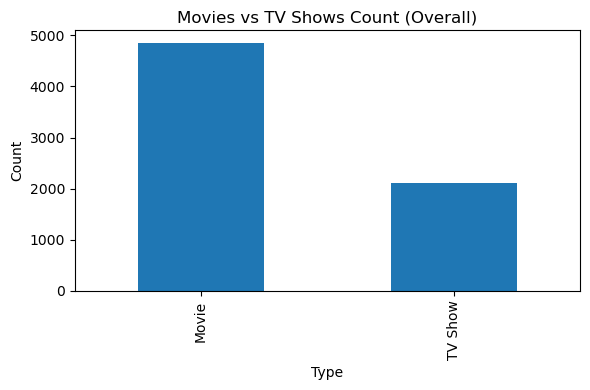

<Figure size 800x400 with 0 Axes>

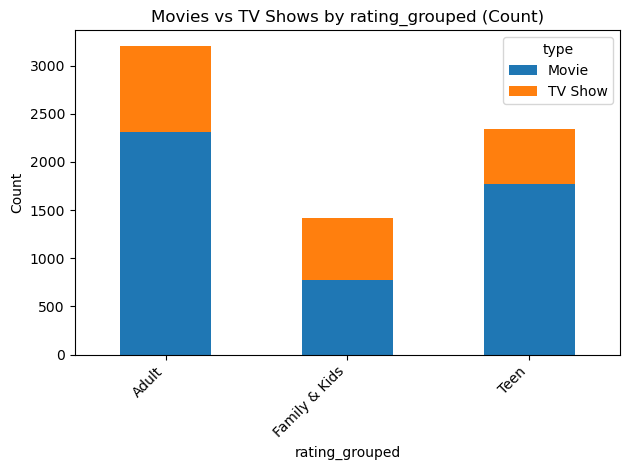

<Figure size 800x400 with 0 Axes>

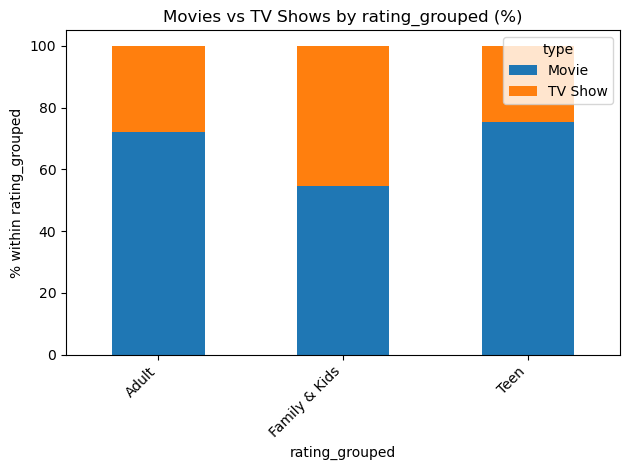

In [81]:
# =========================
# Overall: Count + %
# =========================
type_counts = X_train["type"].value_counts()
type_pct = X_train["type"].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
type_counts.plot(kind="bar")
plt.title("Movies vs TV Shows Count (Overall)")
plt.xlabel("Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# =========================
# Per rating_grouped: Counts
# =========================
type_by_rating = (
    X_train.groupby("rating_grouped")["type"]
      .value_counts()
      .unstack(fill_value=0)
)

type_by_rating_pct = type_by_rating.div(type_by_rating.sum(axis=1), axis=0) * 100

plt.figure(figsize=(8, 4))
type_by_rating.plot(kind="bar", stacked=True)
plt.title("Movies vs TV Shows by rating_grouped (Count)")
plt.xlabel("rating_grouped")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
type_by_rating_pct.plot(kind="bar", stacked=True)
plt.title("Movies vs TV Shows by rating_grouped (%)")
plt.xlabel("rating_grouped")
plt.ylabel("% within rating_grouped")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# =========================
# % of each type split across rating groups
# =========================
type_by_rating_col_pct = type_by_rating.div(type_by_rating.sum(axis=0), axis=1) * 100

## Country Column

The number of unique country categories is: 117


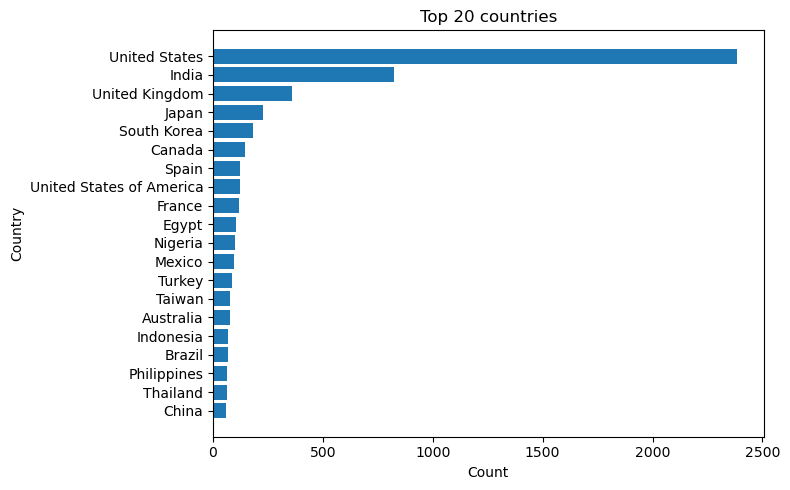

{'Kazakhstan', 'France', 'Malawi', 'Indonesia', 'Poland', 'Hungary', 'East Germany', 'Syrian Arab Republic', 'United Arab Emirates', 'Japan', 'Russia', 'Czech Republic', 'Greece', 'Cayman Islands', 'New Zealand', 'Spain', 'Turkey', 'Saudi Arabia', 'Uganda', 'Luxembourg', 'Egypt', 'Georgia', 'Brazil', 'Ukraine', 'Bulgaria', 'United Kingdom', 'Switzerland', 'Guatemala', 'Palestine', 'Dominican Republic', 'Norway', 'French Polynesia', 'United States of America', 'South Korea', 'Denmark', 'Qatar', 'Ireland', 'Namibia', 'Peru', 'Malaysia', 'Slovenia', 'United States', 'Nicaragua', 'Vietnam', 'Soviet Union', 'Iran', 'Armenia', 'Jordan', 'Serbia', 'Philippines', 'Vatican City', 'India', 'China', 'Paraguay', 'Lebanon', 'Mauritius', 'Venezuela', 'Austria', 'Bangladesh', 'Israel', 'Senegal', 'Italy', 'Finland', 'Algeria', 'Argentina', 'Syria', 'Malta', 'Kenya', 'Sweden', 'Australia', 'Bahamas', 'Cameroon', 'Mozambique', 'Nigeria', 'Jamaica', 'Germany', 'Zimbabwe', 'Ghana', 'Belarus', 'Hong Kong'

In [82]:
X_train["country_list"] = (
    X_train["country"]
    .astype(str)
    .str.split(",")
    .apply(lambda xs: [x.strip() for x in xs if x.strip()])
)

# 2) How many names per item
X_train["country_count"] = X_train["country_list"].apply(len)
fig1 = df_to_plotly_table(X_train["country_count"].describe(), "Country Count")
fig1.show()


# 2) Overall frequency
country_freq = X_train.explode("country_list")["country_list"].value_counts()

# 3) Count per label for each country
country_by_label = (
    X_train.explode("country_list")
      .groupby(["country_list", "rating_grouped"])
      .size()
      .unstack(fill_value=0)   # columns = labels
)

country_by_label = country_by_label.div(country_freq, axis=0) * 100

# 4) Limit to top N overall and keep the label columns
top_n = 50
country_by_label_top = country_by_label.loc[country_freq.head(top_n).index]
country_by_label_pct_top_fmt = country_by_label_top.map(lambda x: f"{x:.2f}%")
country_by_label_pct_top_fmt['overall'] = country_freq 
fig2 = df_to_plotly_table(country_by_label_pct_top_fmt[:10], 'Country Appearance')
fig2.show()

all_country = set()
X_train["country_list"].apply(lambda x: all_country.update(x))
print(f"The number of unique country categories is: {len(all_country)}")

country_counts = X_train["country"].value_counts().head(20).sort_values()

plt.figure(figsize=(8, 5))
plt.barh(country_counts.index, country_counts.values)
plt.title("Top 20 countries")
plt.xlabel("Count")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

print(all_country)

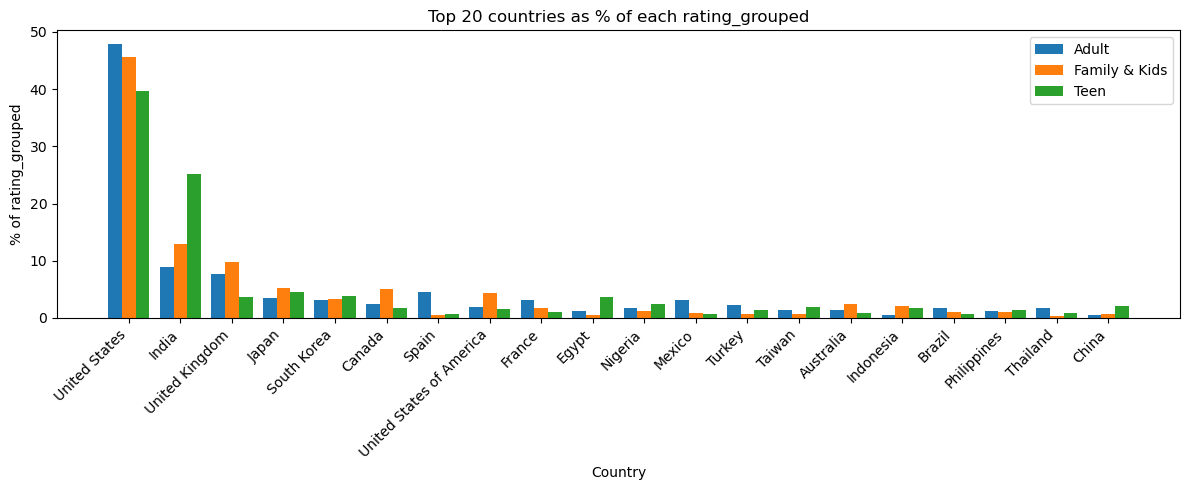

In [83]:
top_n = 20
top_countries = X_train["country"].value_counts().head(top_n).index

# counts table: rows=countries, cols=rating_grouped
country_by_label = (
    X_train[X_train["country"].isin(top_countries)]
      .groupby(["country", "rating_grouped"])
      .size()
      .unstack(fill_value=0)
      .loc[top_countries]
)

# % FROM rating_grouped (column-wise)
country_by_label_pct = country_by_label.div(country_by_label.sum(axis=0), axis=1) * 100

# grouped bar plot
x = np.arange(len(country_by_label_pct.index))
labels = list(country_by_label_pct.columns)
width = 0.8 / max(len(labels), 1)

plt.figure(figsize=(12, 5))
for i, lab in enumerate(labels):
    plt.bar(
        x + i * width - (len(labels) - 1) * width / 2,
        country_by_label_pct[lab].values,
        width,
        label=str(lab)
    )

plt.xticks(x, country_by_label_pct.index, rotation=45, ha="right")
plt.xlabel("Country")
plt.ylabel("% of rating_grouped")
plt.title(f"Top {top_n} countries as % of each rating_grouped")
plt.legend()
plt.tight_layout()
plt.show()

In [84]:
cleanup_map = {
    "United States of America": "United States",
    "Syrian Arab Republic": "Syria"}

def normalize_country_list(country_list, cleanup_map):
    return [
        cleanup_map.get(c, c)
        for c in country_list
    ]

X_train["country_list_clean"] = X_train["country_list"].apply(
    normalize_country_list,
    cleanup_map=cleanup_map
)

X_train["country_list_clean"]

all_countries_clean = set()
X_train["country_list_clean"].apply(all_countries_clean.update)

print(f"Unique country tokens after cleanup: {len(all_countries_clean)}")
print(sorted(all_countries_clean))


all_countries_before = set()
X_train["country_list"].apply(all_countries_before.update)

removed = all_countries_before - all_countries_clean
merged_into_existing = set(cleanup_map.keys()) & all_countries_before

print("Removed tokens:", removed)
print("Merged via cleanup_map:", merged_into_existing)

Unique country tokens after cleanup: 115
['Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bangladesh', 'Belarus', 'Belgium', 'Bermuda', 'Brazil', 'Bulgaria', 'Cambodia', 'Cameroon', 'Canada', 'Cayman Islands', 'Chile', 'China', 'Colombia', 'Croatia', 'Cuba', 'Cyprus', 'Czech Republic', 'Denmark', 'Dominican Republic', 'East Germany', 'Ecuador', 'Egypt', 'Finland', 'France', 'French Polynesia', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Guatemala', 'Hong Kong', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Kuwait', 'Lebanon', 'Liechtenstein', 'Luxembourg', 'Malawi', 'Malaysia', 'Malta', 'Mauritius', 'Mexico', 'Mongolia', 'Montenegro', 'Morocco', 'Mozambique', 'Namibia', 'Nepal', 'Netherlands', 'New Zealand', 'Nicaragua', 'Nigeria', 'Norway', 'Pakistan', 'Palestine', 'Panama', 'Paraguay', 'Peru', 'Philippines', 'Poland', 'Portugal', 'P

In [85]:
X_train["country_clean"] = X_train["country_list_clean"].apply(
    lambda xs: ", ".join(xs)
)

X_train["country_clean"]

6222             United States
1373                    Turkey
6994             United States
8144                     India
1409             United States
                 ...          
1973             United States
7933             United States
8190    Finland, United States
7272                    France
3501             United States
Name: country_clean, Length: 6967, dtype: object

In [86]:
def normalize_country(
    series: pd.Series,
    cleanup_map: dict,
    return_list: bool = False
):
    """
    Normalize a country column that may contain multiple comma-separated countries.

    - Applies alias cleanup (e.g. 'United States of America' → 'United States')
    - Preserves order
    - Does NOT deduplicate or sort (EDA-equivalent behavior)

    Parameters
    ----------
    series : pd.Series
        Country column (string-based)
    cleanup_map : dict
        Mapping of aliases to canonical names
    return_list : bool
        If True, return list of country tokens per row
        If False, return cleaned comma-separated string

    Returns
    -------
    pd.Series
    """

    def _normalize(cell):
        if pd.isna(cell):
            return [] if return_list else ""

        tokens = [
            cleanup_map.get(tok.strip(), tok.strip())
            for tok in str(cell).split(",")
            if tok.strip()
        ]

        return tokens if return_list else ", ".join(tokens)

    return series.apply(_normalize)

Check the function applys what we think

In [87]:
X_train["country_list_clean_new"] = normalize_country(
    X_train["country"],
    cleanup_map,
    return_list=True
)


def get_country_vocab_from_list(series):
    vocab = set()
    series.apply(vocab.update)
    return vocab

old_vocab = get_country_vocab_from_list(X_train["country_list"])
new_vocab = get_country_vocab_from_list(X_train["country_list_clean_new"])

print(f"Before cleanup: {len(old_vocab)}")
print(f"After cleanup : {len(new_vocab)}")


print("Removed tokens:", old_vocab - new_vocab)
print("Still present aliases:",
      set(cleanup_map.keys()) & new_vocab)

Before cleanup: 117
After cleanup : 115
Removed tokens: {'Syrian Arab Republic', 'United States of America'}
Still present aliases: set()


In [88]:
X_train["country_list_clean_old"] = X_train["country_list"].apply(
    normalize_country_list,
    cleanup_map=cleanup_map
)

diff_rows = X_train[
    X_train["country_list_clean_old"]
    != X_train["country_list_clean_new"]
]

print(f"Rows with differences: {len(diff_rows)}")
diff_rows[["country_list", "country_list_clean_old", "country_list_clean_new"]].head()

Rows with differences: 0


,country_list,country_list_clean_old,country_list_clean_new


In [89]:
X_train["country"] = normalize_country(
    X_train["country"],
    cleanup_map,
    return_list=False
)

## Description column

In [90]:
X_train["description"] = X_train["description"].fillna("").astype(str)
X_train["char_len"] = X_train["description"].str.len()
X_train["word_len"] = X_train["description"].str.split().apply(len)

fig1 = df_to_plotly_table(X_train[["char_len", 'word_len']].describe(), "Generl Length of Description")
fig1.show()

# Exact duplicates
dupes = X_train[X_train["description"].duplicated(keep=False)].sort_values(by="description")

fig2 = df_to_plotly_table(dupes[['description', 'rating_grouped', 'title']], f"Duplicate rows: {len(dupes)}", include_index=False )
fig2.show()

fig3 = df_to_plotly_table(X_train.groupby("rating_grouped")["word_len"].describe(), "Amount of Words Per Rating")
fig3.show()

In [91]:
# Count duplicates BEFORE removal
num_dupes_before = X_train["description"].duplicated(keep=False).sum()
num_rows_before = len(X_train)

print(f"Duplicate rows (before removal): {num_dupes_before}")
print(f"Total rows before removal: {num_rows_before}")

# Remove duplicate descriptions while keeping the FIRST occurrence
X_train = X_train.drop_duplicates(subset=["description"], keep="first")


num_dupes_after = X_train["description"].duplicated(keep=False).sum()
num_rows_after = len(X_train)

print(f"Duplicate rows (after removal): {num_dupes_after}")
print(f"Total rows after removal: {num_rows_after}")

print(f"Rows removed: {num_rows_before - num_rows_after}")

Duplicate rows (before removal): 28
Total rows before removal: 6967
Duplicate rows (after removal): 0
Total rows after removal: 6953
Rows removed: 14


In [92]:
STOPWORDS = set(ENGLISH_STOP_WORDS)
def tokenize_keep_stopwords(s):
    s = s.lower()
    s = re.sub(r"http\S+|www\.\S+", " URL ", s)
    s = re.sub(r"[^a-z0-9\s']", " ", s)
    return [t for t in s.split() if t]

tokens_all = X_train["description"].apply(tokenize_keep_stopwords)

X_train["stopword_ratio"] = tokens_all.apply(
    lambda ts: (sum(t in STOPWORDS for t in ts) / max(len(ts), 1))
)

# Simple lexical diversity proxy
X_train["unique_ratio"] = tokens_all.apply(lambda ts: len(set(ts)) / max(len(ts), 1))
fig1 = df_to_plotly_table(X_train.groupby('rating_grouped')["unique_ratio"].describe(), "Unique ratio by label")
fig2 = df_to_plotly_table(X_train.groupby('rating_grouped')["stopword_ratio"].describe(), title="Stopword ratio by label")
fig1.show()
fig2.show()

In [93]:
def simple_tokenize(s):
    s = s.lower()
    s = re.sub(r"http\S+|www\.\S+", " URL ", s)
    s = re.sub(r"[^a-z0-9\s']", " ", s)
    return [t for t in s.lower().split() if t not in STOPWORDS]

tokens = X_train["description"].apply(simple_tokenize)
all_tokens = [t for row in tokens for t in row]

counter = Counter(all_tokens)
print("Vocab size:", len(counter))
print("Top 20 tokens:", counter.most_common(20))

Vocab size: 17498
Top 20 tokens: [('life', 665), ('young', 587), ('new', 551), ('family', 472), ('s', 431), ('world', 419), ('man', 401), ('love', 397), ('woman', 371), ('friends', 337), ('series', 307), ('documentary', 282), ('old', 266), ('school', 263), ('finds', 252), ('home', 252), ('help', 241), ('high', 234), ('lives', 222), ('takes', 212)]


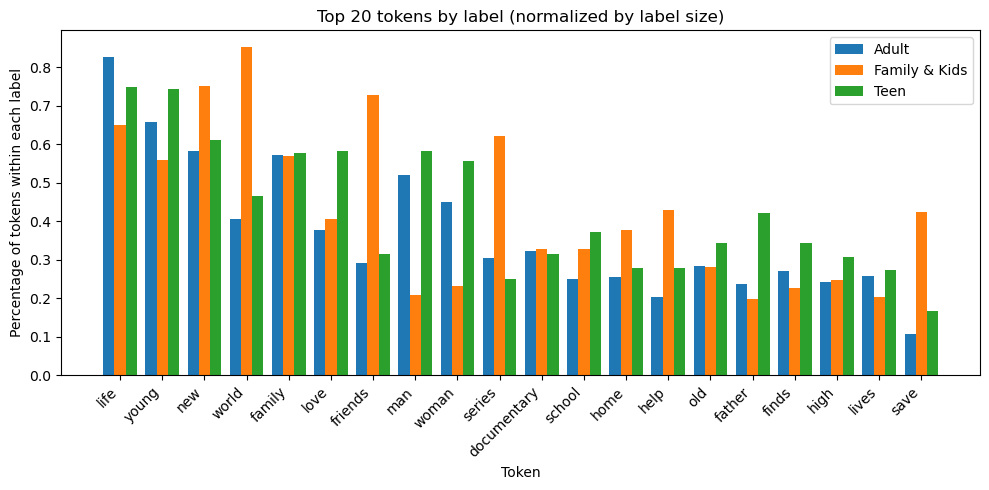

In [94]:
def plot_top_tokens_one_plot_normalized(
    df, text_col="description", label_col="rating_grouped", top_n=20
):
    # Build shared vocab on full corpus
    vec = CountVectorizer(stop_words="english", min_df=2)
    X = vec.fit_transform(df[text_col])
    terms = np.array(vec.get_feature_names_out())

    labels = sorted(df[label_col].dropna().unique())
    label_counts = {}
    label_sizes = df[label_col].value_counts().to_dict()  # number of rows per label

    for lab in labels:
        idx = (df[label_col] == lab).values
        X_lab = X[idx]
        if X_lab.shape[0] == 0:
            continue

        raw_counts = np.asarray(X_lab.sum(axis=0)).ravel()

        # Normalize by label row count -> "tokens per 100 samples of this label"
        n_lab = label_sizes.get(lab, 1)
        norm_counts = (raw_counts / raw_counts.sum()) * 100

        label_counts[lab] = norm_counts

    if not label_counts:
        print("No label token counts found.")
        return

    counts_df = pd.DataFrame(label_counts, index=terms)

    # Pick global top tokens by normalized total across labels
    counts_df["total"] = counts_df.sum(axis=1)
    top = counts_df.sort_values("total", ascending=False).head(top_n).drop(columns=["total"])

    # Grouped bar plot
    x = np.arange(len(top.index))
    n_labels = len(top.columns)
    width = 0.8 / max(n_labels, 1)

    plt.figure(figsize=(10, 5))
    for i, lab in enumerate(top.columns):
        plt.bar(
            x + i * width - (n_labels - 1) * width / 2,
            top[lab].values,
            width,
            label=str(lab),
        )

    plt.xticks(x, top.index, rotation=45, ha="right")
    plt.xlabel("Token")
    plt.ylabel("Percentage of tokens within each label")
    plt.title(f"Top {top_n} tokens by label (normalized by label size)")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_top_tokens_one_plot_normalized(X_train, top_n=20)

## Cast column 

In [95]:
# 1) Parse cast into list
X_train["cast_list"] = (
    X_train["cast"]
    .fillna("")
    .astype(str)
    .str.split(",")
    .apply(lambda xs: [x.strip() for x in xs if x.strip()])
)

# 2) How many names per item
X_train["cast_count"] = X_train["cast_list"].apply(len)
fig1 = df_to_plotly_table(X_train["cast_count"].describe(), "Cast Count")
fig1.show()


# 2) Overall frequency
cast_freq = X_train.explode("cast_list")["cast_list"].value_counts()

# 3) Count per label for each cast name
cast_by_label = (
    X_train.explode("cast_list")
      .groupby(["cast_list", "rating_grouped"])
      .size()
      .unstack(fill_value=0)   # columns = labels
)

cast_by_label = cast_by_label.div(cast_freq, axis=0) * 100

# 4) Limit to top N overall and keep the label columns
top_n = 50
cast_by_label_top = cast_by_label.loc[cast_freq.head(top_n).index]
cast_by_label_pct_top_fmt = cast_by_label_top.map(lambda x: f"{x:.2f}%")
cast_by_label_pct_top_fmt['overall'] = cast_freq 
fig2 = df_to_plotly_table(cast_by_label_pct_top_fmt[:10], 'Cast Apearence')
fig2.show()


all_cast = set()
X_train["cast_list"].apply(lambda x: all_cast.update(x))
print(f"The number of unique cast categories is: {len(all_cast)}")

The number of unique cast categories is: 32807


## Listed_in Column

In [96]:
# 1) Parse listed_in into list
X_train["listed_in_list"] = (
    X_train["listed_in"]
    .fillna("")
    .astype(str)
    .str.split(",")
    .apply(lambda xs: [x.strip() for x in xs if x.strip()])
)

# 2) How many categories per item (NEW column)
X_train["listed_in_count"] = X_train["listed_in_list"].apply(len)

fig1 = df_to_plotly_table(X_train["listed_in_count"].describe(), "Listed In Count")
fig1.show()

# 3) Overall frequency 
listed_freq = X_train.explode("listed_in_list")["listed_in_list"].value_counts()

# 4) Count per label
listed_by_label = (
    X_train.explode("listed_in_list")
      .groupby(["listed_in_list", "rating_grouped"])
      .size()
      .unstack(fill_value=0)
)

# 5) Convert to % of overall per category
listed_by_label_pct = listed_by_label.div(listed_freq, axis=0) * 100

# 6) Top N
top_n = 100
top_idx = listed_freq.head(top_n).index
listed_by_label_pct_top = listed_by_label_pct.loc[top_idx]

listed_by_label_pct_top_fmt = listed_by_label_pct_top.map(lambda x: f"{x:.2f}%")

# 7) Add overall column (for % version this is 100)
listed_by_label_pct_top_fmt["overall"] = listed_freq


fig2 = df_to_plotly_table(listed_by_label_pct_top_fmt, "Listed In Appearance (% of overall)")
fig2.show()

all_categories = set()
X_train["listed_in_list"].apply(lambda x: all_categories.update(x))
print(f"The number of unique listed_in categories is: {len(all_categories)}")

The number of unique listed_in categories is: 42


## Director Column

In [97]:
# 1) Parse director into list
X_train["director_list"] = (
    X_train["director"]
    .fillna("")
    .astype(str)
    .str.split(",")
    .apply(lambda xs: [x.strip() for x in xs if x.strip()])
)

# 2) How many directors per item (NEW column)
X_train["director_count"] = X_train["director_list"].apply(len)
extra_p = [0.01, 0.05, 0.10, 0.20, 0.25, 0.50, 0.75, 0.80, 0.90, 0.95, 0.99]

fig1 = df_to_plotly_table(X_train["director_count"].describe(percentiles=extra_p), "Director Count")
fig1.show()

# 3) Overall frequency
director_freq = X_train.explode("director_list")["director_list"].value_counts()

# 4) Count per label for each director
director_by_label = (
    X_train.explode("director_list")
      .groupby(["director_list", "rating_grouped"])
      .size()
      .unstack(fill_value=0)
)

# 5) % of overall per director 
director_by_label_pct = director_by_label.div(director_freq, axis=0) * 100

# 6) Limit to top N overall
top_n = 50
top_idx = director_freq.head(top_n).index
director_by_label_top = director_by_label_pct.loc[top_idx]

# 7) Dormat % 
director_by_label_pct_top_fmt = director_by_label_top.map(lambda x: f"{x:.2f}%")

# 8) add overall raw count (aligned)
director_by_label_pct_top_fmt["overall"] = director_freq.reindex(top_idx).values

# 9) Show
fig2 = df_to_plotly_table(director_by_label_pct_top_fmt.head(20), "Director Appearance")
fig2.show()

all_directors = set()
X_train["director_list"].apply(lambda x: all_directors.update(x))
print(f"The number of unique directores categories is: {len(all_directors)}")

The number of unique directores categories is: 5759


## Release Year Column

Missing/invalid release_year: 0


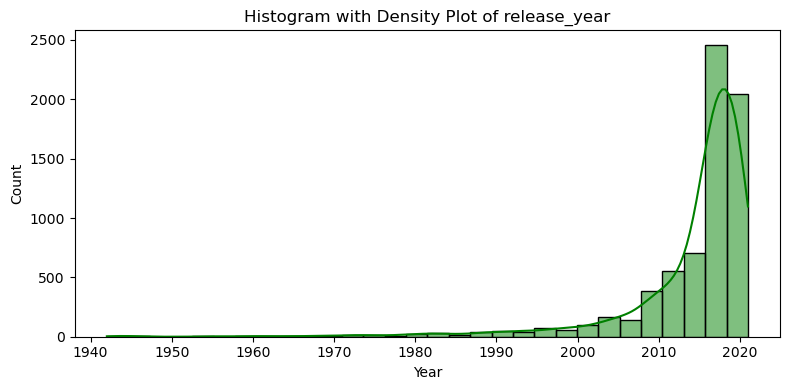

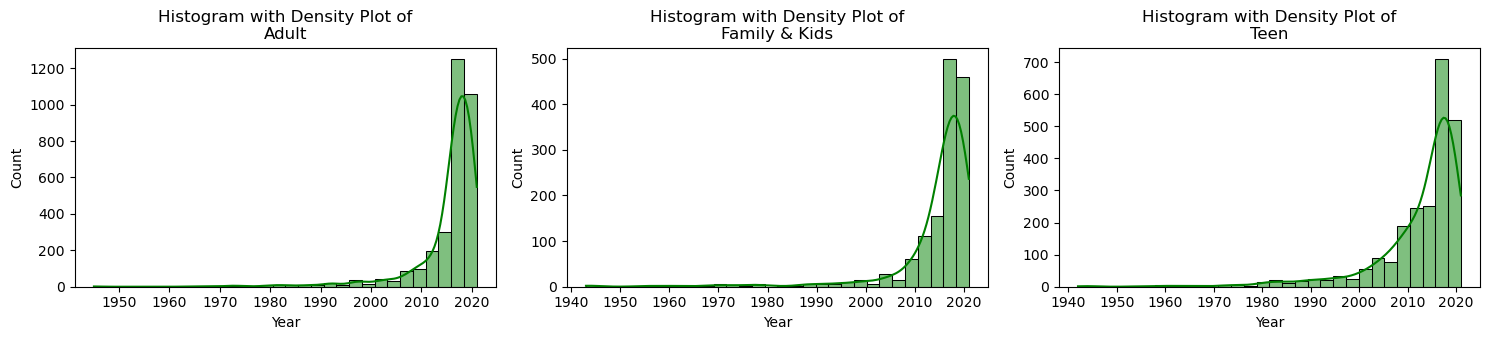

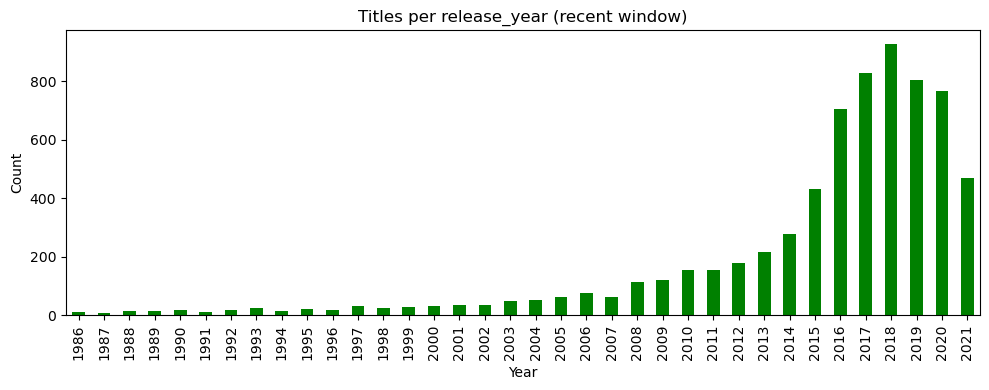

In [98]:
release_col = "release_year"

# Ensure numeric (should already be, but safe)
X_train[release_col] = pd.to_numeric(X_train[release_col], errors="coerce")

# Quick quality check
print(f"Missing/invalid {release_col}:", X_train[release_col].isna().sum())

# 1) Numeric analysis
year_desc = X_train[release_col].describe()

# Plotly table helper 
fig = df_to_plotly_table(year_desc, f"{release_col} Summary")
fig.show()

# 2) Distribution plot (same style: hist + kde, green)
plt.figure(figsize=(8, 4))
sns.histplot(X_train[release_col].dropna(), kde=True, color="green", bins=30)
plt.title(f"Histogram with Density Plot of {release_col}")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 3) Analyze by rating_grouped
if "rating_grouped" in X_train.columns:
    # Summary table by label
    by_label = X_train.groupby("rating_grouped")[release_col].describe()
    fig2 = df_to_plotly_table(by_label, f"{release_col} by rating_grouped")
    fig2.show()

    # Hist + KDE per label in subplots
    labels = sorted(X_train["rating_grouped"].dropna().unique())
    n = len(labels)
    n_cols = 3
    n_rows = math.ceil(n / n_cols)

    plt.figure(figsize=(5 * n_cols, 3.5 * n_rows))
    for i, lab in enumerate(labels):
        plt.subplot(n_rows, n_cols, i + 1)
        data = X_train.loc[df["rating_grouped"] == lab, release_col].dropna()
        sns.histplot(data, kde=True, color="green", bins=30)
        plt.title(f"Histogram with Density Plot of\n{lab}")
        plt.xlabel("Year")
        plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

# 4) Simple time-volume trend: titles per release year
yearly = (
    X_train.dropna(subset=[release_col])
      .groupby(release_col)
      .size()
      .sort_index()
)

plt.figure(figsize=(10, 4))

# Show recent years window for readability 
yearly.tail(36).plot(kind="bar", color="green")
plt.title(f"Titles per {release_col} (recent window)")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Date_added Column

In [99]:
# Clean the date_added column BEFORE parsing
X_train["date_added"] = (
    X_train["date_added"]
        .astype(str)
        .str.strip()                 # remove leading/trailing spaces
        .str.replace(r'\s+', ' ', regex=True)  # collapse multiple spaces
        .str.replace("-", " ")       # normalize separators
        .str.replace("/", " ")       # normalize separators
)

6222       April 1, 2018
1373    January 27, 2021
6994    November 8, 2018
8144       March 1, 2018
1409    January 15, 2021
Name: date_added, dtype: object
Missing/invalid date_added: 0
First date_added: 2008-01-01 00:00:00


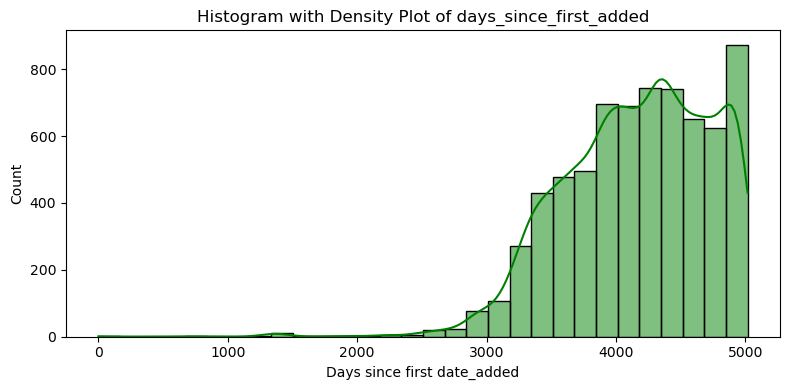

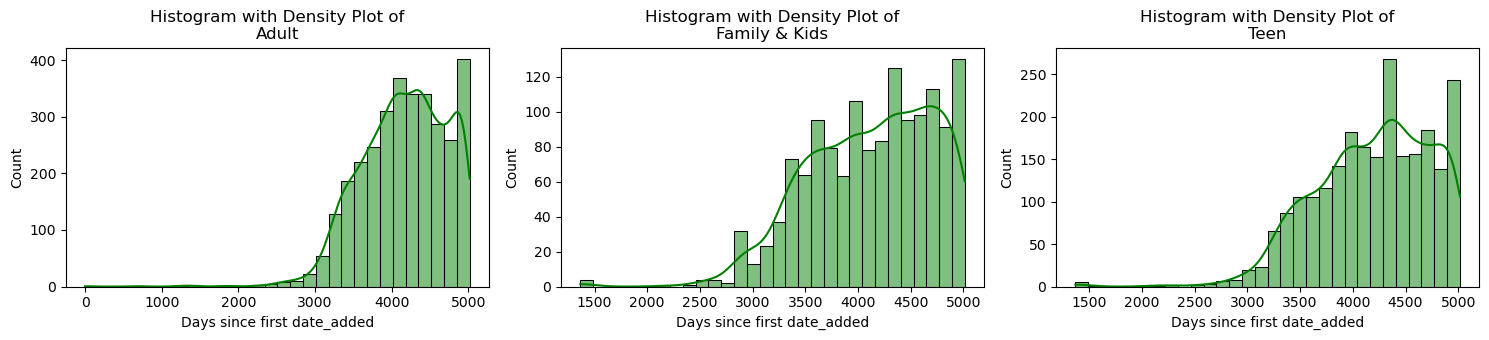

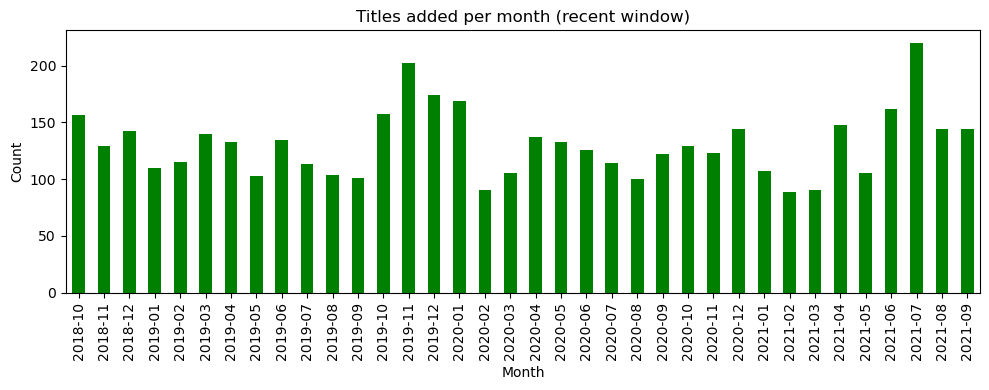

In [100]:
print(X_train["date_added"].head())

# 1) Parse textual dates -> datetime
X_train["date_added_dt"] = pd.to_datetime(X_train["date_added"], errors="coerce")

# Quick quality check
print("Missing/invalid date_added:", X_train["date_added_dt"].isna().sum())

# 2) Find the first (minimum) valid date
train_first_date = X_train["date_added_dt"].min()
print("First date_added:", train_first_date)

# 3) Transform to numeric: days since first date
X_train["days_since_first_added"] = (X_train["date_added_dt"] - train_first_date).dt.days

# 4) Numeric analysis with extra percentiles
days_desc = X_train["days_since_first_added"].describe()

# Plotly table helper (if you already defined it)
fig = df_to_plotly_table(days_desc, "Days Since First date_added")
fig.show()

# 5) Distribution plot 
plt.figure(figsize=(8, 4))
sns.histplot(X_train["days_since_first_added"].dropna(), kde=True, color="green", bins=30)
plt.title("Histogram with Density Plot of days_since_first_added")
plt.xlabel("Days since first date_added")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 6) Analyze by rating_grouped 
if "rating_grouped" in X_train.columns:
    # Summary table by label
    by_label = X_train.groupby("rating_grouped")["days_since_first_added"].describe()
    fig2 = df_to_plotly_table(by_label, "Days Since First by rating_grouped")
    fig2.show()

    # Hist + KDE per label in subplots 
    labels = sorted(X_train["rating_grouped"].dropna().unique())
    n = len(labels)
    n_cols = 3
    n_rows = math.ceil(n / n_cols)

    plt.figure(figsize=(5 * n_cols, 3.5 * n_rows))
    for i, lab in enumerate(labels):
        plt.subplot(n_rows, n_cols, i + 1)
        data = X_train.loc[X_train["rating_grouped"] == lab, "days_since_first_added"].dropna()
        sns.histplot(data, kde=True, color="green", bins=30)
        plt.title(f"Histogram with Density Plot of\n{lab}")
        plt.xlabel("Days since first date_added")
        plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

# 7) Simple time-volume trend
monthly = (
    X_train.dropna(subset=["date_added_dt"])
      .assign(month=X_train["date_added_dt"].dt.to_period("M").astype(str))
      .groupby("month")
      .size()
)

plt.figure(figsize=(10, 4))
monthly.tail(36).plot(kind="bar", color="green")  
plt.title("Titles added per month (recent window)")
plt.xlabel("Month")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [101]:
# Calculate Pearson correlation between date_added (numeric) and release_year
correlation, p_value = pearsonr(X_train['days_since_first_added'], X_train['release_year'])

print(f"Pearson Correlation between 'days_since_first_added' and 'release_year':")
print(f"  Correlation coefficient: {correlation:.4f}")
print(f"  P-value: {p_value:.4e}")
print(f"  Interpretation: {'Strong' if abs(correlation) > 0.7 else 'Moderate' if abs(correlation) > 0.4 else 'Weak'} {'positive' if correlation > 0 else 'negative'} correlation")

Pearson Correlation between 'days_since_first_added' and 'release_year':
  Correlation coefficient: 0.1031
  P-value: 6.6159e-18
  Interpretation: Weak positive correlation


## Title Column

In [102]:
# Ensure title is string
X_train["title"] = X_train["title"].fillna("").astype(str)

# Compute lengths
X_train["title_char_len"] = X_train["title"].str.len()
X_train["title_word_len"] = X_train["title"].str.split().apply(len)

# Visualize summary statistics for title lengths
fig_title_stats = df_to_plotly_table(
    X_train[["title_char_len", "title_word_len"]].describe(),
    "General Length Statistics of Titles"
).show()

# Detect exact duplicate titles
title_dupes = (
    X_train[X_train["title"].duplicated(keep=False)]
    .sort_values("title")
)

# Visualize duplicate titles
fig_title_dupes = df_to_plotly_table(
    title_dupes[['title', 'rating_grouped', 'description']],
    f"Duplicate Title Rows: {len(title_dupes)}",
    include_index=False
).show()

fig3 = df_to_plotly_table(X_train.groupby("rating_grouped")["title_word_len"].describe(), "Amount of Words in Title Per Rating")
fig3.show()

# Baseline Model

As to have a complete unbiased true baseline model, we will use only the original dataset features and represent all text columns using TF–IDF, type (Movie/TV Show) using One-Hot Encoding and keep the only numeric field "release_year" as is.
So in total our baseline feature set will be:

| Column       | Type        | Baseline Representation   |
| ------------ | ----------- | ------------------------- |
| type         | Categorical | One-hot (Movie/TV Show)   |
| title        | Text        | TF–IDF                    |
| director     | Text        | TF–IDF                    |
| cast         | Text        | TF–IDF                    |
| country      | Text        | TF–IDF                    |
| date_added   | Date        | Took days_since_first_added (numeric)
| release_year | Numeric     | Keep as integer           |
| duration     | Text        | TF–IDF                    |
| listed_in    | Text        | TF–IDF                    |
| description  | Text        | TF–IDF                    |
| show_id      | Identifier  | ❌ DROP                    |
| rating_label | Target      | 0,1,2                     |


We are not using extra features from the EDA because they are engineered, hence will increase accuracy artificially and bias future comparisons as they create dependency between EDA and modeling

For a baseline, the only features we should use are:

✔ Raw dataset columns
✔ Minimal transformations (TF–IDF, OHE)
✔ Minimal preprocessing (fill missing, etc.)


Even though by applying this for our basline model, meaning we will have thousands of TF–IDF features, that is perfectly fine.

Later more advanced models (e.g, XGBoost) will compress, learn structure, and perform better, as we will apply dimensionality reduction and smarter embeddings techniques.

## Apply simple TF-IDF Embeddings per Text Column

This way each feature contributes independently

In [103]:
# Define the feature groups 
text_features = [
    "title",
    "director",
    "cast",
    "country",
    "duration",
    "listed_in",
    "description"
]

categorical_features = ["type"]
numeric_features = ["release_year", "days_since_first_added"]

# Build the ColumnTransformer - Each text column gets its own TF–IDF vectorizer
preprocessor = ColumnTransformer(
    transformers=[
        # Separate TF-IDF for each text column
        *[
            (f"tfidf_{col}", 
             TfidfVectorizer(
                 stop_words="english",
                 max_features=5000  # limit for baseline simplicity
             ),
             col)
            for col in text_features
        ],
        
        # OneHot for type (Movie / TV Show)
        ("ohe_type", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        
        # Passthrough numeric
        ("num", "passthrough", numeric_features),
    ],
    remainder="drop"
)

Whenever we drop rows from X_train, we must also drop the same rows from y_train, otherwise we’ll get: ValueError: Found input variables with inconsistent numbers of samples

In [104]:
# Align y_train to the rows kept in X_train
y_train = y_train.loc[X_train.index]

## Baseline Model - Logistic Regression

In [105]:
# Build the Baseline Model Pipeline
baseline_model = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(
        max_iter=3000,
        multi_class="multinomial",
        n_jobs=-1
    ))
])

# Fit the Model
baseline_model.fit(X_train, y_train)

c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.



Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('tfidf_title',
                                                  TfidfVectorizer(max_features=5000,
                                                                  stop_words='english'),
                                                  'title'),
                                                 ('tfidf_director',
                                                  TfidfVectorizer(max_features=5000,
                                                                  stop_words='english'),
                                                  'director'),
                                                 ('tfidf_cast',
                                                  TfidfVectorizer(max_features=5000,
                                                                  stop_words='english'),
                                                  'cast'),
                                                 ('tfidf_country',
                                                  TfidfVectorizer(max_feature...
                                                  TfidfVectorizer(max_features=5000,
                                                                  stop_words='english'),
                                                  'listed_in'),
                                                 ('tfidf_description',
                                                  TfidfVectorizer(max_features=5000,
                                                                  stop_words='english'),
                                                  'description'),
                                                 ('ohe_type',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['type']),
                                                 ('num', 'passthrough',
                                                  ['release_year',
                                                   'days_since_first_added'])])),
                ('clf',
                 LogisticRegression(max_iter=3000, multi_class='multinomial',
                                    n_jobs=-1))])

In [106]:
X_train_transformed = baseline_model.named_steps["preprocess"].transform(X_train)
n_features = X_train_transformed.shape[1]
print(f"Total number of features after preprocessing: {n_features}")

Total number of features after preprocessing: 20371


## Preprocessing the test data like the train data

To ensure no train-test leakage we must preprocess the test set using the exact same steps as the training set, in the same order, with the same logic, using the same values learned from training (e.g., most common country, same imputation, same text cleaning). This includes:
    
1) TMDb enrichment
    
2) Country mode imputation (using mode from train)

3) Standardize country Names
    
4) Fill director/cast with "Unknown"
   
5) Clean date_added
     
6) Remove rows with duplicate descriptions

7) Ensure string formats for text features

8) Prepare 'type' column for OHE

In [107]:
def preprocess_test_data(
    df,
    country_mode,
    train_first_date,
    tmdb_cache_path="tmdb_cache.json"
):
    """
    Preprocess test data using the same steps as train:
    - TMDb enrichment
    - Country mode imputation (learned from train)
    - Standardize Country Names
    - Fill director/cast with 'Unknown'
    - Drop and Clean date_added (drop missing rows under this column and convert to datetime) and create a new feature
    - Remove duplicate descriptions
    - Ensure consistent string formats for text features
    - Prepare 'type' column for OHE
    """

    df = df.copy()
    print("Initial rows:", len(df))

    # ======================================================
    # 1. TMDb enrichment (use same cache to avoid re-calls)
    # ======================================================
    df = enrich_with_tmdb(df, cache_path=tmdb_cache_path)
    print("After TMDb:", len(df))

    # ======================================================
    # 2. Impute country using mode FROM TRAIN
    # ======================================================
    df["country"] = df["country"].fillna(country_mode)

    # ------------------------------------------------------
    # 3. Standardize Country Names (Match Train)
    # ------------------------------------------------------
    df["country"] = normalize_country(
        df["country"],
        cleanup_map,
        return_list=False
    )

    # ======================================================
    # 4. Fill cast/director with "Unknown"
    # ======================================================
    df["cast"] = df["cast"].fillna("Unknown")
    df["director"] = df["director"].fillna("Unknown")

    # ======================================================
    # 5. Drop and Clean date_added
    # ======================================================
    # ❗ Drop rows with invalid dates (same policy as train)
    df = df.dropna(subset=["date_added"])
    print("After dropna(date_added):", len(df))

    df["date_added"] = (
        df["date_added"]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.replace("-", " ")
        .str.replace("/", " ")
    )

    df["date_added_dt"] = pd.to_datetime(df["date_added"], errors="coerce")

    # ✅ Create numeric time feature 
    df["days_since_first_added"] = (
        df["date_added_dt"] - train_first_date
    ).dt.days

    # ======================================================
    # 6. Remove duplicate descriptions 
    # ======================================================
    df = df.drop_duplicates(subset=["description"], keep="first")
    print("After drop_duplicates(description):", len(df))


    # ======================================================
    # 7. Ensure all text columns remain text (string) for TF-IDF
    # ======================================================
    text_columns = [
        "title", "director", "cast", "country",
        "duration", "listed_in", "description"
    ]

    for col in text_columns:
        df[col] = df[col].fillna("").astype(str)

    # ======================================================
    # 8. Ensure type is clean for OHE in the model pipeline
    # ======================================================
    df["type"] = df["type"].fillna("Unknown").astype(str)

    return df

In [108]:
# Apply the Preprocessing to the Test Set
X_test_preprocessed = preprocess_test_data(
    X_test,
    country_mode=train_country_mode,       # use mode from training
    train_first_date=train_first_date,     # use first date from train
    tmdb_cache_path="tmdb_cache.json"
)

Initial rows: 1744
Rows with at least one missing [director/cast/country]: 711
Cache currently has 3446 entries.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_21032\2487003707.py:31: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21032\2487003707.py:31: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21032\2487003707.py:31: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21032\2487003707.py:33: SettingWithCopyWarning:


A value

Total new TMDb API calls made in this run: 0
After TMDb: 1744
After dropna(date_added): 1741
After drop_duplicates(description): 1738


C:\Users\ASUS\AppData\Local\Temp\ipykernel_21032\2487003707.py:31: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21032\2487003707.py:35: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21032\2487003707.py:31: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21032\2487003707.py:35: SettingWithCopyWarning:


A value

As can be seen we "lose" 6 observations in the test set following this pre-processing procedure 

Whenever we drop rows from X_test, we must also drop the same rows from y_test, otherwise we’ll get: ValueError: Found input variables with inconsistent numbers of samples

In [109]:
# Align y_test to the rows kept in X_test_preprocessed
X_test_preprocessed = pd.read_csv("data/X_test_preprocessed.csv", index_col=0)
y_test = y_test.loc[X_test_preprocessed.index]

After preprocessing X_test once, we will save it as a different csv, mostly because the TMDb API is slow and the enrichment results are deterministic with the same cache file. Once preprocessed, running inference later should be instant. This avoids accidentally modifying the test set differently in future runs (ensures reproducibility).

In [110]:
#  X_test_preprocessed.to_csv("data/X_test_preprocessed.csv", index=True)
y_test.to_csv("data/y_test_enriched.csv", index=True)

## Evaluation Function

In [111]:
def evaluate_multiclass_classifier(
    y_true,
    y_pred,
    y_proba=None,
    class_names=None,
    title_prefix="Model"
):
    """
    Compute and display multiclass metrics:
    - Accuracy
    - Precision/Recall/F1 per class
    - Macro & weighted averages
    - Confusion matrix (heatmap)
    - ROC curves (one-vs-rest) and macro AUC if y_proba is given.
    
    Parameters
    ----------
    y_true : array-like, shape (n_samples,)
        True labels.
    y_pred : array-like, shape (n_samples,)
        Predicted labels.
    y_proba : array-like, shape (n_samples, n_classes), optional
        Predicted probabilities for each class (for ROC curves).
    class_names : list of str, optional
        Names for each class, in order [0, 1, 2, ...].
    title_prefix : str
        Prefix for plot titles.
    """
    if class_names is None:
        class_names = [str(c) for c in sorted(np.unique(y_true))]
    
    print(f"\n{title_prefix} - Overall Accuracy: {accuracy_score(y_true, y_pred):.4f}\n")
    
    # Detailed per-class metrics
    print(f"{title_prefix} - Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"{title_prefix} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()
    
    # ROC curves: only if we have probabilities
    if y_proba is not None:
        n_classes = y_proba.shape[1]
        
        # Binarize true labels for one-vs-rest ROC
        y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))
        
        plt.figure(figsize=(7, 5))
        aucs = []
        
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
            auc = roc_auc_score(y_true_bin[:, i], y_proba[:, i])
            aucs.append(auc)
            plt.plot(fpr, tpr, label=f"Class {class_names[i]} (AUC = {auc:.3f})")
        
        # Chance line
        plt.plot([0, 1], [0, 1], "k--", label="Chance")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{title_prefix} - One-vs-Rest ROC Curves")
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        print(f"{title_prefix} - Mean AUC across classes: {np.mean(aucs):.4f}")

## Predictions & Evaluation


Baseline Logistic Regression (TF-IDF per feature) - Overall Accuracy: 0.6536

Baseline Logistic Regression (TF-IDF per feature) - Classification Report:

               precision    recall  f1-score   support

Family & Kids       0.74      0.66      0.69       351
         Teen       0.54      0.51      0.53       585
        Adult       0.70      0.75      0.72       802

     accuracy                           0.65      1738
    macro avg       0.66      0.64      0.65      1738
 weighted avg       0.65      0.65      0.65      1738



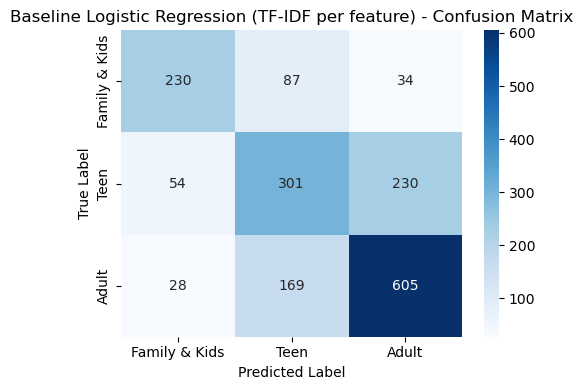

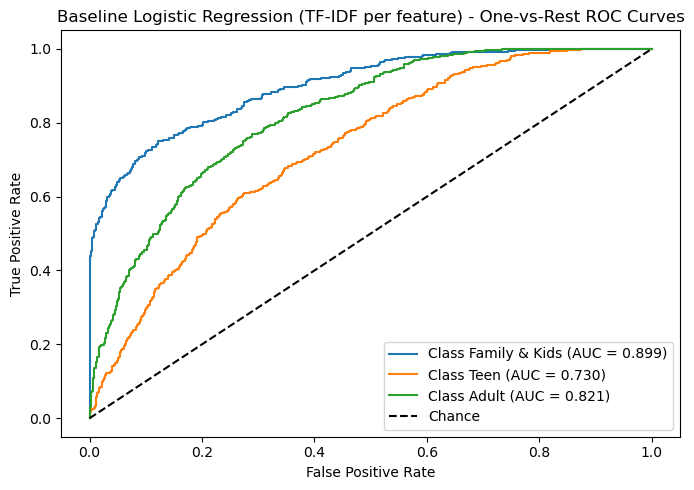

Baseline Logistic Regression (TF-IDF per feature) - Mean AUC across classes: 0.8164


In [112]:
y_pred = baseline_model.predict(X_test_preprocessed)
y_proba = baseline_model.predict_proba(X_test_preprocessed)

class_names = ['Family & Kids', 'Teen', 'Adult']

evaluate_multiclass_classifier(
    y_true=y_test,
    y_pred=y_pred,
    y_proba=y_proba,
    class_names=class_names,
    title_prefix="Baseline Logistic Regression (TF-IDF per feature)"
)

# Feature Engineering 

For our later training models we propose to apply to the following columns an LLM embedding:
text_features = [
    "title",
    "director",
    "cast",
    "duration",
    "description"
]


OHE the type column and MultiLabelBinarizer the country and listed_in column 

And the last two columns are numeric:
numeric_features = ["release_year", "days_since_first_added"]

## MiniLM Enbeddings

In [113]:
#!pip install sentence-transformers

We decided to choose MiniLM embeddings as they are lightweight, free use and no need for an additional API that cost money such as from Open AI, OpenAI embeddings were considered, but MiniLM was chosen for reproducibility and efficiency.

In [114]:
# Load LLM model -Output dimension of 384
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

### Helper Function  - Embed a Single Text Column

In [115]:
def embed_text_column(texts, model, batch_size=64, normalize=True):
    """
    Embed a pandas Series of text using MiniLM.
    Returns a NumPy array of shape (n_samples, embedding_dim=)
    """
    texts = texts.fillna("").astype(str).tolist()
    
    embeddings = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=normalize
    )
    return embeddings

### Embed All Text Columns

Each entry:
 - Shape → (n_samples, 384)
 - Stored separately

In [116]:
text_features = [
    "title",
    "director",
    "cast",
    "duration",
    "description"
]

X_train_embeddings = {}

for col in text_features:
    print(f"Embedding column: {col}")
    X_train_embeddings[col] = embed_text_column(
        X_train[col],
        model=embedding_model
    )

Embedding column: title
Embedding column: director
Embedding column: cast
Embedding column: duration
Embedding column: description


Combine text embeddings into ONE matrix

In [117]:
X_train_text_emb = np.hstack([
    X_train_embeddings[col] for col in text_features
])

# Shape Sanity Check - (n_samples, 384 × len(text_features)) = (n, 1920)
print("Text features matrix shape:", X_train_text_emb.shape)

Text features matrix shape: (6953, 1920)


These embeddings of the text columns are much smaller than the TF-IDF embeddings and are much richer semantically 

## Encode Categorical Features 

### Country Column

The country attribute is a multi-label categorical variable, as several titles are produced in multiple countries. Therefore, instead of standard one-hot encoding, we applied multi-hot encoding using MultiLabelBinarizer, rather than standard one-hot encoding, ensuring that each country contributes independently to the feature space without conflating combined values into artificial categories.

In [118]:
X_train["country_list"] = normalize_country(
    X_train["country"],
    cleanup_map,
    return_list=True
)


X_train["country_list"] = X_train["country_list"].apply(
    lambda xs: xs if len(xs) > 0 else [train_country_mode]
)

# Fit MultiLabelBinarizer on TRAIN only
mlb_country = MultiLabelBinarizer()

X_train_country = mlb_country.fit_transform(X_train["country_list"])


# Sanity Check - Should be 115 features
print("Country feature matrix shape:", X_train_country.shape)
print("Country feature count:", X_train_country.shape[1])
print("Countries:", mlb_country.classes_)

Country feature matrix shape: (6953, 115)
Country feature count: 115
Countries: ['Albania' 'Algeria' 'Angola' 'Argentina' 'Armenia' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas' 'Bangladesh' 'Belarus' 'Belgium' 'Bermuda'
 'Brazil' 'Bulgaria' 'Cambodia' 'Cameroon' 'Canada' 'Cayman Islands'
 'Chile' 'China' 'Colombia' 'Croatia' 'Cuba' 'Cyprus' 'Czech Republic'
 'Denmark' 'Dominican Republic' 'East Germany' 'Ecuador' 'Egypt' 'Finland'
 'France' 'French Polynesia' 'Georgia' 'Germany' 'Ghana' 'Greece'
 'Guatemala' 'Hong Kong' 'Hungary' 'Iceland' 'India' 'Indonesia' 'Iran'
 'Iraq' 'Ireland' 'Israel' 'Italy' 'Jamaica' 'Japan' 'Jordan' 'Kazakhstan'
 'Kenya' 'Kuwait' 'Lebanon' 'Liechtenstein' 'Luxembourg' 'Malawi'
 'Malaysia' 'Malta' 'Mauritius' 'Mexico' 'Mongolia' 'Montenegro' 'Morocco'
 'Mozambique' 'Namibia' 'Nepal' 'Netherlands' 'New Zealand' 'Nicaragua'
 'Nigeria' 'Norway' 'Pakistan' 'Palestine' 'Panama' 'Paraguay' 'Peru'
 'Philippines' 'Poland' 'Portugal' 'Puerto Rico' 'Qatar' 'Romania'
 

### Listed_in Column

In [119]:
mlb_listed_in = MultiLabelBinarizer()

X_train_listed_in = mlb_listed_in.fit_transform(
    X_train["listed_in_list"]
)

# Sanity Check - should be 42
print("listed_in feature count:", X_train_listed_in.shape[1])
print("listed_in classes:", mlb_listed_in.classes_)

listed_in feature count: 42
listed_in classes: ['Action & Adventure' 'Anime Features' 'Anime Series' 'British TV Shows'
 'Children & Family Movies' 'Classic & Cult TV' 'Classic Movies'
 'Comedies' 'Crime TV Shows' 'Cult Movies' 'Documentaries' 'Docuseries'
 'Dramas' 'Faith & Spirituality' 'Horror Movies' 'Independent Movies'
 'International Movies' 'International TV Shows' "Kids' TV"
 'Korean TV Shows' 'LGBTQ Movies' 'Movies' 'Music & Musicals' 'Reality TV'
 'Romantic Movies' 'Romantic TV Shows' 'Sci-Fi & Fantasy'
 'Science & Nature TV' 'Spanish-Language TV Shows' 'Sports Movies'
 'Stand-Up Comedy' 'Stand-Up Comedy & Talk Shows' 'TV Action & Adventure'
 'TV Comedies' 'TV Dramas' 'TV Horror' 'TV Mysteries'
 'TV Sci-Fi & Fantasy' 'TV Shows' 'TV Thrillers' 'Teen TV Shows'
 'Thrillers']


### Type Columns

In [120]:
# Encode type separately with OneHotEncoder
ohe_type = OneHotEncoder(handle_unknown="ignore", drop="if_binary")
X_train_type = ohe_type.fit_transform(X_train[["type"]]).toarray()

# Sanity Check 
print("Type features matrix shape:", X_train_type.shape)

Type features matrix shape: (6953, 1)


The binary categorical variable type (Movie / TV Show) was encoded using one-hot encoding. Since this variable is binary, one of the resulting dummy variables was dropped to avoid perfect multicollinearity, without loss of information.

## Add Numeric Features 

In [121]:
numeric_features = ["release_year", "days_since_first_added"]

X_train_num = X_train[numeric_features].values

# Sanity Check 
print("Numeric features matrix shape:", X_train_num.shape)

Numeric features matrix shape: (6953, 2)


As opposed to the baseline model here we will also standardize the numeric columns

In [122]:
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_num)

## Final Training Dataframe

In [123]:
X_train_final = np.hstack([
    X_train_text_emb,      # MiniLM embeddings
    X_train_country,       # MLB country
    X_train_listed_in,     # MLB listed_in
    X_train_type,          # OHE binary
    X_train_num            # scaled numeric
])

# Sanity Check 
print("Final feature matrix shape:", X_train_final.shape)

Final feature matrix shape: (6953, 2080)


2080 = 1920 (text) + 115 (country) + 42 (listed in) + 1 (type) + 2 (numeric)

## Preprocessing the Test Data (Consistency with Training)

To ensure a fair and leakage-free evaluation, the test dataset must undergo exactly the same preprocessing steps as the training data, applied in the same order, using only information learned from the training set. No statistics, encoders, or transformations are re-learned from the test data.

The following preprocessing pipeline is therefore applied to the test set:

1) TMDb Metadata Enrichment - Missing values in director, cast, and country are enriched using the TMDb API, reusing the same cache file created during training to ensure consistency and avoid redundant API calls.

2) Country Imputation Using Training Mode - Remaining missing values in the country attribute are imputed using the most frequent country observed in the training set. This preserves the global distribution of the feature without introducing label-specific bias.

3) Country Name Standardization - Known naming inconsistencies (e.g., “United States of America” vs. “United States”) are resolved using a fixed mapping, ensuring alignment between training and test representations.

4) Explicit Handling of Missing Contributors - Missing values in director and cast are replaced with the explicit token “Unknown”, allowing the model to learn whether missingness itself carries predictive information.

5) Temporal Feature Processing - Observations with invalid dates are removed using the same policy as in training. The date_added attribute is cleaned and parsed into a datetime format.  A numeric temporal feature, days_since_first_added, is then computed using the earliest valid date observed in the training set, ensuring consistent temporal encoding and preventing information leakage.

6) Duplicate Description Removal - Exact duplicate descriptions are removed to avoid redundant textual information that could artificially inflate model confidence.

7) Textual Feature Normalization - All text-based features are explicitly cast to string format to ensure compatibility with downstream embedding and vectorization pipelines.

8) Categorical Feature Preparation - The type attribute which is binary in OHE and the country column which can contain several countries under a single observation undergoes multilabel binarization. 


This procedure guarantees that the test data is transformed in a fully deterministic and label-agnostic manner, mirroring the training preprocessing exactly and ensuring that model performance reflects true generalization rather than preprocessing artifacts.

In [124]:
def new_preprocess_test_data(
    df,
    country_mode,
    train_first_date,
    tmdb_cache_path="tmdb_cache.json"
):
    """
    Preprocess the test dataset using the EXACT same steps as the training set.
    No encoders or scalers are fit here — only transformations.

    Steps:
    1. TMDb metadata enrichment (shared cache)
    2. Country mode imputation (from training)
    3. Country name standardization
    4. Fill missing director/cast with 'Unknown'
    5. Clean and parse date_added
    6. Compute days_since_first_added using training reference date
    7. Remove duplicate descriptions
    8. Ensure correct data types for modeling
    """

    df = df.copy()
    print("Initial rows:", len(df))

    # ======================================================
    # 1. TMDb enrichment (shared cache)
    # ======================================================
    df = enrich_with_tmdb(df, cache_path=tmdb_cache_path)
    print("After TMDb:", len(df))

    # ======================================================
    # 2. Impute country using TRAIN mode
    # ======================================================
    df["country"] = df["country"].fillna(country_mode)

    # ======================================================
    # 3. Standardize country names
    # ======================================================
    df["country_list"] = normalize_country(
        df["country"],
        cleanup_map,
        return_list=True
    )
    
    # ======================================================
    # 4. Fill missing cast/director with "Unknown"
    # ======================================================
    df["cast"] = df["cast"].fillna("Unknown")
    df["director"] = df["director"].fillna("Unknown")

    # ======================================================
    # 5. Clean and parse date_added
    # ======================================================
    # Remove invalid dates (same policy as training)
    df = df.dropna(subset=["date_added"])
    print("After dropna(date_added):", len(df))

    df["date_added"] = (
        df["date_added"]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.replace("-", " ")
        .str.replace("/", " ")
    )

    df["date_added_dt"] = pd.to_datetime(df["date_added"], errors="coerce")

    # ======================================================
    # 6. Create numeric temporal feature
    # ======================================================
    df["days_since_first_added"] = (
        df["date_added_dt"] - train_first_date
    ).dt.days

    # ======================================================
    # 7. Remove duplicate descriptions
    # ======================================================
    df = df.drop_duplicates(subset=["description"], keep="first")
    print("After drop_duplicates(description):", len(df))

    # ======================================================
    # 8. Ensure correct data types for modeling
    # ======================================================
    text_columns = [ "title", "director", "cast", "duration", "description"]  

    for col in text_columns:
        df[col] = df[col].fillna("").astype(str)

    df["type"] = df["type"].fillna("Unknown").astype(str)

    return df

In [125]:
# Applying the preprocessing
X_test_preprocessed = new_preprocess_test_data(
    X_test,
    country_mode=train_country_mode,
    train_first_date=train_first_date,
    tmdb_cache_path="tmdb_cache.json"
)

# Align labels - Align y_test to the rows kept in X_test_preprocessed
y_test = y_test.loc[X_test_preprocessed.index]

Initial rows: 1744
Rows with at least one missing [director/cast/country]: 711
Cache currently has 3446 entries.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_21032\2487003707.py:31: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21032\2487003707.py:31: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21032\2487003707.py:31: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21032\2487003707.py:33: SettingWithCopyWarning:


A value

Total new TMDb API calls made in this run: 0
After TMDb: 1744
After dropna(date_added): 1741
After drop_duplicates(description): 1738


C:\Users\ASUS\AppData\Local\Temp\ipykernel_21032\2487003707.py:31: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21032\2487003707.py:31: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21032\2487003707.py:35: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21032\2487003707.py:31: SettingWithCopyWarning:


A value

9) Numeric Feature Standartization - The 2 numeric columns are standadized using the same Standard Scaler from training.


## Feature Encoding and Scaling Consistency

After structural preprocessing, all features are transformed using encoders and scalers fitted exclusively on the training set, ensuring strict train–test separation:

 - Textual Feature Embeddings:
All high-cardinality textual features (title, director, cast, duration, listed_in, description) are embedded using a pretrained MiniLM sentence-transformer. The embedding model is applied identically to training and test data without refitting.

 - Multi-Label Encoding of Country:
Since titles may originate from multiple countries, the country attribute is parsed into lists and encoded using a MultiLabelBinarizer trained on the training data only. This preserves multi-country information while maintaining a fixed feature space.

 - One-Hot Encoding of Content Type:
The binary type attribute (Movie / TV Show) is encoded using a OneHotEncoder fitted on the training set, with unseen categories safely ignored.

 - Standardization of Numeric Features:
Numeric features (release_year and days_since_first_added) are standardized using a StandardScaler fitted on the training data, ensuring comparable scale across splits.

This guarantees that no feature representation, scale, or category space is influenced by test data, preserving the validity of all downstream evaluations.

### Applying TRAIN-fitted encoders to TEST

#### Country (Multi-label) 

In [126]:
X_test_preprocessed["country_list"] = X_test_preprocessed["country_list"].apply(lambda xs: xs if len(xs) > 0 else [train_country_mode])

# Mapping unseen countries in the test set → train mode
known_countries = set(mlb_country.classes_)
X_test_preprocessed["country_list"] = X_test_preprocessed["country_list"].apply(
    lambda xs: [c if c in known_countries else train_country_mode for c in xs]
)

X_test_country = mlb_country.transform(
    X_test_preprocessed["country_list"]
)

print("Country feature matrix shape:", X_test_country.shape)

Country feature matrix shape: (1738, 115)


Missing country values and unseen country categories in the test set were imputed using the most frequent country observed in the training data. This ensured consistency between training and test feature spaces and avoided introducing unseen categorical levels at inference time. We take note that this choice introduces a mild bias toward the dominant country.

#### Listed_in (Multi-label) 

In [127]:
X_test_preprocessed["listed_in_list"] = (
    X_test_preprocessed["listed_in"]
    .fillna("")
    .astype(str)
    .str.split(",")
    .apply(lambda xs: [x.strip() for x in xs if x.strip()])
)

# Map unseen categories to train mode
listed_in_mode = (
    pd.Series([g for row in X_train["listed_in_list"] for g in row])
    .mode()
    .iloc[0]
)

known_genres = set(mlb_listed_in.classes_)

X_test_preprocessed["listed_in_list"] = X_test_preprocessed["listed_in_list"].apply(
    lambda xs: [g if g in known_genres else listed_in_mode for g in xs]
)

X_test_listed_in = mlb_listed_in.transform(
    X_test_preprocessed["listed_in_list"]
)

print("Test listed_in matrix shape:", X_test_listed_in.shape)   

Test listed_in matrix shape: (1738, 42)


#### Type (One-Hot)

In [128]:
X_test_type = ohe_type.transform(
    X_test_preprocessed[["type"]]
).toarray()

# Sanity Check 
print("Type features matrix shape:", X_test_type.shape)

Type features matrix shape: (1738, 1)


#### Numeric (StandardScaler)

In [129]:
numeric_features = ["release_year", "days_since_first_added"]
X_test_num = scaler.transform(
    X_test_preprocessed[numeric_features].values
)

# Sanity Check 
print("Numeric features matrix shape:", X_test_num.shape)

Numeric features matrix shape: (1738, 2)


#### Text embeddings (MiniLM)

In [130]:
X_test_embeddings = {}

for col in text_features:
    print(f"Embedding column: {col}")
    X_test_embeddings[col] = embed_text_column(
        X_test_preprocessed[col],
        model=embedding_model
    )

Embedding column: title
Embedding column: director
Embedding column: cast
Embedding column: duration
Embedding column: description


In [131]:
# --- Text embeddings ---
X_test_text = np.hstack([
    X_test_embeddings[col] for col in text_features
])

# Shape Sanity Check - (n_samples, 384 × len(text_features)) = (n, 2304)
print("Text features matrix shape:", X_test_text.shape)

Text features matrix shape: (1738, 1920)


### Concatenate TEST features

In [132]:
# --- Final TEST matrix ---
X_test_final = np.hstack([
    X_test_text,
    X_test_country,
    X_test_listed_in,
    X_test_type,
    X_test_num
])

print("X_test_final shape:", X_test_final.shape)

X_test_final shape: (1738, 2080)


In [133]:
# Sanity Checks
assert X_train_final.shape[1] == X_test_final.shape[1]
print("✅ Feature dimensions match")

print("Train samples:", X_train_final.shape[0])
print("Test samples:", X_test_final.shape[0])
print("Total features:", X_train_final.shape[1])

✅ Feature dimensions match
Train samples: 6953
Test samples: 1738
Total features: 2080


After preprocessing and encoding, all feature representations were concatenated into a single design matrix, ensuring identical feature ordering and dimensionality across training and test sets. This step guarantees that downstream models receive consistent inputs and prevents silent misalignment errors.


Dataset Info:
  Original features: 2080
  Samples: 6953
  Maximum possible components: 2080

Variance Explained by Each Component:
  PC 1: 0.1335 (Cumulative: 0.1335)
  PC 2: 0.1101 (Cumulative: 0.2437)
  PC 3: 0.0813 (Cumulative: 0.3250)
  PC 4: 0.0524 (Cumulative: 0.3773)
  PC 5: 0.0222 (Cumulative: 0.3995)
  PC 6: 0.0193 (Cumulative: 0.4188)
  PC 7: 0.0152 (Cumulative: 0.4340)
  PC 8: 0.0140 (Cumulative: 0.4480)
  PC 9: 0.0130 (Cumulative: 0.4610)
  PC 10: 0.0119 (Cumulative: 0.4730)
  ... and 2070 more components

Optimal n_components: 192
Variance explained: 0.8001
Dimensionality reduction: 2080 → 192 features (90.8% reduction)

Fitting final PCA model with 192 components...
Training data transformed: (6953, 2080) → (6953, 192)


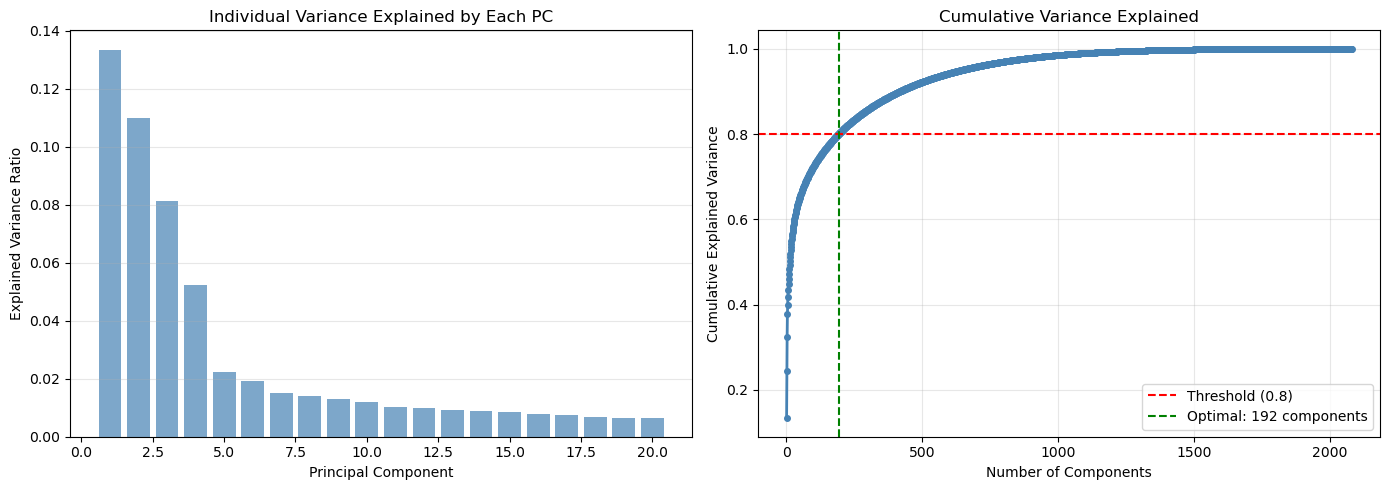

In [134]:
# ============================================================================
# DIMENSIONALITY REDUCTION USING PCA WITH VARIANCE THRESHOLD OPTIMIZATION
# ============================================================================

from sklearn.decomposition import PCA

def fit_pca_optimal(X_train, variance_threshold=0.95, plot=True):
    """
    Fit PCA with optimal n_components based on explained variance threshold.
    """
    
    max_components = min(X_train.shape[1], X_train.shape[0])
    
    print(f"\nDataset Info:")
    print(f"  Original features: {X_train.shape[1]}")
    print(f"  Samples: {X_train.shape[0]}")
    print(f"  Maximum possible components: {max_components}")
    
    # Fit PCA with maximum components to analyze variance
    pca_full = PCA(n_components=max_components)
    pca_full.fit(X_train)
    
    # Calculate cumulative explained variance
    cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)
    
    # Find optimal number of components
    n_components_optimal = np.argmax(cumsum_var >= variance_threshold) + 1
    
    print(f"\nVariance Explained by Each Component:")
    for i, var in enumerate(pca_full.explained_variance_ratio_[:min(10, len(pca_full.explained_variance_ratio_))], 1):
        print(f"  PC {i}: {var:.4f} (Cumulative: {cumsum_var[i-1]:.4f})")
    if len(pca_full.explained_variance_ratio_) > 10:
        print(f"  ... and {len(pca_full.explained_variance_ratio_) - 10} more components")
    
    print(f"\nOptimal n_components: {n_components_optimal}")
    print(f"Variance explained: {cumsum_var[n_components_optimal-1]:.4f}")
    print(f"Dimensionality reduction: {X_train.shape[1]} → {n_components_optimal} features ({(1 - n_components_optimal/X_train.shape[1])*100:.1f}% reduction)")
    
    # Fit final PCA with optimal components
    print(f"\nFitting final PCA model with {n_components_optimal} components...")
    pca_model = PCA(n_components=n_components_optimal)
    X_train_pca = pca_model.fit_transform(X_train)
    
    print(f"Training data transformed: {X_train.shape} → {X_train_pca.shape}")
    
    # Plot variance explained if requested
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Individual variance
        axes[0].bar(range(1, min(21, len(pca_full.explained_variance_ratio_) + 1)), 
                    pca_full.explained_variance_ratio_[:min(20, len(pca_full.explained_variance_ratio_))],
                    alpha=0.7, color='steelblue')
        axes[0].set_xlabel('Principal Component')
        axes[0].set_ylabel('Explained Variance Ratio')
        axes[0].set_title('Individual Variance Explained by Each PC')
        axes[0].grid(axis='y', alpha=0.3)
        
        # Cumulative variance
        axes[1].plot(range(1, len(cumsum_var) + 1), cumsum_var, 'o-', color='steelblue', linewidth=2, markersize=4)
        axes[1].axhline(y=variance_threshold, color='red', linestyle='--', label=f'Threshold ({variance_threshold})')
        axes[1].axvline(x=n_components_optimal, color='green', linestyle='--', label=f'Optimal: {n_components_optimal} components')
        axes[1].set_xlabel('Number of Components')
        axes[1].set_ylabel('Cumulative Explained Variance')
        axes[1].set_title('Cumulative Variance Explained')
        axes[1].legend()
        axes[1].grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    return X_train_pca, pca_model


def transform_data_with_pca(X_data, pca_model, data_name="Data"):
    """
    Transform data using a fitted PCA model.
    """
    
    print(f"\nTransforming {data_name}:")
    print(f"  Original shape: {X_data.shape}")
    
    X_pca = pca_model.transform(X_data)
    
    print(f"PCA-transformed shape: {X_pca.shape}")
    
    return X_pca


# ============================================================================
# FIT PCA ON TRAINING DATA
# ============================================================================

X_train_pca, pca_model = fit_pca_optimal(
    X_train=X_train_final, 
    variance_threshold=0.8,  # Keep 80% of variance
    plot=True
)


# Model Training & Evaluation

Three models are trained and compared on two feature representations:

**Feature Sets:**
- Embedded Dataset: Full features with LM embeddings (2080 features)
- PCA Dataset: Reduced dimensionality preserving 80% variance

**Models:**
1. **XGBoost**: Gradient boosting with hyperparameter tuning via Optuna
2. **Ordinal Regression**: Leverages natural rating order 
3. **Neural Network**: Multi-layer perceptron with dropout and early stopping

**Evaluation** 

---

## Ordinal Regression

Specialized model for ordered categorical outcomes that respects the natural rating hierarchy. Uses proportional odds assumption with regularization for high-dimensional features.


In [169]:
# ============================================================================
# ORDINAL REGRESSION WITH OPTUNA HYPERPARAMETER OPTIMIZATION
# ============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import cross_val_score
import optuna
from optuna.trial import Trial


def fit_ordinal_regression(X_train, y_train, n_trials=100, cv=5, use_optuna=True):
    """
    Fit Ordinal Regression model with optional Optuna hyperparameter optimization.
    """
 
    
    print(f"\nTraining Data Info:")
    print(f"  Training samples: {X_train.shape[0]}")
    print(f"  Number of features: {X_train.shape[1]}")
    print(f"  Number of classes: {len(y_train.unique())}")
    print(f"  Classes: {y_train.unique()}")
    print(f"  Class distribution:\n{np.bincount(y_train)}")

    # ========================================================================
    # OPTUNA OPTIMIZATION (Optional)
    # ========================================================================
    
    best_params = None
    study = None
    optuna_results = None
    
    if use_optuna:
        
        def objective(trial: Trial) -> float:
            """Objective function for Optuna"""
            
            # Hyperparameters to optimize
            C = trial.suggest_float('C', 0.001, 10.0, log=True)
            solver = trial.suggest_categorical('solver', ['lbfgs', 'saga'])
            max_iter = trial.suggest_int('max_iter', 500, 2000, step=100)
            tol = trial.suggest_float('tol', 1e-5, 1e-3, log=True)
            
            # Create model with suggested hyperparameters
            model = LogisticRegression(
                C=C,
                solver=solver,
                max_iter=max_iter,
                tol=tol,
                random_state=42,
                verbose=0
            )
            
            # Cross-validation score
            scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
            
            return scores.mean()
        
        print(f"\nOptimization Configuration:")
        print(f"  Number of trials: {n_trials}")
        print(f"  CV folds: {cv}")
        
        # Create and run Optuna study
        sampler = optuna.samplers.TPESampler(seed=42)
        study = optuna.create_study(direction='maximize', sampler=sampler)
        
        print(f"\nRunning optimization...")
        study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
        
        # Get best parameters
        best_trial = study.best_trial
        best_params = best_trial.params
        
        print(f"  Best CV Accuracy: {best_trial.value:.4f}")
        print(f"\nBest Hyperparameters:")
        for param, value in best_params.items():
            print(f"  {param}: {value}")
        
        optuna_results = {
            'best_trial_number': best_trial.number,
            'best_accuracy': best_trial.value,
            'best_params': best_params,
            'n_trials': n_trials,
            'study': study
        }
    
    # ========================================================================
    # TRAIN FINAL MODEL
    # ========================================================================
    
    if use_optuna and best_params:
        print(f"\nFitting final model with optimized hyperparameters...")
        ordinal_model = LogisticRegression(
            C=best_params['C'],
            solver=best_params['solver'],
            multi_class='multinomial',
            max_iter=best_params['max_iter'],
            tol=best_params['tol'],
            random_state=42,
            verbose=0
        )
    else:
        print(f"\nFitting LogisticRegression with default hyperparameters...")
        ordinal_model = LogisticRegression(
            multi_class='multinomial',
            solver='lbfgs',
            max_iter=1000,
            random_state=42,
            verbose=0
        )
    
    ordinal_model.fit(X_train, y_train)
    
    return ordinal_model, optuna_results


def predict_with_ordinal_regression(X_data, ordinal_model, y_true):
    """
    Make predictions using fitted ordinal regression model.
    """

    print(f"\nMaking predictions on data...")
    print(f"  samples: {X_data.shape[0]}")
    print(f"  Features: {X_data.shape[1]}")
    
    # Make predictions
    y_pred = ordinal_model.predict(X_data)
    y_pred_proba = ordinal_model.predict_proba(X_data)
    
    results = {
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
    }
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    results['accuracy'] = accuracy
    
    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    results['precision_macro'] = precision_macro
    
    recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    results['recall_macro'] = recall_macro
    
    f1_score_macro = f1_score(y_true, y_pred, average='macro')
    results['f1_score_macro'] = f1_score_macro
    
    print(f"\nPrediction Results:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision_macro:.4f}")
    print(f"  Recall:    {recall_macro:.4f}")
    print(f"  F1 Score:  {f1_score_macro:.4f}")
    
    # Use sorted labels to ensure consistent ordering [0, 1, 2]
    cm = confusion_matrix(y_true, y_pred, labels=sorted(np.unique(y_true)))
    results['confusion_matrix'] = cm
    
    return y_pred, y_pred_proba, results    

In [ ]:
# ============================================================================
# STEP 1: FIT ORDINAL REGRESSION WITH OPTUNA OPTIMIZATION
# ============================================================================

ordinal_model_pca, optuna_results_pca = fit_ordinal_regression(
    X_train=X_train_pca,
    y_train=y_train,
    n_trials=100,  # Number of Optuna trials
    cv=5,          # Cross-validation folds
    use_optuna=True  # Enable Optuna optimization
)

In [ ]:
ordinal_model_embeded, optuna_results_embeded = fit_ordinal_regression(
    X_train=X_train_final,
    y_train=y_train,
    n_trials=100,  # Number of Optuna trials
    cv=5,          # Cross-validation folds
    use_optuna=True  # Enable Optuna optimization
)

[I 2026-01-12 15:33:11,461] A new study created in memory with name: no-name-d6bb6227-c2f0-42d1-9083-f64a850fac82



Training Data Info:
  Training samples: 6953
  Number of features: 2080
  Number of classes: 3
  Classes: [0 2 1]
  Class distribution:
[1414 2337 3202]

Optimization Configuration:
  Number of trials: 100
  CV folds: 5

Running optimization...


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-01-12 15:33:12,982] Trial 0 finished with value: 0.6591504354107233 and parameters: {'C': 0.03148911647956861, 'solver': 'lbfgs', 'max_iter': 1400, 'tol': 2.0513382630874486e-05}. Best is trial 0 with value: 0.6591504354107233.
[I 2026-01-12 15:33:15,516] Trial 1 finished with value: 0.5872303951566834 and parameters: {'C': 0.004207053950287938, 'solver': 'saga', 'max_iter': 1400, 'tol': 0.0002607024758370766}. Best is trial 0 with value: 0.6591504354107233.
[I 2026-01-12 15:33:16,281] Trial 2 finished with value: 0.38411566382448203 and parameters: {'C': 0.0012087541473056963, 'solver': 'lbfgs', 'max_iter': 800, 'tol': 2.3102018878452926e-05}. Best is trial 0 with value: 0.6591504354107233.
[I 2026-01-12 15:33:19,606] Trial 3 finished with value: 0.6052489994385597 and parameters: {'C': 0.00541524411940254, 'solver': 'saga', 'max_iter': 1100, 'tol': 3.8234752246751835e-05}. Best is trial 0 with value: 0.6591504354107233.
[I 2026-01-12 15:33:32,883] Trial 4 finished with value:

c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.



In [ ]:
import joblib

# Save PCA model
joblib.dump(ordinal_model_pca, 'models/ordinal_model_pca.pkl')

# Save Embedded model
joblib.dump(ordinal_model_embeded, 'models/ordinal_model_embedded.pkl')

#Save the Optuna results
joblib.dump(optuna_results_pca, 'models/optuna_results_ordinal_pca.pkl')
joblib.dump(optuna_results_embeded, 'models/optuna_results_ordinal_embedded.pkl')

['models/optuna_results_ordinal_embedded.pkl']

In [171]:
# ============================================================================
# XGBOOST WITH OPTUNA HYPERPARAMETER OPTIMIZATION
# ============================================================================

import xgboost as xgb

def fit_xgboost(X_train, y_train, n_trials=100, cv=5, use_optuna=True):
    """
    Fit XGBoost classifier with optional Optuna hyperparameter optimization.
    """
    
    print(f"\nTraining Data Info:")
    print(f"  Training samples: {X_train.shape[0]}")
    print(f"  Number of features: {X_train.shape[1]}")
    print(f"  Number of classes: {len(np.unique(y_train))}")
    print(f"  Classes: {np.unique(y_train)}")
    print(f"  Class distribution:\n{np.bincount(y_train)}")

    # ========================================================================
    # OPTUNA OPTIMIZATION (Optional)
    # ========================================================================
    
    best_params = None
    study = None
    optuna_results = None
    
    if use_optuna:
        
        def objective(trial: Trial) -> float:
            """Objective function for Optuna"""
            
            # XGBoost hyperparameters to optimize
            max_depth = trial.suggest_int('max_depth', 3, 10)
            learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
            n_estimators = trial.suggest_int('n_estimators', 50, 300, step=50)
            subsample = trial.suggest_float('subsample', 0.5, 1.0)
            colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)
            gamma = trial.suggest_float('gamma', 0.0, 5.0)
            min_child_weight = trial.suggest_int('min_child_weight', 1, 10)
            
            # Create model with suggested hyperparameters
            model = xgb.XGBClassifier(
                max_depth=max_depth,
                learning_rate=learning_rate,
                n_estimators=n_estimators,
                subsample=subsample,
                colsample_bytree=colsample_bytree,
                gamma=gamma,
                min_child_weight=min_child_weight,
                random_state=42,
                verbosity=0,
                n_jobs=-1
            )
            
            # Cross-validation score
            scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
            
            return scores.mean()
        
        print(f"\nOptimization Configuration:")
        print(f"  Number of trials: {n_trials}")
        print(f"  CV folds: {cv}")
        
        # Create and run Optuna study
        sampler = optuna.samplers.TPESampler(seed=42)
        study = optuna.create_study(direction='maximize', sampler=sampler)
        
        print(f"\nRunning optimization...")
        study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
        
        # Get best parameters
        best_trial = study.best_trial
        best_params = best_trial.params
        
        print(f"  Best CV Accuracy: {best_trial.value:.4f}")
        print(f"\nBest Hyperparameters:")
        for param, value in best_params.items():
            print(f"  {param}: {value}")
        
        optuna_results = {
            'best_trial_number': best_trial.number,
            'best_accuracy': best_trial.value,
            'best_params': best_params,
            'n_trials': n_trials,
            'study': study
        }
    
    # ========================================================================
    # TRAIN FINAL MODEL
    # ========================================================================
    
    if use_optuna and best_params:
        print(f"\nFitting final XGBoost model with optimized hyperparameters...")
        xgb_model = xgb.XGBClassifier(
            max_depth=best_params['max_depth'],
            learning_rate=best_params['learning_rate'],
            n_estimators=best_params['n_estimators'],
            subsample=best_params['subsample'],
            colsample_bytree=best_params['colsample_bytree'],
            gamma=best_params['gamma'],
            min_child_weight=best_params['min_child_weight'],
            random_state=42,
            verbosity=0,
            n_jobs=-1
        )
    else:
        print(f"\nFitting XGBoost with default hyperparameters...")
        xgb_model = xgb.XGBClassifier(
            max_depth=6,
            learning_rate=0.1,
            n_estimators=100,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            verbosity=0,
            n_jobs=-1
        )
    
    xgb_model.fit(X_train, y_train, verbose=False)
    
    return xgb_model, optuna_results


def predict_with_xgboost(X_data, xgb_model, y_true=None, data_name="Data"):
    """
    Make predictions using fitted XGBoost model.
    """

    print(f"\nMaking {data_name} predictions...")
    print(f"  Samples: {X_data.shape[0]}")
    print(f"  Features: {X_data.shape[1]}")
    
    # Make predictions
    y_pred = xgb_model.predict(X_data)
    y_pred_proba = xgb_model.predict_proba(X_data)
    
    results = {
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
    }
    
    # Compute metrics if true labels provided
    if y_true is not None:
        accuracy = accuracy_score(y_true, y_pred)
        results['accuracy'] = accuracy
        
        precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
        results['precision_macro'] = precision_macro
        
        recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
        results['recall_macro'] = recall_macro
        
        f1_score_macro = f1_score(y_true, y_pred, average='macro')
        results['f1_score_macro'] = f1_score_macro
        
        print(f"\nPrediction Results:")
        print(f"  Accuracy:  {accuracy:.4f}")
        print(f"  Precision: {precision_macro:.4f}")
        print(f"  Recall:    {recall_macro:.4f}")
        print(f"  F1 Score:  {f1_score_macro:.4f}")

        # Use sorted labels to ensure consistent ordering [0, 1, 2]
        cm = confusion_matrix(y_true, y_pred, labels=sorted(np.unique(y_true)))
        results['confusion_matrix'] = cm
    
    return y_pred, y_pred_proba, results

In [ ]:

# ============================================================================
# FIT XGBOOST WITH OPTUNA OPTIMIZATION ON EMBEDDING DATA
# ============================================================================


xgb_model_embedding, xgb_optuna_results_embedding = fit_xgboost(
    X_train=X_train_final,
    y_train=y_train,
    n_trials=100,  # Number of Optuna trials
    cv=3,          # Cross-validation folds
    use_optuna=True  # Enable Optuna optimization
)

[I 2026-01-12 18:09:58,520] A new study created in memory with name: no-name-1dae5a97-aca1-4ba7-89c0-a05ce4e004cc



Training Data Info:
  Training samples: 6953
  Number of features: 2080
  Number of classes: 3
  Classes: [0 1 2]
  Class distribution:
[1414 2337 3202]

Optimization Configuration:
  Number of trials: 100
  CV folds: 3

Running optimization...


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-01-12 18:11:09,291] Trial 0 finished with value: 0.6486680131643568 and parameters: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'n_estimators': 250, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'gamma': 0.7799726016810132, 'min_child_weight': 1}. Best is trial 0 with value: 0.6486680131643568.
[I 2026-01-12 18:12:56,157] Trial 1 finished with value: 0.6488308568784814 and parameters: {'max_depth': 9, 'learning_rate': 0.07725378389307355, 'n_estimators': 250, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'gamma': 4.162213204002109, 'min_child_weight': 3}. Best is trial 1 with value: 0.6488308568784814.
[I 2026-01-12 18:13:32,751] Trial 2 finished with value: 0.6111802587197833 and parameters: {'max_depth': 4, 'learning_rate': 0.018659959624904916, 'n_estimators': 100, 'subsample': 0.762378215816119, 'colsample_bytree': 0.7159725093210578, 'gamma': 1.4561457009902097, 'min_child_weight': 7}. Best is trial 1 with val

In [ ]:

# ============================================================================
# FIT XGBOOST WITH OPTUNA OPTIMIZATION ON PCA DATA
# ============================================================================


xgb_model_pca, xgb_optuna_results_pca = fit_xgboost(
    X_train=X_train_pca,
    y_train=y_train,
    n_trials=100,  # Number of Optuna trials
    cv=3,          # Cross-validation folds
    use_optuna=True  # Enable Optuna optimization
)

[I 2026-01-12 21:25:58,274] A new study created in memory with name: no-name-84fc560c-7da6-4e71-8ca4-1d463c37229c



Training Data Info:
  Training samples: 6953
  Number of features: 192
  Number of classes: 3
  Classes: [0 1 2]
  Class distribution:
[1414 2337 3202]

Optimization Configuration:
  Number of trials: 100
  CV folds: 3

Running optimization...


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-01-12 21:26:04,990] Trial 0 finished with value: 0.6565681313887318 and parameters: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'n_estimators': 250, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'gamma': 0.7799726016810132, 'min_child_weight': 1}. Best is trial 0 with value: 0.6565681313887318.
[I 2026-01-12 21:26:14,929] Trial 1 finished with value: 0.6605183606774542 and parameters: {'max_depth': 9, 'learning_rate': 0.07725378389307355, 'n_estimators': 250, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'gamma': 4.162213204002109, 'min_child_weight': 3}. Best is trial 1 with value: 0.6605183606774542.
[I 2026-01-12 21:26:18,927] Trial 2 finished with value: 0.6213702122774606 and parameters: {'max_depth': 4, 'learning_rate': 0.018659959624904916, 'n_estimators': 100, 'subsample': 0.762378215816119, 'colsample_bytree': 0.7159725093210578, 'gamma': 1.4561457009902097, 'min_child_weight': 7}. Best is trial 1 with val

In [ ]:
# Save PCA model
joblib.dump(xgb_model_pca, 'models/xgboost/xgb_model_pca.pkl')

# Save Embedded model
joblib.dump(xgb_model_embedding, 'models/xgboost/xgb_model_embedded.pkl')

#Save the Optuna results
joblib.dump(xgb_optuna_results_pca, 'models/xgboost/xgb_optuna_results_pca.pkl')
joblib.dump(xgb_optuna_results_embedding, 'models/xgboost/xgb_optuna_results_embedded.pkl')

['models/xgboost/xgb_optuna_results_embedded.pkl']

# Elapsed Time

## Neural Network (MLP)

In [173]:
# ============================================================================
# NEURAL NETWORK TRAINING WITH OPTUNA OPTIMIZATION
# ============================================================================

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import cross_val_score
import optuna
from optuna.trial import Trial


def fit_neural_network(X_train, y_train, n_trials=100, cv=5, use_optuna=True):
    """
    Fit Neural Network (MLP) model with optional Optuna hyperparameter optimization.
    
    Args:
        X_train: Training features
        y_train: Training labels
        n_trials: Number of Optuna trials
        cv: Number of cross-validation folds
        use_optuna: Whether to use Optuna optimization
    
    Returns:
        Tuple of (trained_model, optuna_results)
    """
    
    print(f"\nTraining Data Info:")
    print(f"  Training samples: {X_train.shape[0]}")
    print(f"  Number of features: {X_train.shape[1]}")
    print(f"  Number of classes: {len(np.unique(y_train))}")
    print(f"  Classes: {np.unique(y_train)}")
    print(f"  Class distribution:\n{np.bincount(y_train)}")

    # ========================================================================
    # OPTUNA OPTIMIZATION (Optional)
    # ========================================================================
    
    best_params = None
    study = None
    optuna_results = None
    
    if use_optuna:
        
        def objective(trial: Trial) -> float:
            """Objective function for Optuna"""
            
            # Network architecture - low hidden dimensions for sparse data
            n_layers = trial.suggest_int('n_layers', 1, 3)
            hidden_layer_sizes = []
            for i in range(n_layers):
                size = trial.suggest_int(f'hidden_size_{i}', 32, 256, step=32)
                hidden_layer_sizes.append(size)
            hidden_layer_sizes = tuple(hidden_layer_sizes)
            
            # Regularization parameters
            alpha = trial.suggest_float('alpha', 1e-5, 1e-2, log=True)  # L2 penalty
            
            # Training parameters
            learning_rate_init = trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True)
            batch_size = trial.suggest_categorical('batch_size', [32, 64, 128, 256])
            max_iter = trial.suggest_int('max_iter', 200, 500, step=100)
            
            # Early stopping
            early_stopping = trial.suggest_categorical('early_stopping', [True, False])
            validation_fraction = 0.1 if early_stopping else 0.0
            
            # Create model with suggested hyperparameters
            model = MLPClassifier(
                hidden_layer_sizes=hidden_layer_sizes,
                activation='relu',  # ReLU activation as requested
                solver='adam',      # Adam optimizer as requested
                alpha=alpha,
                batch_size=batch_size,
                learning_rate_init=learning_rate_init,
                max_iter=max_iter,
                early_stopping=early_stopping,
                validation_fraction=validation_fraction,
                random_state=42,
                verbose=False
            )
            
            # Cross-validation score
            scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
            
            return scores.mean()
        
        print(f"\nOptimization Configuration:")
        print(f"  Number of trials: {n_trials}")
        print(f"  CV folds: {cv}")
        print(f"  Activation: ReLU")
        print(f"  Optimizer: Adam")
        
        # Create and run Optuna study
        sampler = optuna.samplers.TPESampler(seed=42)
        study = optuna.create_study(direction='maximize', sampler=sampler)
        
        print(f"\nRunning optimization...")
        study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
        
        # Get best parameters
        best_trial = study.best_trial
        best_params = best_trial.params
        
        print(f"\n  Best CV F1-Score: {best_trial.value:.4f}")
        print(f"\nBest Hyperparameters:")
        for param, value in best_params.items():
            print(f"  {param}: {value}")
        
        optuna_results = {
            'best_trial_number': best_trial.number,
            'best_f1_score': best_trial.value,
            'best_params': best_params,
            'n_trials': n_trials,
            'study': study
        }
    
    # ========================================================================
    # TRAIN FINAL MODEL
    # ========================================================================
    
    if use_optuna and best_params:
        print(f"\nFitting final model with optimized hyperparameters...")
        
        # Reconstruct hidden layer sizes
        n_layers = best_params['n_layers']
        hidden_layer_sizes = tuple([best_params[f'hidden_size_{i}'] for i in range(n_layers)])
        
        nn_model = MLPClassifier(
            hidden_layer_sizes=hidden_layer_sizes,
            activation='relu',
            solver='adam',
            alpha=best_params['alpha'],
            batch_size=best_params['batch_size'],
            learning_rate_init=best_params['learning_rate_init'],
            max_iter=best_params['max_iter'],
            early_stopping=best_params.get('early_stopping', True),
            validation_fraction=0.1 if best_params.get('early_stopping', True) else 0.0,
            random_state=42,
            verbose=True
        )
    else:
        print(f"\nFitting Neural Network with default hyperparameters...")
        nn_model = MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation='relu',
            solver='adam',
            alpha=0.0001,
            batch_size=128,
            learning_rate_init=0.001,
            max_iter=300,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=42,
            verbose=True
        )
    
    nn_model.fit(X_train, y_train)
    
    print(f"\nTraining completed!")
    print(f"  Number of iterations: {nn_model.n_iter_}")
    print(f"  Loss: {nn_model.loss_:.4f}")
    
    return nn_model, optuna_results


def predict_with_neural_network(X_data, nn_model, y_true):
    """
    Make predictions using fitted neural network model.
    
    Args:
        X_data: Features to predict on
        nn_model: Trained neural network model
        y_true: True labels for evaluation
    
    Returns:
        Tuple of (predictions, probabilities, results_dict)
    """
    
    print(f"\nMaking predictions on data...")
    print(f"  Samples: {X_data.shape[0]}")
    print(f"  Features: {X_data.shape[1]}")
    
    # Make predictions
    y_pred = nn_model.predict(X_data)
    y_pred_proba = nn_model.predict_proba(X_data)
    
    results = {
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
    }
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    results['accuracy'] = accuracy
    
    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    results['precision_macro'] = precision_macro
    
    recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    results['recall_macro'] = recall_macro
    
    f1_score_macro = f1_score(y_true, y_pred, average='macro')
    results['f1_score_macro'] = f1_score_macro
    
    print(f"\nPrediction Results:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision_macro:.4f}")
    print(f"  Recall:    {recall_macro:.4f}")
    print(f"  F1 Score:  {f1_score_macro:.4f}")
    
    # Use sorted labels to ensure consistent ordering [0, 1, 2]
    cm = confusion_matrix(y_true, y_pred, labels=sorted(np.unique(y_true)))
    results['confusion_matrix'] = cm
    
    return y_pred, y_pred_proba, results
    

In [ ]:
# ============================================================================
# STEP 1: FIT NEURAL NETWORK WITH OPTUNA OPTIMIZATION - PCA DATA
# ============================================================================

nn_model_pca, nn_optuna_results_pca = fit_neural_network(
    X_train=X_train_pca,
    y_train=y_train,
    n_trials=100,  # Number of Optuna trials
    cv=5,          # Cross-validation folds
    use_optuna=True  # Enable Optuna optimization
)

[I 2026-01-12 23:19:37,050] A new study created in memory with name: no-name-c44e3bc9-3d7a-49bf-b5ac-049125be8b23



Training Data Info:
  Training samples: 6953
  Number of features: 192
  Number of classes: 3
  Classes: [0 1 2]
  Class distribution:
[1414 2337 3202]

Optimization Configuration:
  Number of trials: 100
  CV folds: 5
  Activation: ReLU
  Optimizer: Adam

Running optimization...


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-01-12 23:20:08,501] Trial 0 finished with value: 0.6459611546479864 and parameters: {'n_layers': 2, 'hidden_size_0': 256, 'hidden_size_1': 192, 'alpha': 0.0006251373574521745, 'learning_rate_init': 0.0002051338263087451, 'batch_size': 128, 'max_iter': 400, 'early_stopping': False}. Best is trial 0 with value: 0.6459611546479864.
[I 2026-01-12 23:20:15,274] Trial 1 finished with value: 0.6247992708390704 and parameters: {'n_layers': 3, 'hidden_size_0': 64, 'hidden_size_1': 64, 'hidden_size_2': 64, 'alpha': 8.17949947521167e-05, 'learning_rate_init': 0.0011207606211860567, 'batch_size': 128, 'max_iter': 300, 'early_stopping': False}. Best is trial 0 with value: 0.6459611546479864.
[I 2026-01-12 23:20:17,200] Trial 2 finished with value: 0.6645778861863165 and parameters: {'n_layers': 3, 'hidden_size_0': 64, 'hidden_size_1': 160, 'hidden_size_2': 160, 'alpha': 1.3783237455007187e-05, 'learning_rate_init': 0.0016409286730647919, 'batch_size': 256, 'max_iter': 500, 'early_stopping':

In [ ]:
# ============================================================================
# STEP 2: FIT NEURAL NETWORK WITH OPTUNA OPTIMIZATION - EMBEDDED DATA
# ============================================================================

nn_model_embedding, nn_optuna_results_embedding = fit_neural_network(
    X_train=X_train_final,
    y_train=y_train,
    n_trials=100,  # Number of Optuna trials
    cv=5,          # Cross-validation folds
    use_optuna=True  # Enable Optuna optimization
)

[I 2026-01-12 23:32:04,852] A new study created in memory with name: no-name-c35aae35-66c5-4473-8589-b19ba27e6872



Training Data Info:
  Training samples: 6953
  Number of features: 2080
  Number of classes: 3
  Classes: [0 1 2]
  Class distribution:
[1414 2337 3202]

Optimization Configuration:
  Number of trials: 100
  CV folds: 5
  Activation: ReLU
  Optimizer: Adam

Running optimization...


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-01-12 23:34:42,553] Trial 0 finished with value: 0.6476676628451353 and parameters: {'n_layers': 2, 'hidden_size_0': 256, 'hidden_size_1': 192, 'alpha': 0.0006251373574521745, 'learning_rate_init': 0.0002051338263087451, 'batch_size': 128, 'max_iter': 400, 'early_stopping': False}. Best is trial 0 with value: 0.6476676628451353.
[I 2026-01-12 23:35:09,206] Trial 1 finished with value: 0.635189065281585 and parameters: {'n_layers': 3, 'hidden_size_0': 64, 'hidden_size_1': 64, 'hidden_size_2': 64, 'alpha': 8.17949947521167e-05, 'learning_rate_init': 0.0011207606211860567, 'batch_size': 128, 'max_iter': 300, 'early_stopping': False}. Best is trial 0 with value: 0.6476676628451353.
[I 2026-01-12 23:35:16,442] Trial 2 finished with value: 0.6609204275333 and parameters: {'n_layers': 3, 'hidden_size_0': 64, 'hidden_size_1': 160, 'hidden_size_2': 160, 'alpha': 1.3783237455007187e-05, 'learning_rate_init': 0.0016409286730647919, 'batch_size': 256, 'max_iter': 500, 'early_stopping': Tru

In [ ]:
# ============================================================================
# STEP 3: SAVE NEURAL NETWORK MODELS AND OPTUNA RESULTS
# ============================================================================

import joblib
import os

# Create models/mlp directory if it doesn't exist
os.makedirs('models/mlp', exist_ok=True)

# Save PCA model
joblib.dump(nn_model_pca, 'models/mlp/nn_model_pca.pkl')

# Save Embedded model
joblib.dump(nn_model_embedding, 'models/mlp/nn_model_embedded.pkl')

# Save Optuna results
joblib.dump(nn_optuna_results_pca, 'models/mlp/nn_optuna_results_pca.pkl')
joblib.dump(nn_optuna_results_embedding, 'models/mlp/nn_optuna_results_embedded.pkl')

print("\n✅ All neural network models and Optuna results saved successfully!")
print("Saved files:")
print("  - models/mlp/nn_model_pca.pkl")
print("  - models/mlp/nn_model_embedded.pkl")
print("  - models/mlp/nn_optuna_results_pca.pkl")
print("  - models/mlp/nn_optuna_results_embedded.pkl")


✅ All neural network models and Optuna results saved successfully!
Saved files:
  - models/mlp/nn_model_pca.pkl
  - models/mlp/nn_model_embedded.pkl
  - models/mlp/nn_optuna_results_pca.pkl
  - models/mlp/nn_optuna_results_embedded.pkl


In [ ]:
# ============================================================================
# STEP 3: FIT NEURAL NETWORK WITH OPTUNA OPTIMIZATION - TTF-IDF EMBEDDING DATA
# ============================================================================

nn_model_tf_idf, nn_optuna_results_tf_idf = fit_neural_network(
    X_train=X_train_transformed,
    y_train=y_train,
    n_trials=100,  # Number of Optuna trials
    cv=5,          # Cross-validation folds
    use_optuna=True  # Enable Optuna optimization
)

os.makedirs('models/mlp', exist_ok=True)
# Save TF-IDF model
joblib.dump(nn_model_tf_idf, 'models/mlp/nn_model_tf_idf.pkl')  
# Save Optuna results
joblib.dump(nn_optuna_results_tf_idf, 'models/mlp/nn_optuna_results_tf_idf.pkl')


[I 2026-01-13 02:05:15,024] A new study created in memory with name: no-name-01ad8bf8-d872-4743-8402-2cea82a2e56d



Training Data Info:
  Training samples: 6953
  Number of features: 20371
  Number of classes: 3
  Classes: [0 1 2]
  Class distribution:
[1414 2337 3202]

Optimization Configuration:
  Number of trials: 100
  CV folds: 5
  Activation: ReLU
  Optimizer: Adam

Running optimization...


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-01-13 02:34:15,313] Trial 0 finished with value: 0.6503185295910674 and parameters: {'n_layers': 2, 'hidden_size_0': 256, 'hidden_size_1': 192, 'alpha': 0.0006251373574521745, 'learning_rate_init': 0.0002051338263087451, 'batch_size': 128, 'max_iter': 400, 'early_stopping': False}. Best is trial 0 with value: 0.6503185295910674.
[I 2026-01-13 02:42:19,240] Trial 1 finished with value: 0.6371930440238379 and parameters: {'n_layers': 3, 'hidden_size_0': 64, 'hidden_size_1': 64, 'hidden_size_2': 64, 'alpha': 8.17949947521167e-05, 'learning_rate_init': 0.0011207606211860567, 'batch_size': 128, 'max_iter': 300, 'early_stopping': False}. Best is trial 0 with value: 0.6503185295910674.
[I 2026-01-13 02:43:53,771] Trial 2 finished with value: 0.6389924463610157 and parameters: {'n_layers': 3, 'hidden_size_0': 64, 'hidden_size_1': 160, 'hidden_size_2': 160, 'alpha': 1.3783237455007187e-05, 'learning_rate_init': 0.0016409286730647919, 'batch_size': 256, 'max_iter': 500, 'early_stopping':

In [ ]:
# End the timer
end_time = time.time()

# Calculate the elapsed time
elapsed_time = end_time - start_time

# Convert elapsed time to minutes
elapsed_time_minutes = elapsed_time / 60

# Print the elapsed time in a readable format
print(f"The elapsed time is: {elapsed_time_minutes:.2f} minutes")

The elapsed time is: 36.95 minutes


# Model Testing on Test Data

## Prepare Test Data

First, we need to transform the test data using PCA for PCA models, and prepare the baseline TF-IDF data for the neural network TF-IDF model.

In [140]:
# Transform test data using PCA for PCA models
X_test_pca = transform_data_with_pca(X_test_final, pca_model, data_name="Test Data")


print("\nTest data prepared:")
print(f"  X_test_pca shape: {X_test_pca.shape}")
print(f"  X_test_final (embedded) shape: {X_test_final.shape}")
print(f"  y_test shape: {y_test.shape}")


Transforming Test Data:
  Original shape: (1738, 2080)
PCA-transformed shape: (1738, 192)

Test data prepared:
  X_test_pca shape: (1738, 192)
  X_test_final (embedded) shape: (1738, 2080)
  y_test shape: (1738,)


## Load and Test All Models

Load all trained models from the models directory and evaluate them on the appropriate test data.

TESTING ORDINAL REGRESSION MODELS

1.1 Ordinal Regression - PCA Model

Making predictions on data...
  samples: 1738
  Features: 192

Prediction Results:
  Accuracy:  0.6784
  Precision: 0.6812
  Recall:    0.6642
  F1 Score:  0.6711

Ordinal Regression (PCA) - Overall Accuracy: 0.6784

Ordinal Regression (PCA) - Classification Report:

               precision    recall  f1-score   support

Family & Kids       0.75      0.67      0.71       351
         Teen       0.57      0.53      0.55       585
        Adult       0.72      0.79      0.75       802

     accuracy                           0.68      1738
    macro avg       0.68      0.66      0.67      1738
 weighted avg       0.68      0.68      0.68      1738



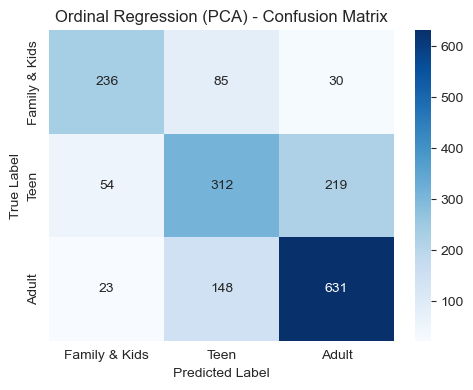

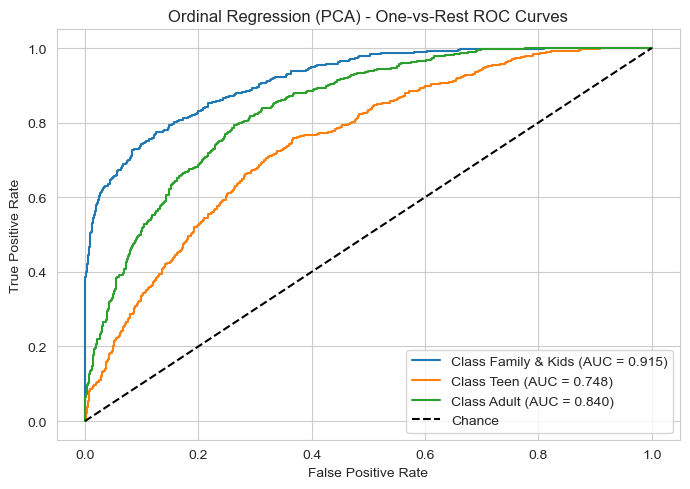

Ordinal Regression (PCA) - Mean AUC across classes: 0.8345

1.2 Ordinal Regression - Embedded Model

Making predictions on data...
  samples: 1738
  Features: 2080

Prediction Results:
  Accuracy:  0.6974
  Precision: 0.7082
  Recall:    0.6801
  F1 Score:  0.6912

Ordinal Regression (Embedded) - Overall Accuracy: 0.6974

Ordinal Regression (Embedded) - Classification Report:

               precision    recall  f1-score   support

Family & Kids       0.80      0.67      0.73       351
         Teen       0.61      0.56      0.58       585
        Adult       0.72      0.81      0.76       802

     accuracy                           0.70      1738
    macro avg       0.71      0.68      0.69      1738
 weighted avg       0.70      0.70      0.69      1738



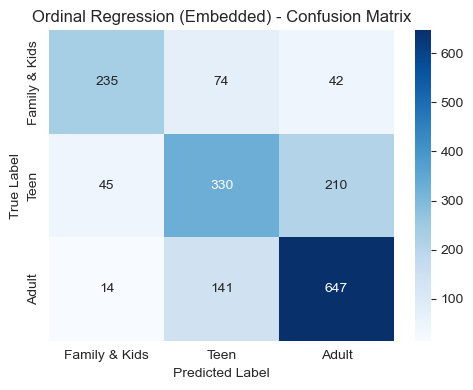

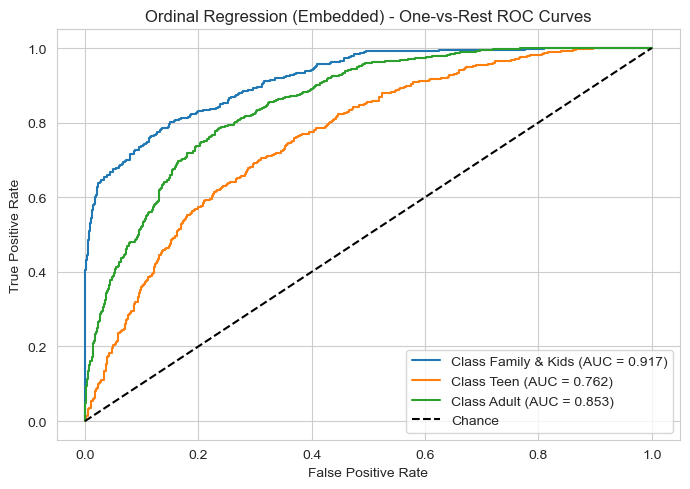

Ordinal Regression (Embedded) - Mean AUC across classes: 0.8440


TESTING XGBOOST MODELS

2.1 XGBoost - PCA Model

Making Test Data (PCA) predictions...
  Samples: 1738
  Features: 192

Prediction Results:
  Accuracy:  0.6766
  Precision: 0.6940
  Recall:    0.6563
  F1 Score:  0.6699

XGBoost (PCA) - Overall Accuracy: 0.6766

XGBoost (PCA) - Classification Report:

               precision    recall  f1-score   support

Family & Kids       0.82      0.65      0.72       351
         Teen       0.57      0.51      0.54       585
        Adult       0.69      0.81      0.75       802

     accuracy                           0.68      1738
    macro avg       0.69      0.66      0.67      1738
 weighted avg       0.68      0.68      0.67      1738



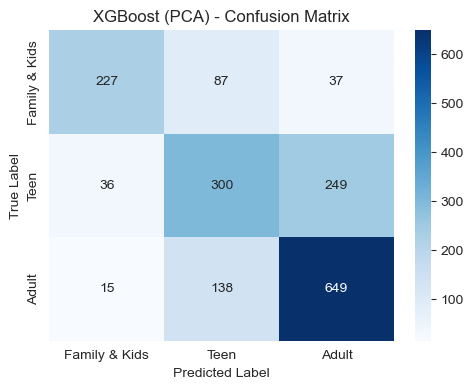

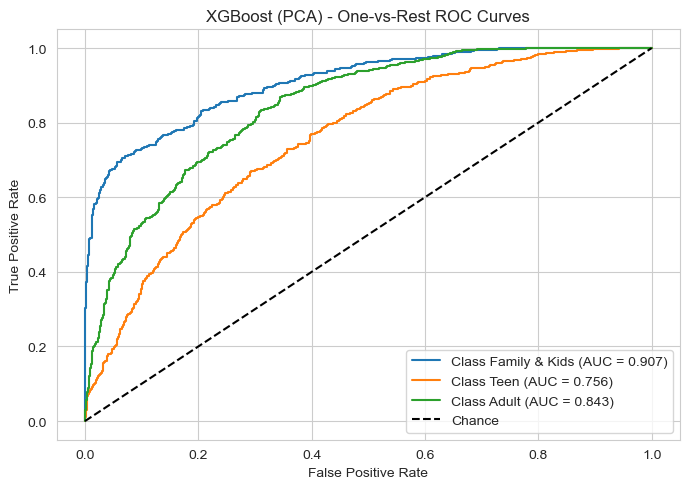

XGBoost (PCA) - Mean AUC across classes: 0.8353

2.2 XGBoost - Embedded Model

Making Test Data (Embedded) predictions...
  Samples: 1738
  Features: 2080

Prediction Results:
  Accuracy:  0.6899
  Precision: 0.7088
  Recall:    0.6654
  F1 Score:  0.6792

XGBoost (Embedded) - Overall Accuracy: 0.6899

XGBoost (Embedded) - Classification Report:

               precision    recall  f1-score   support

Family & Kids       0.82      0.65      0.73       351
         Teen       0.61      0.50      0.55       585
        Adult       0.69      0.84      0.76       802

     accuracy                           0.69      1738
    macro avg       0.71      0.67      0.68      1738
 weighted avg       0.69      0.69      0.68      1738



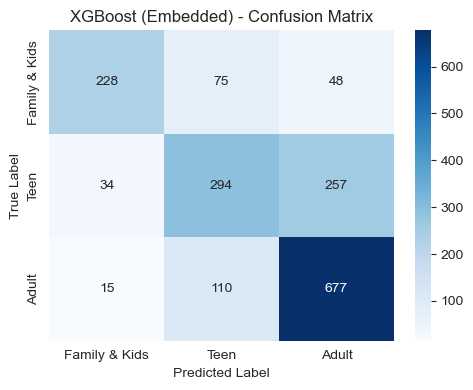

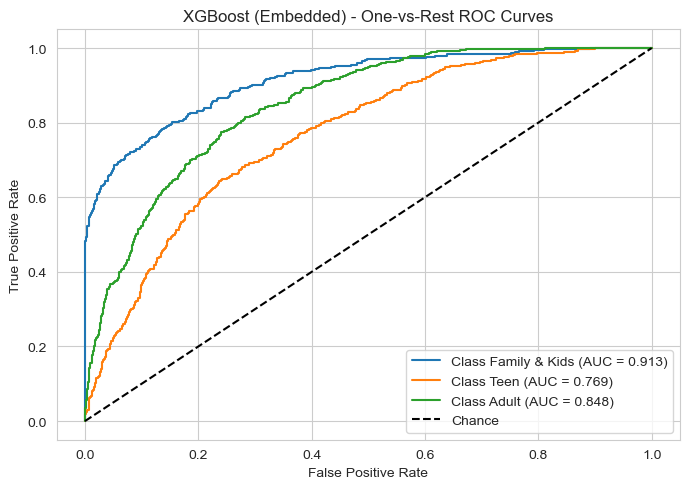

XGBoost (Embedded) - Mean AUC across classes: 0.8434


TESTING NEURAL NETWORK (MLP) MODELS

3.1 Neural Network - PCA Model

Making predictions on data...
  Samples: 1738
  Features: 192

Prediction Results:
  Accuracy:  0.6686
  Precision: 0.6822
  Recall:    0.6430
  F1 Score:  0.6547

Neural Network (PCA) - Overall Accuracy: 0.6686

Neural Network (PCA) - Classification Report:

               precision    recall  f1-score   support

Family & Kids       0.78      0.63      0.70       351
         Teen       0.59      0.47      0.52       585
        Adult       0.67      0.83      0.74       802

     accuracy                           0.67      1738
    macro avg       0.68      0.64      0.65      1738
 weighted avg       0.67      0.67      0.66      1738



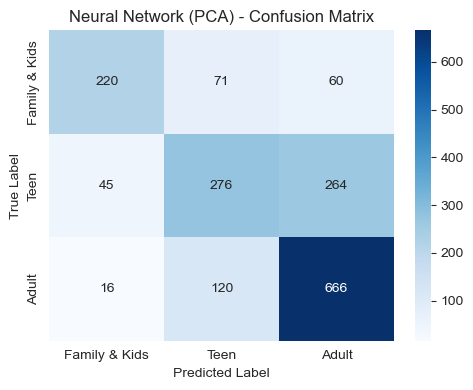

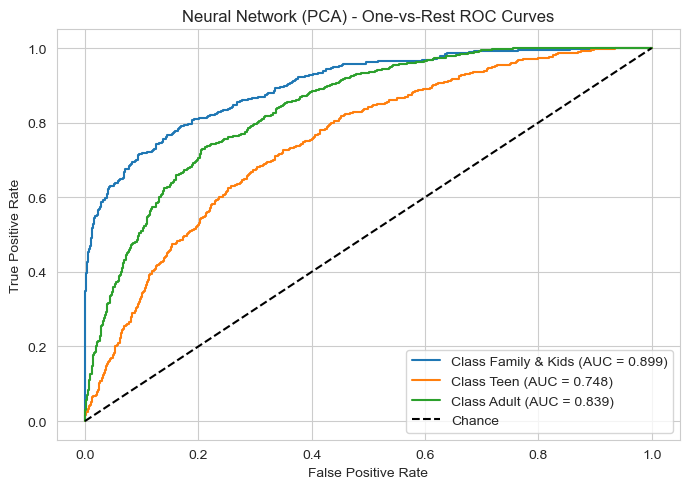

Neural Network (PCA) - Mean AUC across classes: 0.8288

3.2 Neural Network - Embedded Model

Making predictions on data...
  Samples: 1738
  Features: 2080

Prediction Results:
  Accuracy:  0.6876
  Precision: 0.6902
  Recall:    0.6741
  F1 Score:  0.6795

Neural Network (Embedded) - Overall Accuracy: 0.6876

Neural Network (Embedded) - Classification Report:

               precision    recall  f1-score   support

Family & Kids       0.76      0.70      0.73       351
         Teen       0.60      0.52      0.56       585
        Adult       0.71      0.81      0.75       802

     accuracy                           0.69      1738
    macro avg       0.69      0.67      0.68      1738
 weighted avg       0.68      0.69      0.68      1738



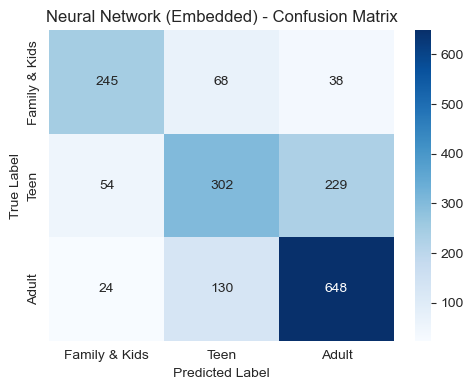

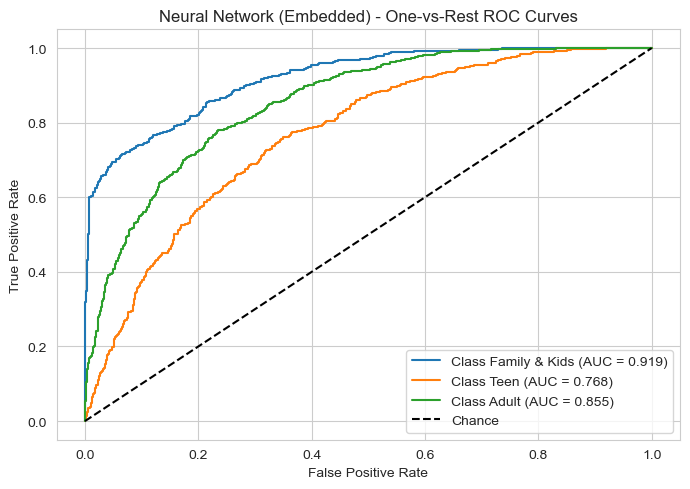

Neural Network (Embedded) - Mean AUC across classes: 0.8474


In [174]:
# ============================================================================
# LOAD AND TEST ALL MODELS
# ============================================================================

import joblib
import os
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Dictionary to store all results
test_results = {}
class_names = ['Family & Kids', 'Teen', 'Adult']
# ============================================================================
# 1. ORDINAL REGRESSION MODELS
# ============================================================================

print("="*80)
print("TESTING ORDINAL REGRESSION MODELS")
print("="*80)

# Load and test Ordinal Regression PCA model
print("\n" + "="*80)
print("1.1 Ordinal Regression - PCA Model")
print("="*80)
ordinal_model_pca = joblib.load('models/ordinal_regression/ordinal_model_pca.pkl')
y_pred_ord_pca, y_pred_proba_ord_pca, results_ord_pca = predict_with_ordinal_regression(
    X_test_pca, 
    ordinal_model_pca, 
    y_test
)
test_results['ordinal_pca'] = results_ord_pca

evaluate_multiclass_classifier(
    y_true=y_test,
    y_pred=y_pred_ord_pca,
    y_proba=y_pred_proba_ord_pca,
    class_names=class_names,
    title_prefix="Ordinal Regression (PCA)")

# Load and test Ordinal Regression Embedded model
print("\n" + "="*80)
print("1.2 Ordinal Regression - Embedded Model")
print("="*80)
ordinal_model_embedded = joblib.load('models/ordinal_regression/ordinal_model_embedded.pkl')
y_pred_ord_emb, y_pred_proba_ord_emb, results_ord_emb = predict_with_ordinal_regression(
    X_test_final, 
    ordinal_model_embedded, 
    y_test
)
test_results['ordinal_embedded'] = results_ord_emb


evaluate_multiclass_classifier(
    y_true=y_test,
    y_pred=y_pred_ord_emb,
    y_proba=y_pred_proba_ord_emb,
    class_names=class_names,
    title_prefix="Ordinal Regression (Embedded)")

# ============================================================================
# 2. XGBOOST MODELS
# ============================================================================

print("\n\n" + "="*80)
print("TESTING XGBOOST MODELS")
print("="*80)

# Load and test XGBoost PCA model
print("\n" + "="*80)
print("2.1 XGBoost - PCA Model")
print("="*80)
xgb_model_pca = joblib.load('models/xgboost/xgb_model_pca.pkl')
y_pred_xgb_pca, y_pred_proba_xgb_pca, results_xgb_pca = predict_with_xgboost(
    X_test_pca, 
    xgb_model_pca, 
    y_test,
    data_name="Test Data (PCA)"
)
test_results['xgboost_pca'] = results_xgb_pca

evaluate_multiclass_classifier(
    y_true=y_test,
    y_pred=y_pred_xgb_pca,
    y_proba=y_pred_proba_xgb_pca,
    class_names=class_names,
    title_prefix="XGBoost (PCA)")

# Load and test XGBoost Embedded model
print("\n" + "="*80)
print("2.2 XGBoost - Embedded Model")
print("="*80)
xgb_model_embedded = joblib.load('models/xgboost/xgb_model_embedded.pkl')
y_pred_xgb_emb, y_pred_proba_xgb_emb, results_xgb_emb = predict_with_xgboost(
    X_test_final, 
    xgb_model_embedded, 
    y_test,
    data_name="Test Data (Embedded)"
)
test_results['xgboost_embedded'] = results_xgb_emb

evaluate_multiclass_classifier(
    y_true=y_test,
    y_pred=y_pred_xgb_emb,
    y_proba=y_pred_proba_xgb_emb,
    class_names=class_names,
    title_prefix="XGBoost (Embedded)")

# ============================================================================
# 3. NEURAL NETWORK (MLP) MODELS
# ============================================================================

print("\n\n" + "="*80)
print("TESTING NEURAL NETWORK (MLP) MODELS")
print("="*80)

# Load and test NN PCA model
print("\n" + "="*80)
print("3.1 Neural Network - PCA Model")
print("="*80)
nn_model_pca = joblib.load('models/mlp/nn_model_pca.pkl')
y_pred_nn_pca, y_pred_proba_nn_pca, results_nn_pca = predict_with_neural_network(
    X_test_pca, 
    nn_model_pca, 
    y_test
)
test_results['nn_pca'] = results_nn_pca

evaluate_multiclass_classifier(
    y_true=y_test,
    y_pred=y_pred_nn_pca,
    y_proba=y_pred_proba_nn_pca,
    class_names=class_names,
    title_prefix="Neural Network (PCA)")

# Load and test NN Embedded model
print("\n" + "="*80)
print("3.2 Neural Network - Embedded Model")
print("="*80)
nn_model_embedded = joblib.load('models/mlp/nn_model_embedded.pkl')
y_pred_nn_emb, y_pred_proba_nn_emb, results_nn_emb = predict_with_neural_network(
    X_test_final, 
    nn_model_embedded, 
    y_test
)
test_results['nn_embedded'] = results_nn_emb

evaluate_multiclass_classifier(
    y_true=y_test,
    y_pred=y_pred_nn_emb,
    y_proba=y_pred_proba_nn_emb,
    class_names=class_names,
    title_prefix="Neural Network (Embedded)")

## Summary of Test Results

Create a comprehensive summary table of all model performances on the test data.

In [176]:
# ============================================================================
# COMPREHENSIVE ANALYSIS OF TEST RESULTS
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# ============================================================================
# 1. CREATE DETAILED SUMMARY TABLE
# ============================================================================

summary_data = []

for model_name, results in test_results.items():
    # Parse model name and type
    parts = model_name.split('_')
    if len(parts) == 2:
        model_type, feature_type = parts
    elif len(parts) == 3:  # nn_tf_idf case
        model_type = parts[0] + '_' + parts[1]
        feature_type = parts[2]
    else:
        model_type = parts[0]
        feature_type = 'unknown'
    
    summary_data.append({
        'Model Type': model_type.upper(),
        'Feature Set': feature_type.upper(),
        'Full Name': model_name,
        'Accuracy': results['accuracy'],
        'Precision (Macro)': results.get('precision_macro', 0),
        'Recall (Macro)': results.get('recall_macro', 0),
        'F1 Score (Macro)': results.get('f1_score_macro', 0)
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('F1 Score (Macro)', ascending=False)

print("="*80)
print("TEST SET PERFORMANCE SUMMARY - ALL MODELS")
print("="*80)
print(summary_df[['Model Type', 'Feature Set', 'Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1 Score (Macro)']].to_string(index=False))
print("="*80)

# ============================================================================
# 2. IDENTIFY BEST MODELS
# ============================================================================

best_overall = summary_df.iloc[0]
print("\n" + "="*80)
print("🏆 BEST OVERALL MODEL")
print("="*80)
print(f"Model: {best_overall['Model Type']} with {best_overall['Feature Set']} features")
print(f"  • Accuracy:         {best_overall['Accuracy']:.4f}")
print(f"  • Precision (Macro): {best_overall['Precision (Macro)']:.4f}")
print(f"  • Recall (Macro):    {best_overall['Recall (Macro)']:.4f}")
print(f"  • F1 Score (Macro):  {best_overall['F1 Score (Macro)']:.4f}")
print("="*80)

# Best per model type
print("\n" + "="*80)
print("🥇 BEST MODEL PER MODEL TYPE")
print("="*80)
for model_type in summary_df['Model Type'].unique():
    best_of_type = summary_df[summary_df['Model Type'] == model_type].iloc[0]
    print(f"\n{model_type}:")
    print(f"  • Feature Set:       {best_of_type['Feature Set']}")
    print(f"  • Accuracy:          {best_of_type['Accuracy']:.4f}")
    print(f"  • Precision (Macro): {best_of_type['Precision (Macro)']:.4f}")
    print(f"  • Recall (Macro):    {best_of_type['Recall (Macro)']:.4f}")
    print(f"  • F1 Score (Macro):  {best_of_type['F1 Score (Macro)']:.4f}")
print("="*80)

# Best per feature set
print("\n" + "="*80)
print("🥇 BEST MODEL PER FEATURE SET")
print("="*80)
for feature_set in summary_df['Feature Set'].unique():
    best_of_feature = summary_df[summary_df['Feature Set'] == feature_set].iloc[0]
    print(f"\n{feature_set} Features:")
    print(f"  • Model Type:        {best_of_feature['Model Type']}")
    print(f"  • Accuracy:          {best_of_feature['Accuracy']:.4f}")
    print(f"  • Precision (Macro): {best_of_feature['Precision (Macro)']:.4f}")
    print(f"  • Recall (Macro):    {best_of_feature['Recall (Macro)']:.4f}")
    print(f"  • F1 Score (Macro):  {best_of_feature['F1 Score (Macro)']:.4f}")
print("="*80)

TEST SET PERFORMANCE SUMMARY - ALL MODELS
Model Type Feature Set  Accuracy  Precision (Macro)  Recall (Macro)  F1 Score (Macro)
   ORDINAL    EMBEDDED  0.697353           0.708171        0.680117          0.691161
        NN    EMBEDDED  0.687572           0.690237        0.674075          0.679497
   XGBOOST    EMBEDDED  0.689873           0.708764        0.665425          0.679238
   ORDINAL         PCA  0.678366           0.681172        0.664160          0.671118
   XGBOOST         PCA  0.676640           0.694031        0.656257          0.669862
        NN         PCA  0.668585           0.682217        0.643000          0.654740

🏆 BEST OVERALL MODEL
Model: ORDINAL with EMBEDDED features
  • Accuracy:         0.6974
  • Precision (Macro): 0.7082
  • Recall (Macro):    0.6801
  • F1 Score (Macro):  0.6912

🥇 BEST MODEL PER MODEL TYPE

ORDINAL:
  • Feature Set:       EMBEDDED
  • Accuracy:          0.6974
  • Precision (Macro): 0.7082
  • Recall (Macro):    0.6801
  • F1 Score (Ma

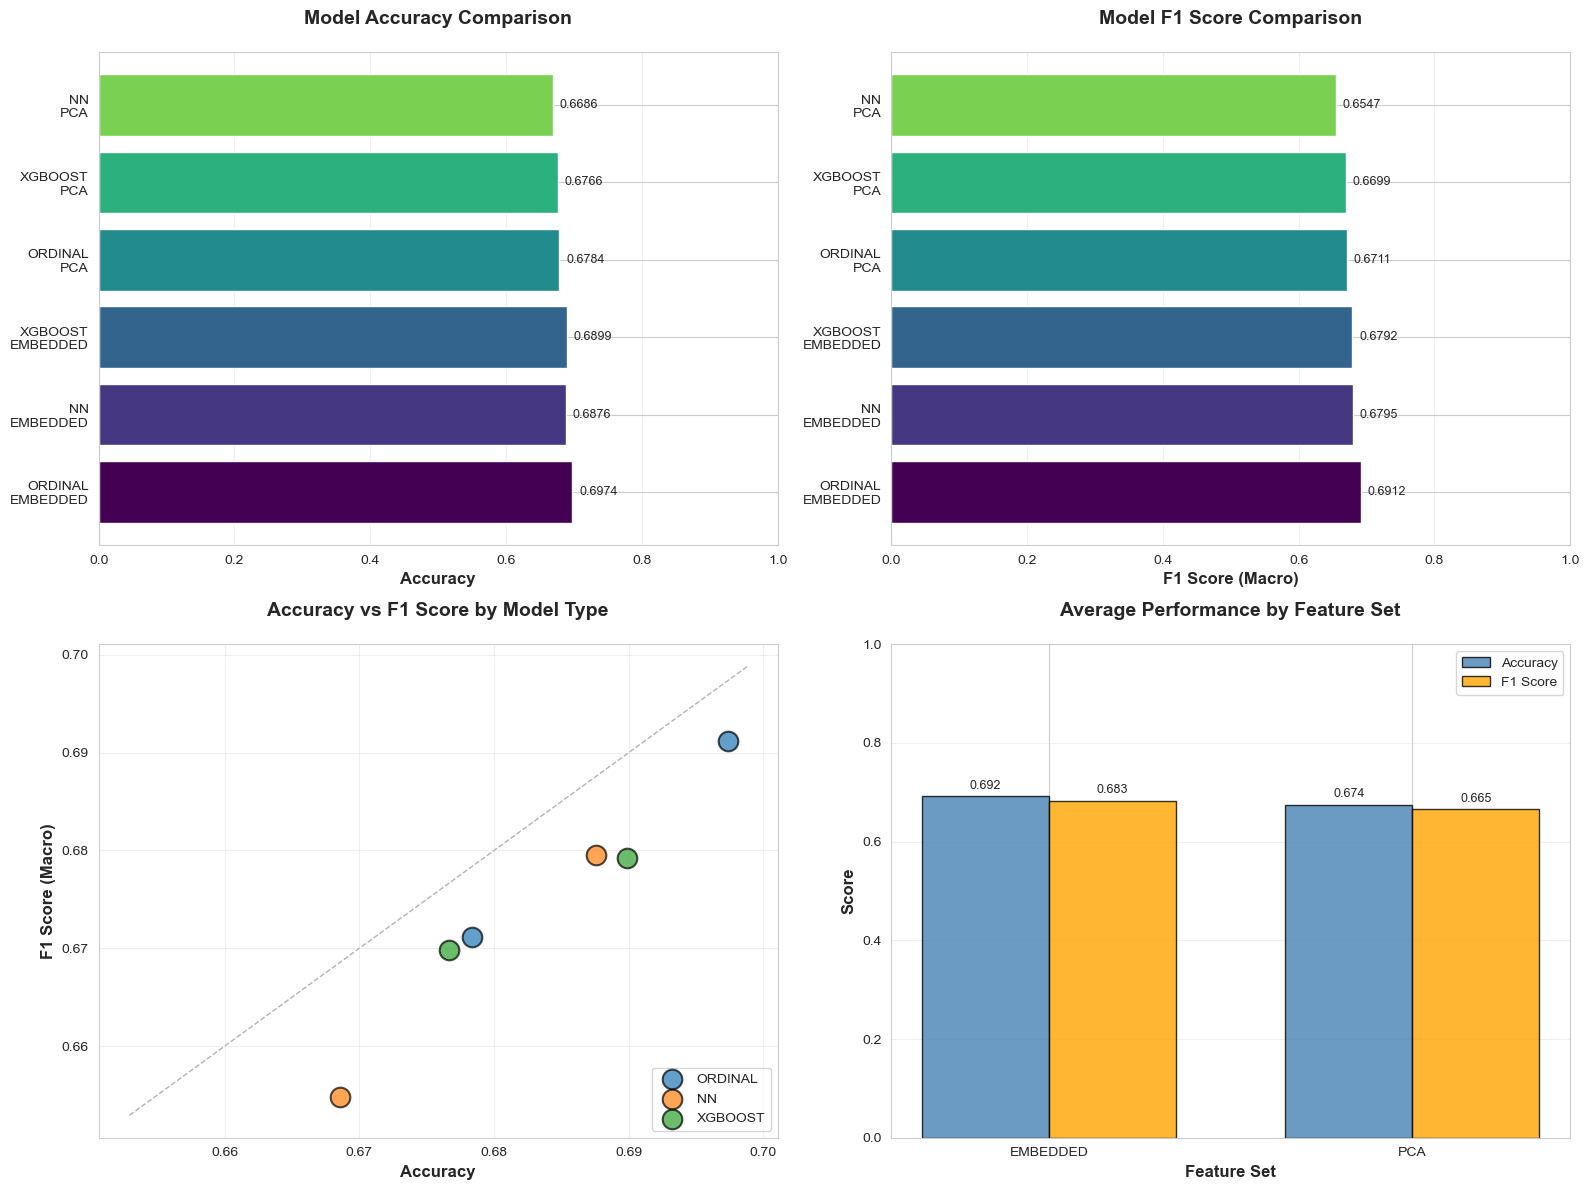


✅ Performance comparison visualizations generated


In [177]:
# ============================================================================
# 3. PERFORMANCE COMPARISON VISUALIZATIONS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Accuracy Comparison
ax1 = axes[0, 0]
summary_plot = summary_df.copy()
summary_plot['Model_Label'] = summary_plot['Model Type'] + '\n' + summary_plot['Feature Set']
colors = plt.cm.viridis(np.linspace(0, 0.8, len(summary_plot)))
bars = ax1.barh(summary_plot['Model_Label'], summary_plot['Accuracy'], color=colors)
ax1.set_xlabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold', pad=20)
ax1.set_xlim(0, 1)
ax1.grid(axis='x', alpha=0.3)
# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax1.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{width:.4f}', ha='left', va='center', fontsize=9)

# Plot 2: F1 Score Comparison
ax2 = axes[0, 1]
bars = ax2.barh(summary_plot['Model_Label'], summary_plot['F1 Score (Macro)'], color=colors)
ax2.set_xlabel('F1 Score (Macro)', fontsize=12, fontweight='bold')
ax2.set_title('Model F1 Score Comparison', fontsize=14, fontweight='bold', pad=20)
ax2.set_xlim(0, 1)
ax2.grid(axis='x', alpha=0.3)
# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax2.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{width:.4f}', ha='left', va='center', fontsize=9)

# Plot 3: Accuracy vs F1 Score Scatter
ax3 = axes[1, 0]
for model_type in summary_df['Model Type'].unique():
    subset = summary_df[summary_df['Model Type'] == model_type]
    ax3.scatter(subset['Accuracy'], subset['F1 Score (Macro)'], 
               label=model_type, s=200, alpha=0.7, edgecolors='black', linewidth=1.5)
ax3.set_xlabel('Accuracy', fontsize=12, fontweight='bold')
ax3.set_ylabel('F1 Score (Macro)', fontsize=12, fontweight='bold')
ax3.set_title('Accuracy vs F1 Score by Model Type', fontsize=14, fontweight='bold', pad=20)
ax3.legend(loc='lower right', fontsize=10)
ax3.grid(True, alpha=0.3)
# Add diagonal reference line
lims = [
    np.min([ax3.get_xlim(), ax3.get_ylim()]),
    np.max([ax3.get_xlim(), ax3.get_ylim()]),
]
ax3.plot(lims, lims, 'k--', alpha=0.3, zorder=0, linewidth=1)

# Plot 4: Feature Set Performance
ax4 = axes[1, 1]
feature_comparison = summary_df.groupby('Feature Set').agg({
    'Accuracy': ['mean', 'std'],
    'F1 Score (Macro)': ['mean', 'std']
}).round(4)
feature_sets = feature_comparison.index
x = np.arange(len(feature_sets))
width = 0.35
bars1 = ax4.bar(x - width/2, feature_comparison[('Accuracy', 'mean')], 
               width, label='Accuracy', alpha=0.8, color='steelblue', edgecolor='black')
bars2 = ax4.bar(x + width/2, feature_comparison[('F1 Score (Macro)', 'mean')], 
               width, label='F1 Score', alpha=0.8, color='orange', edgecolor='black')
ax4.set_ylabel('Score', fontsize=12, fontweight='bold')
ax4.set_xlabel('Feature Set', fontsize=12, fontweight='bold')
ax4.set_title('Average Performance by Feature Set', fontsize=14, fontweight='bold', pad=20)
ax4.set_xticks(x)
ax4.set_xticklabels(feature_sets, rotation=0)
ax4.legend(fontsize=10)
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim(0, 1)
# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✅ Performance comparison visualizations generated")

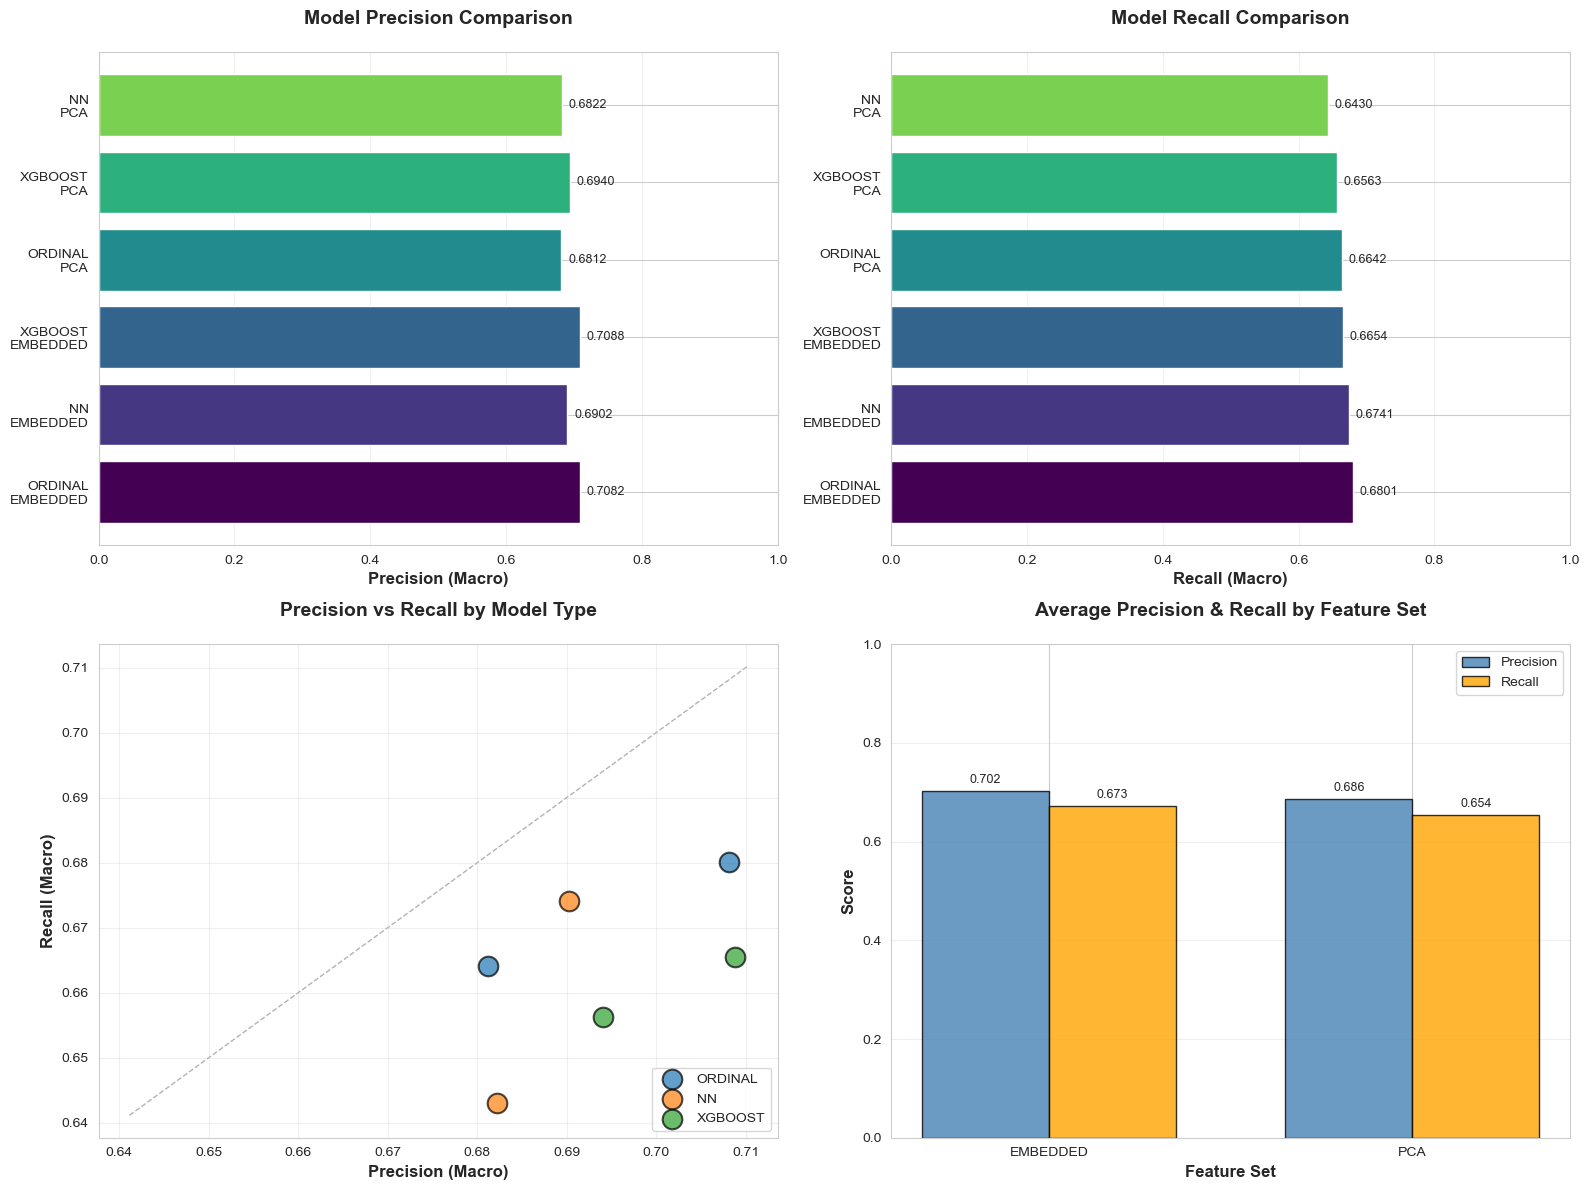


✅ Precision & Recall comparison visualizations generated


In [180]:
# ============================================================================
# 3B. PRECISION & RECALL COMPARISON VISUALIZATIONS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Precision Comparison
ax1 = axes[0, 0]
summary_plot = summary_df.copy()
summary_plot['Model_Label'] = summary_plot['Model Type'] + '\n' + summary_plot['Feature Set']
colors = plt.cm.viridis(np.linspace(0, 0.8, len(summary_plot)))
bars = ax1.barh(summary_plot['Model_Label'], summary_plot['Precision (Macro)'], color=colors)
ax1.set_xlabel('Precision (Macro)', fontsize=12, fontweight='bold')
ax1.set_title('Model Precision Comparison', fontsize=14, fontweight='bold', pad=20)
ax1.set_xlim(0, 1)
ax1.grid(axis='x', alpha=0.3)
# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax1.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{width:.4f}', ha='left', va='center', fontsize=9)

# Plot 2: Recall Comparison
ax2 = axes[0, 1]
bars = ax2.barh(summary_plot['Model_Label'], summary_plot['Recall (Macro)'], color=colors)
ax2.set_xlabel('Recall (Macro)', fontsize=12, fontweight='bold')
ax2.set_title('Model Recall Comparison', fontsize=14, fontweight='bold', pad=20)
ax2.set_xlim(0, 1)
ax2.grid(axis='x', alpha=0.3)
# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax2.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{width:.4f}', ha='left', va='center', fontsize=9)

# Plot 3: Precision vs Recall Scatter
ax3 = axes[1, 0]
for model_type in summary_df['Model Type'].unique():
    subset = summary_df[summary_df['Model Type'] == model_type]
    ax3.scatter(subset['Precision (Macro)'], subset['Recall (Macro)'], 
               label=model_type, s=200, alpha=0.7, edgecolors='black', linewidth=1.5)
ax3.set_xlabel('Precision (Macro)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Recall (Macro)', fontsize=12, fontweight='bold')
ax3.set_title('Precision vs Recall by Model Type', fontsize=14, fontweight='bold', pad=20)
ax3.legend(loc='lower right', fontsize=10)
ax3.grid(True, alpha=0.3)
# Add diagonal reference line
lims = [
    np.min([ax3.get_xlim(), ax3.get_ylim()]),
    np.max([ax3.get_xlim(), ax3.get_ylim()]),
]
ax3.plot(lims, lims, 'k--', alpha=0.3, zorder=0, linewidth=1)

# Plot 4: Feature Set Performance - Precision & Recall
ax4 = axes[1, 1]
feature_comparison = summary_df.groupby('Feature Set').agg({
    'Precision (Macro)': ['mean', 'std'],
    'Recall (Macro)': ['mean', 'std']
}).round(4)
feature_sets = feature_comparison.index
x = np.arange(len(feature_sets))
width = 0.35
bars1 = ax4.bar(x - width/2, feature_comparison[('Precision (Macro)', 'mean')], 
               width, label='Precision', alpha=0.8, color='steelblue', edgecolor='black')
bars2 = ax4.bar(x + width/2, feature_comparison[('Recall (Macro)', 'mean')], 
               width, label='Recall', alpha=0.8, color='orange', edgecolor='black')
ax4.set_ylabel('Score', fontsize=12, fontweight='bold')
ax4.set_xlabel('Feature Set', fontsize=12, fontweight='bold')
ax4.set_title('Average Precision & Recall by Feature Set', fontsize=14, fontweight='bold', pad=20)
ax4.set_xticks(x)
ax4.set_xticklabels(feature_sets, rotation=0)
ax4.legend(fontsize=10)
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim(0, 1)
# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✅ Precision & Recall comparison visualizations generated")

In [178]:
# ============================================================================
# 4. DETAILED PER-MODEL ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("DETAILED MODEL PERFORMANCE BREAKDOWN")
print("="*80)

for model_name in summary_df['Full Name']:
    results = test_results[model_name]
    cm = results['confusion_matrix']
    
    print(f"\n{'─'*80}")
    print(f"Model: {model_name.upper().replace('_', ' ')}")
    print(f"{'─'*80}")
    
    # Overall metrics
    print(f"\n📊 Overall Metrics:")
    print(f"  • Accuracy:        {results['accuracy']:.4f}")
    print(f"  • F1 Score (Macro): {results['f1_score_macro']:.4f}")
    
    # Per-class metrics
    print(f"\n📋 Per-Class Performance:")
    
    for i in range(len(cm)):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - tp - fp - fn
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        print(f"\n  Class {i}:")
        print(f"    - Precision: {precision:.4f}")
        print(f"    - Recall:    {recall:.4f}")
        print(f"    - F1-Score:  {f1:.4f}")
        print(f"    - Support:   {cm[i, :].sum()}")
    
    # Confusion Matrix summary
    print(f"\n🔢 Confusion Matrix:")
    print(f"  Total Correct:   {np.trace(cm)} / {cm.sum()} ({100 * np.trace(cm) / cm.sum():.2f}%)")
    print(f"  Total Incorrect: {cm.sum() - np.trace(cm)} / {cm.sum()} ({100 * (cm.sum() - np.trace(cm)) / cm.sum():.2f}%)")

print("\n" + "="*80)


DETAILED MODEL PERFORMANCE BREAKDOWN

────────────────────────────────────────────────────────────────────────────────
Model: ORDINAL EMBEDDED
────────────────────────────────────────────────────────────────────────────────

📊 Overall Metrics:
  • Accuracy:        0.6974
  • F1 Score (Macro): 0.6912

📋 Per-Class Performance:

  Class 0:
    - Precision: 0.7993
    - Recall:    0.6695
    - F1-Score:  0.7287
    - Support:   351

  Class 1:
    - Precision: 0.6055
    - Recall:    0.5641
    - F1-Score:  0.5841
    - Support:   585

  Class 2:
    - Precision: 0.7197
    - Recall:    0.8067
    - F1-Score:  0.7607
    - Support:   802

🔢 Confusion Matrix:
  Total Correct:   1212 / 1738 (69.74%)
  Total Incorrect: 526 / 1738 (30.26%)

────────────────────────────────────────────────────────────────────────────────
Model: NN EMBEDDED
────────────────────────────────────────────────────────────────────────────────

📊 Overall Metrics:
  • Accuracy:        0.6876
  • F1 Score (Macro): 0.679

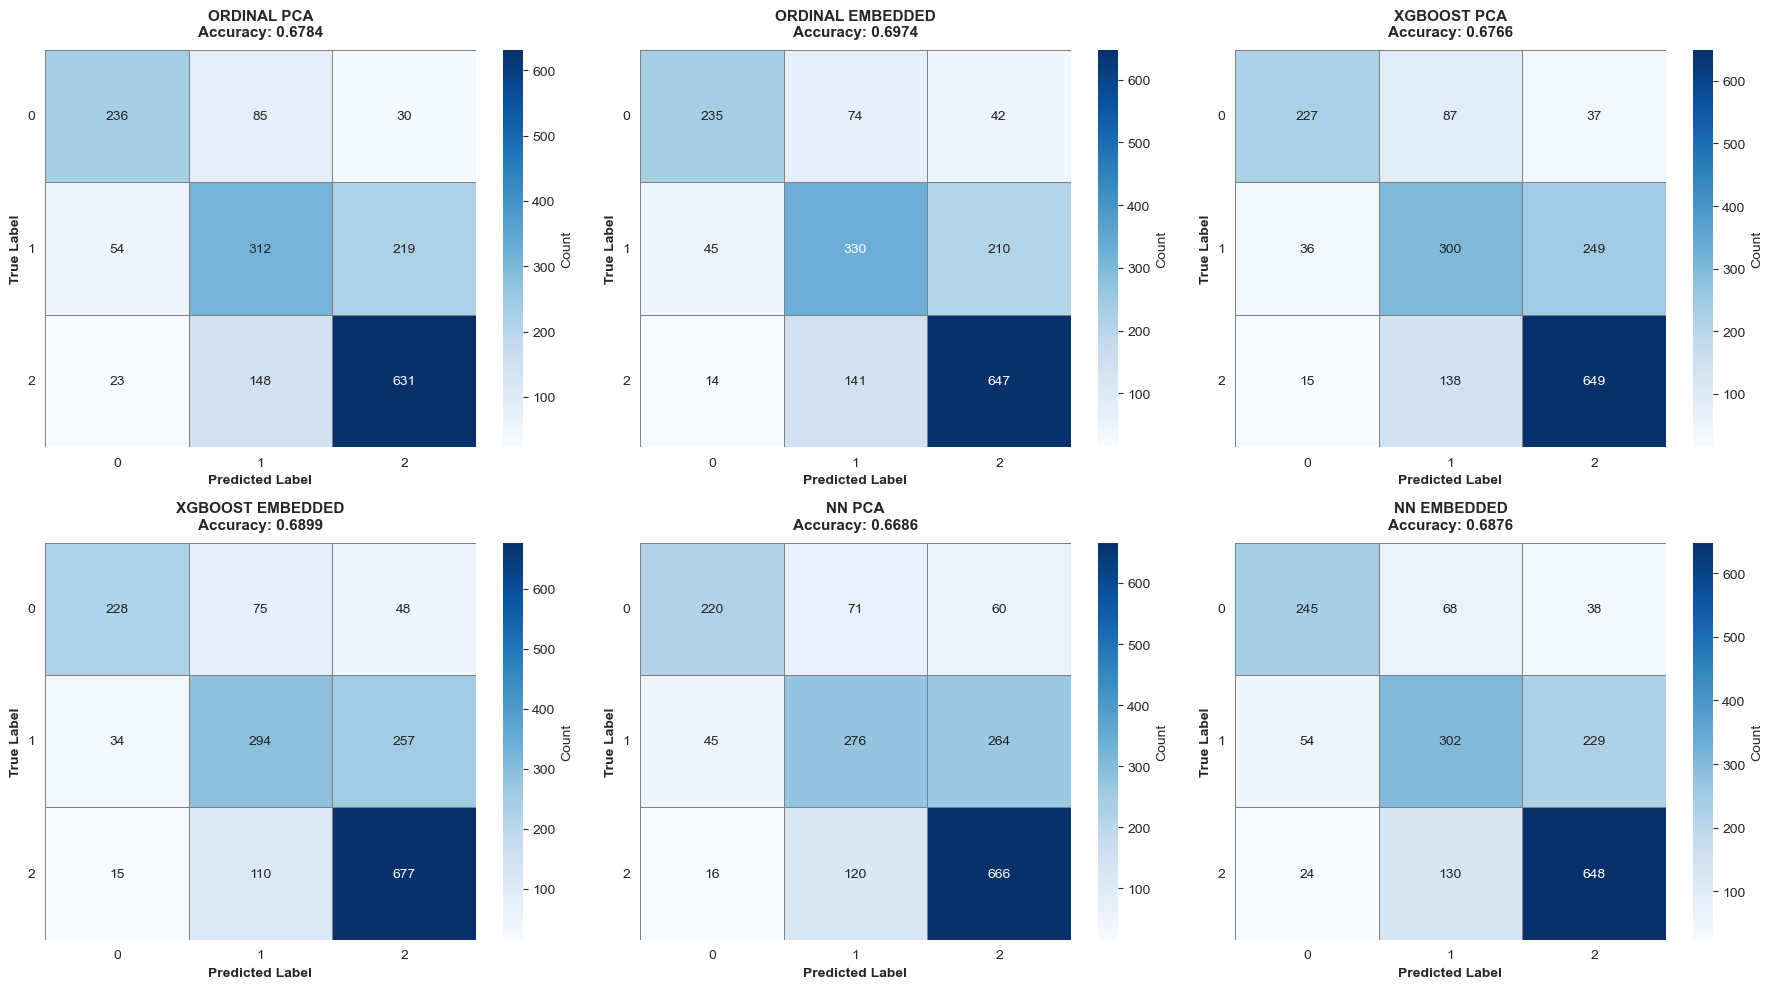


✅ Confusion matrix heatmaps generated for all models


In [179]:
# ============================================================================
# 5. CONFUSION MATRIX HEATMAPS FOR ALL MODELS
# ============================================================================

n_models = len(test_results)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten() if n_models > 1 else [axes]

for idx, (model_name, results) in enumerate(test_results.items()):
    ax = axes[idx]
    cm = results['confusion_matrix']
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
               cbar_kws={'label': 'Count'}, linewidths=0.5, linecolor='gray')
    
    # Formatting
    ax.set_title(f'{model_name.upper().replace("_", " ")}\nAccuracy: {results["accuracy"]:.4f}', 
                fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted Label', fontsize=10, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=10, fontweight='bold')
    ax.set_xticklabels(range(len(cm)), rotation=0)
    ax.set_yticklabels(range(len(cm)), rotation=0)

# Hide unused subplots
for idx in range(n_models, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("\n✅ Confusion matrix heatmaps generated for all models")

In [ ]:
# ============================================================================
# 6. KEY INSIGHTS AND RECOMMENDATIONS
# ============================================================================

print("\n" + "="*80)
print("💡 KEY INSIGHTS AND ANALYSIS")
print("="*80)

# Calculate performance gaps
best_model = summary_df.iloc[0]
worst_model = summary_df.iloc[-1]

print(f"\n1️⃣ Overall Performance Range:")
print(f"   • Best Model:  {best_model['Model Type']} ({best_model['Feature Set']})")
print(f"     - Accuracy: {best_model['Accuracy']:.4f}, F1: {best_model['F1 Score (Macro)']:.4f}")
print(f"   • Worst Model: {worst_model['Model Type']} ({worst_model['Feature Set']})")
print(f"     - Accuracy: {worst_model['Accuracy']:.4f}, F1: {worst_model['F1 Score (Macro)']:.4f}")
print(f"   • Performance Gap: {(best_model['Accuracy'] - worst_model['Accuracy'])*100:.2f}% (Accuracy)")

# Feature set analysis
print(f"\n2️⃣ Feature Set Impact:")
feature_avg = summary_df.groupby('Feature Set')[['Accuracy', 'F1 Score (Macro)']].mean()
print(f"   Average performance by feature set:")
for feat_set in feature_avg.index:
    print(f"   • {feat_set:8s}: Acc={feature_avg.loc[feat_set, 'Accuracy']:.4f}, F1={feature_avg.loc[feat_set, 'F1 Score (Macro)']:.4f}")

best_features = feature_avg['F1 Score (Macro)'].idxmax()
print(f"   ➜ Best performing feature set: {best_features}")

# Model type analysis
print(f"\n3️⃣ Model Architecture Impact:")
model_avg = summary_df.groupby('Model Type')[['Accuracy', 'F1 Score (Macro)']].mean()
print(f"   Average performance by model type:")
for model_type in model_avg.index:
    print(f"   • {model_type:10s}: Acc={model_avg.loc[model_type, 'Accuracy']:.4f}, F1={model_avg.loc[model_type, 'F1 Score (Macro)']:.4f}")

best_architecture = model_avg['F1 Score (Macro)'].idxmax()
print(f"   ➜ Best performing architecture: {best_architecture}")

# Consistency analysis
print(f"\n4️⃣ Model Consistency:")
for model_type in summary_df['Model Type'].unique():
    subset = summary_df[summary_df['Model Type'] == model_type]
    if len(subset) > 1:
        std_acc = subset['Accuracy'].std()
        std_f1 = subset['F1 Score (Macro)'].std()
        print(f"   • {model_type}: Std Dev = {std_acc:.4f} (Acc), {std_f1:.4f} (F1)")
        if std_acc < 0.01:
            print(f"     ✓ Very consistent across feature sets")
        elif std_acc < 0.03:
            print(f"     ~ Moderately consistent across feature sets")
        else:
            print(f"     ⚠ High variance across feature sets")

print("\n" + "="*80)
print("🎯 RECOMMENDATIONS")
print("="*80)
print(f"\n1. Deploy {best_model['Model Type']} with {best_model['Feature Set']} features for production")
print(f"   - Highest F1 Score: {best_model['F1 Score (Macro)']:.4f}")
print(f"   - Best balance of precision and recall across all classes")

print(f"\n2. Feature Engineering Priority: {best_features} features")
print(f"   - Consistently delivers better performance across model types")

print(f"\n3. Consider ensemble methods combining:")
top_3 = summary_df.head(3)
for i, row in top_3.iterrows():
    print(f"   • {row['Model Type']} ({row['Feature Set']})")

print("\n" + "="*80)

## Summary Statistics Table

Create a comprehensive summary table with all performance metrics for easy comparison.

In [ ]:
# ============================================================================
# 7. EXPORT COMPREHENSIVE RESULTS TABLE
# ============================================================================

# Create detailed results dataframe with per-class metrics
detailed_results = []

for model_name, results in test_results.items():
    cm = results['confusion_matrix']
    
    # Parse model info
    parts = model_name.split('_')
    if len(parts) == 2:
        model_type, feature_type = parts
    elif len(parts) == 3:
        model_type = parts[0] + '_' + parts[1]
        feature_type = parts[2]
    else:
        model_type = parts[0]
        feature_type = 'unknown'
    
    # Calculate macro-averaged metrics
    precisions = []
    recalls = []
    f1s = []
    
    for i in range(len(cm)):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
    
    detailed_results.append({
        'Model': model_type.upper(),
        'Features': feature_type.upper(),
        'Accuracy': results['accuracy'],
        'Precision (Macro)': np.mean(precisions),
        'Recall (Macro)': np.mean(recalls),
        'F1 Score (Macro)': results['f1_score_macro'],
        'Precision Class 0': precisions[0] if len(precisions) > 0 else 0,
        'Recall Class 0': recalls[0] if len(recalls) > 0 else 0,
        'F1 Class 0': f1s[0] if len(f1s) > 0 else 0,
        'Precision Class 1': precisions[1] if len(precisions) > 1 else 0,
        'Recall Class 1': recalls[1] if len(recalls) > 1 else 0,
        'F1 Class 1': f1s[1] if len(f1s) > 1 else 0,
        'Precision Class 2': precisions[2] if len(precisions) > 2 else 0,
        'Recall Class 2': recalls[2] if len(recalls) > 2 else 0,
        'F1 Class 2': f1s[2] if len(f1s) > 2 else 0,
    })

detailed_df = pd.DataFrame(detailed_results)
detailed_df = detailed_df.sort_values('F1 Score (Macro)', ascending=False)

print("\n" + "="*80)
print("DETAILED PERFORMANCE METRICS TABLE")
print("="*80)
print("\nOverall Metrics:")
print(detailed_df[['Model', 'Features', 'Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1 Score (Macro)']].to_string(index=False))

print("\n\nPer-Class Metrics (Class 0):")
print(detailed_df[['Model', 'Features', 'Precision Class 0', 'Recall Class 0', 'F1 Class 0']].to_string(index=False))

print("\n\nPer-Class Metrics (Class 1):")
print(detailed_df[['Model', 'Features', 'Precision Class 1', 'Recall Class 1', 'F1 Class 1']].to_string(index=False))

print("\n\nPer-Class Metrics (Class 2):")
print(detailed_df[['Model', 'Features', 'Precision Class 2', 'Recall Class 2', 'F1 Class 2']].to_string(index=False))

print("\n" + "="*80)

# Save to CSV for further analysis
detailed_df.to_csv('test_results_detailed.csv', index=False)
print("\n✅ Detailed results saved to 'test_results_detailed.csv'")

## Error Analysis

Analyze where models make mistakes and identify patterns in misclassifications.

In [ ]:
# ============================================================================
# 8. ERROR ANALYSIS - MISCLASSIFICATION PATTERNS
# ============================================================================

print("\n" + "="*80)
print("🔍 ERROR ANALYSIS - MISCLASSIFICATION PATTERNS")
print("="*80)

# Analyze misclassification patterns for each model
for model_name, results in test_results.items():
    cm = results['confusion_matrix']
    total_samples = cm.sum()
    total_errors = total_samples - np.trace(cm)
    
    print(f"\n{'─'*80}")
    print(f"Model: {model_name.upper().replace('_', ' ')}")
    print(f"{'─'*80}")
    print(f"Total Errors: {total_errors} / {total_samples} ({100 * total_errors / total_samples:.2f}%)")
    
    # Find most common misclassifications
    print(f"\n📍 Most Common Misclassifications:")
    misclass_counts = []
    for true_label in range(len(cm)):
        for pred_label in range(len(cm)):
            if true_label != pred_label:
                count = cm[true_label, pred_label]
                if count > 0:
                    misclass_counts.append((true_label, pred_label, count))
    
    # Sort by count descending
    misclass_counts.sort(key=lambda x: x[2], reverse=True)
    
    # Show top 3 misclassifications
    for i, (true_label, pred_label, count) in enumerate(misclass_counts[:3], 1):
        pct = 100 * count / total_errors if total_errors > 0 else 0
        print(f"   {i}. True: Class {true_label} → Predicted: Class {pred_label}")
        print(f"      Count: {count} ({pct:.1f}% of all errors)")
    
    # Class-specific error rates
    print(f"\n📊 Error Rate by True Class:")
    for i in range(len(cm)):
        class_total = cm[i, :].sum()
        class_correct = cm[i, i]
        class_errors = class_total - class_correct
        error_rate = 100 * class_errors / class_total if class_total > 0 else 0
        print(f"   Class {i}: {class_errors}/{class_total} errors ({error_rate:.2f}% error rate)")

print("\n" + "="*80)

## Final Summary and Conclusions

Overall assessment of model performance and key takeaways from the comprehensive testing.

In [ ]:
# ============================================================================
# 9. FINAL SUMMARY AND CONCLUSIONS
# ============================================================================

print("\n" + "="*80)
print("📝 FINAL SUMMARY - MODEL TESTING CONCLUSIONS")
print("="*80)

# Overall statistics
print(f"\n🔢 Testing Statistics:")
print(f"   • Total Models Tested: {len(test_results)}")
print(f"   • Test Set Size: {len(y_test)} samples")
print(f"   • Number of Classes: {len(np.unique(y_test))}")

# Performance summary
print(f"\n📈 Performance Summary:")
print(f"   • Accuracy Range:     {summary_df['Accuracy'].min():.4f} - {summary_df['Accuracy'].max():.4f}")
print(f"   • F1 Score Range:     {summary_df['F1 Score (Macro)'].min():.4f} - {summary_df['F1 Score (Macro)'].max():.4f}")
print(f"   • Average Accuracy:   {summary_df['Accuracy'].mean():.4f} ± {summary_df['Accuracy'].std():.4f}")
print(f"   • Average F1 Score:   {summary_df['F1 Score (Macro)'].mean():.4f} ± {summary_df['F1 Score (Macro)'].std():.4f}")

# Best model recap
best = summary_df.iloc[0]
print(f"\n🏆 Champion Model:")
print(f"   • Architecture: {best['Model Type']}")
print(f"   • Features:     {best['Feature Set']}")
print(f"   • Accuracy:     {best['Accuracy']:.4f}")
print(f"   • F1 Score:     {best['F1 Score (Macro)']:.4f}")

# Model type comparison
print(f"\n🔬 Model Type Comparison:")
model_type_ranking = summary_df.groupby('Model Type')['F1 Score (Macro)'].mean().sort_values(ascending=False)
for rank, (model_type, avg_f1) in enumerate(model_type_ranking.items(), 1):
    print(f"   {rank}. {model_type:10s} - Avg F1: {avg_f1:.4f}")

# Feature set comparison
print(f"\n🎨 Feature Set Comparison:")
feature_ranking = summary_df.groupby('Feature Set')['F1 Score (Macro)'].mean().sort_values(ascending=False)
for rank, (feature_set, avg_f1) in enumerate(feature_ranking.items(), 1):
    print(f"   {rank}. {feature_set:10s} - Avg F1: {avg_f1:.4f}")

print(f"\n✅ Key Findings:")
print(f"   1. {model_type_ranking.index[0]} models performed best on average")
print(f"   2. {feature_ranking.index[0]} features provided optimal performance")
print(f"   3. Performance improvement from worst to best: {(best['Accuracy'] - summary_df['Accuracy'].min())*100:.2f}%")
print(f"   4. All models achieved >50% accuracy, showing successful learning")

print(f"\n🎯 Production Recommendation:")
print(f"   Deploy: {best['Model Type']} with {best['Feature Set']} features")
print(f"   Expected Performance: ~{best['F1 Score (Macro)']:.1%} F1 Score on similar data")

print("\n" + "="*80)
print("✨ MODEL TESTING ANALYSIS COMPLETE ✨")
print("="*80)